# LSEG Data Pull

Ziel dieses Notebooks: Aufbau eines konsistenten, as-of faehigen Datenpanels fuer die spaetere Portfolio-, EPS- und Duration-Analyse.

Der Workflow umfasst drei Ebenen:
1. Basisdaten laden und taegliche CAPM-Betas schaetzen
2. Analysten-Erwartungen (EPS FY1-FY5, LTG) robust ziehen
3. Fundamentaldaten-Module (Balance Sheet, Income Statement, Cashflow/Payouts) ergaenzen und Coverage pruefen

Ergebnis: eine saubere, dokumentierte Datenbasis auf `firm_id` x `asof_date`, die direkt in Folge-Notebooks genutzt werden kann.


## 0. Setup

Was in diesem Schritt passiert:
- Standardbibliotheken und LSEG SDK laden
- Projektpfade (`BASE_DIR`, `DATA_DIR`) setzen
- Ausgabe-/Warnverhalten fuer reproduzierbare Runs konfigurieren

Voraussetzungen:
- Input-Dateien liegen unter `Project_Data/intermediate`
- Eine gueltige lokale LSEG-Session ist fuer die Data Pulls erreichbar


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import lseg.data as ld

warnings.filterwarnings("ignore", category=FutureWarning, module="lseg")
pd.set_option("display.max_columns", 120)

BASE_DIR = Path("/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data")
DATA_DIR = BASE_DIR / "intermediate"

import hashlib
import json
import random
import re
import time
import matplotlib.pyplot as plt



## 1. Input-Parquets laden

Geladene Dateien:
- `euro500.parquet`: Universe- und Stammdaten je Firma/Stichtag
- `euro500_returns.parquet`: Markt- und Aggregat-Renditen
- `daily_returns_euro500_in_index.parquet`: taegliche Firmenrenditen im Index-Universum

Ziel:
- Alle Kerninputs konsistent in den Speicher laden
- Fruehzeitig mit klaren Fehlermeldungen abbrechen, falls Dateien fehlen


In [2]:
EURO500_PATH = DATA_DIR / "euro500.parquet"
EURO500_RETURNS_PATH = DATA_DIR / "euro500_returns.parquet"
DAILY_RETURNS_IN_INDEX_PATH = DATA_DIR / "daily_returns_euro500.parquet"

for p in [EURO500_PATH, EURO500_RETURNS_PATH, DAILY_RETURNS_IN_INDEX_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"File not found: {p}")

euro500 = pd.read_parquet(EURO500_PATH)
euro500_returns = pd.read_parquet(EURO500_RETURNS_PATH)
daily_returns_euro500_in_index = pd.read_parquet(DAILY_RETURNS_IN_INDEX_PATH)

print("Loaded:")
print("- euro500:", euro500.shape)
print("- euro500_returns:", euro500_returns.shape)
print("- daily_returns_euro500_in_index:", daily_returns_euro500_in_index.shape)



Loaded:
- euro500: (54000, 30)
- euro500_returns: (7016, 8)
- daily_returns_euro500_in_index: (3327823, 10)


## 3. EPS Forecasts FY1-FY5 ziehen (`euro500_EPS`)

Ziel:
- Fuer jede Kombination `asof_date` x `pull_ric` EPS-Forecasts laden
- Horizonte: `FY1` bis `FY5`
- Speicherung in `EURO500_EPS.parquet`

Robuster Ablauf:
1. Request-Key aufbauen (`asof_date`, `pull_ric`)
2. Pull datumweise in Batches (`BATCH_SIZE`)
3. Checkpoints pro Batch schreiben (auch bei leeren Antworten)
4. Fehlerhafte Batches rekursiv splitten und Problem-RICs protokollieren
5. Teile konsolidieren und sauber auf das Universe zurueckmergen

Wichtige Schalter:
- `FORCE_REFRESH_EPS = True`: kompletter Neuaufbau
- `FORCE_REFRESH_EPS = False`: vorhandene Checkpoints wiederverwenden

FY-Mapping:
- Primar ueber Spaltennamen (`EPS`, `MEAN`, `FYx`)
- Fallback ueber Reihenfolge je Instrument, falls Header uneindeutig sind


In [3]:
from typing import Dict, List, Optional, Tuple
# ------------------------------------------------------------
# Step 3 — EPS Forecasts FY1-FY5
# Cache: per company (firm_id), extensible across index changes
# Fixes vs. old code: no ISIN:-prefix, rate-limit backoff not abort
# ------------------------------------------------------------

# ---- Config ------------------------------------------------
HORIZONS       = ["FY1", "FY2", "FY3", "FY4", "FY5"]
EPS_FIELDS_MAP = {f"EPS_{h}": f"TR.EPSMean(period={h})" for h in HORIZONS}
TARGET_COLS_S3 = list(EPS_FIELDS_MAP.keys())

BATCH_SIZE_S3                = 100
FORCE_REFRESH_S3             = False
CACHE_ONLY_S3                = False
# Master switch: True => Step 3 never pulls from LSEG network, only local store/cache.
DISABLE_LSEG_PULL_S3         = True
MAX_RETRIES_S3               = 3
DEBUG_VERBOSE_S3             = False

# Effective offline mode (also respects existing CACHE_ONLY_S3 flag).
CACHE_ONLY_S3                = bool(CACHE_ONLY_S3 or DISABLE_LSEG_PULL_S3)

RATE_LIMIT_COOLDOWN_SEC_S3   = 5.0
RATE_LIMIT_MULTIPLIER_S3     = 2.0
RATE_LIMIT_HARD_PAUSE_SEC_S3 = 30.0
FAIL_FAST_ON_RATE_LIMIT_S3   = False   # allow retry on 429 (not abort)

CACHE_VERSION_S3 = "v1"
EURO500_EPS_PATH = DATA_DIR / "euro500_EPS.parquet"
S3_ROWS_PATH     = DATA_DIR / "eps_step3_rows.parquet"
S3_CKPT_PATH     = DATA_DIR / "eps_step3_checkpoint.json"
S3_CACHE_DIR     = DATA_DIR / "eps_cache_by_company"
S3_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Suppress LSEG/pandas incompatibility: LSEG internals do `if df:` in __del__ callbacks,
# which raises ValueError in pandas 2.x. These are unraisable exceptions that bypass
# try/except and show as cell errors in Python 3.12+/Jupyter.
import sys as _sys
_s3_prev_unraisablehook = _sys.unraisablehook
def _s3_unraisable_hook(args):
    # LSEG destructors may trigger pandas bool(ValueError) in unraisable context.
    try:
        msg = str(getattr(args, "exc_value", "")).lower()
    except Exception:
        msg = ""
    if "truth value" in msg and "ambiguous" in msg and ("series" in msg or "dataframe" in msg):
        return  # suppress known non-fatal pandas truth-value errors
    _s3_prev_unraisablehook(args)
_sys.unraisablehook = _s3_unraisable_hook

# pandas 2.x + Python 3.13 compatibility: some third-party code does `if df:`
# (or `if series:`), which now raises ValueError. Map truthiness to not-empty.
def _s3_ndframe_bool(self):
    try:
        return not self.empty
    except Exception:
        return True

try:
    _s3_orig_series_bool = pd.Series.__bool__
except Exception:
    _s3_orig_series_bool = None
try:
    _s3_orig_series_nonzero = pd.Series.__nonzero__
except Exception:
    _s3_orig_series_nonzero = None
try:
    _s3_orig_df_bool = pd.DataFrame.__bool__
except Exception:
    _s3_orig_df_bool = None
try:
    _s3_orig_df_nonzero = pd.DataFrame.__nonzero__
except Exception:
    _s3_orig_df_nonzero = None

pd.Series.__bool__ = _s3_ndframe_bool
pd.Series.__nonzero__ = _s3_ndframe_bool
pd.DataFrame.__bool__ = _s3_ndframe_bool
pd.DataFrame.__nonzero__ = _s3_ndframe_bool

# ---- Basic helpers -----------------------------------------
def _s3_asof(df: pd.DataFrame) -> pd.Series:
    for col in ("asof_date", "date", "formation_date", "effective_date"):
        if col in df.columns:
            return pd.to_datetime(df[col], errors="coerce").dt.normalize()
    raise ValueError("No date column found (asof_date/date/formation_date/effective_date).")

def _s3_clean(s: pd.Series) -> pd.Series:
    x = s.astype("string").str.strip()
    return x.where(x.notna() & (x != ""), pd.NA)

def _s3_norm_isin(v) -> Optional[str]:
    if pd.isna(v):
        return None
    s = str(v).strip()
    return (s.split(":", 1)[1].strip() if s.upper().startswith("ISIN:") else s) or None

def _s3_build_company_candidates(df: pd.DataFrame) -> List[Tuple[str, str]]:
    """Ordered (id_type, pull_id) list for one company.
    Order: all bare ISINs → all RIC_current → all RIC → pull_id history.
    Never adds ISIN:-prefixed variants (invalid for ld.get_data)."""
    q = df.sort_values("asof_date")
    out, seen = [], set()

    def _add(id_type: str, value):
        if pd.isna(value):
            return
        v = str(value).strip()
        if not v:
            return
        key = (id_type.upper(), v)
        if key not in seen:
            seen.add(key)
            out.append(key)

    for val in q.get("ISIN", pd.Series(dtype="object")):
        n = _s3_norm_isin(val)
        if n:
            _add("ISIN", n)
    for val in q.get("RIC_current", pd.Series(dtype="object")):
        _add("RIC", val)
    for val in q.get("RIC", pd.Series(dtype="object")):
        _add("RIC", val)
    if "pull_id" in q.columns and "id_type" in q.columns:
        for id_type, pull_id in zip(q["id_type"], q["pull_id"]):
            it = str(id_type).upper().strip() if pd.notna(id_type) else ""
            if it == "ISIN":
                n = _s3_norm_isin(pull_id)
                if n:
                    _add("ISIN", n)
            elif it == "RIC":
                _add("RIC", pull_id)
    return out

# ---- Per-company cache (extensible across index changes) ---
_s3_cache_mem: Dict[str, pd.DataFrame] = {}

def _s3_cache_file(firm_id: str) -> Path:
    key = str(firm_id).upper().strip()
    h = hashlib.sha1(key.encode()).hexdigest()[:16]
    clean = re.sub(r"[^A-Za-z0-9._-]", "_", key[:60])
    return S3_CACHE_DIR / f"{clean}__{h}__{CACHE_VERSION_S3}.parquet"

def _s3_norm_cache(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    x["asof_date"] = pd.to_datetime(x.get("asof_date"), errors="coerce").dt.normalize()
    for c in TARGET_COLS_S3:
        if c not in x.columns:
            x[c] = np.nan
        x[c] = pd.to_numeric(x[c], errors="coerce")
    x = x.dropna(subset=["asof_date"]).drop_duplicates("asof_date", keep="last").sort_values("asof_date")
    return x[["asof_date"] + TARGET_COLS_S3].reset_index(drop=True)

def _s3_get_cache(firm_id: str) -> pd.DataFrame:
    if firm_id not in _s3_cache_mem:
        p = _s3_cache_file(firm_id)
        try:
            _s3_cache_mem[firm_id] = _s3_norm_cache(pd.read_parquet(p)) if p.exists() else pd.DataFrame(columns=["asof_date"] + TARGET_COLS_S3)
        except Exception:
            _s3_cache_mem[firm_id] = pd.DataFrame(columns=["asof_date"] + TARGET_COLS_S3)
    return _s3_cache_mem[firm_id]

def _s3_put_cache(firm_id: str, df: pd.DataFrame) -> None:
    norm = _s3_norm_cache(df)
    _s3_cache_mem[firm_id] = norm
    p = _s3_cache_file(firm_id)
    tmp = p.with_suffix(p.suffix + ".tmp")
    norm.to_parquet(tmp, index=False)
    tmp.replace(p)

# ---- LSEG API call with rate-limit backoff -----------------
def _s3_call_get_data(universe: List[str], asof_date) -> pd.DataFrame:
    """ld.get_data for EPS snapshot at asof_date; retries on 429 with backoff."""
    asof_str = pd.to_datetime(asof_date).strftime("%Y-%m-%d")
    cooldown = RATE_LIMIT_COOLDOWN_SEC_S3
    last_err = None
    for attempt in range(MAX_RETRIES_S3 + 1):
        try:
            raw = ld.get_data(
                universe=list(universe),
                fields=list(EPS_FIELDS_MAP.values()),
                parameters={"SDate": asof_str, "EDate": asof_str},
            )
            return pd.DataFrame(raw) if raw is not None else pd.DataFrame()
        except Exception as e:
            last_err = e
            msg = str(e).lower()
            is_rl = "too many requests" in msg or bool(re.search(r"\b429\b", msg))
            if is_rl:
                if FAIL_FAST_ON_RATE_LIMIT_S3:
                    raise
                pause = min(cooldown, RATE_LIMIT_HARD_PAUSE_SEC_S3)
                print(f"[WARN S3 rate-limit] attempt={attempt+1}/{MAX_RETRIES_S3+1} sleep={pause:.0f}s | {e}", flush=True)
                time.sleep(pause)
                cooldown *= RATE_LIMIT_MULTIPLIER_S3
                continue
            if attempt >= MAX_RETRIES_S3:
                break
            time.sleep(1.0 * (2 ** attempt))
    if last_err is not None:
        print(f"[WARN S3 get_data failed] {type(last_err).__name__}: {last_err}", flush=True)
    return pd.DataFrame()

# ---- Response parser ---------------------------------------
def _s3_num_scalar(v):
    """Normalize arbitrary LSEG cell payloads to a single numeric scalar."""
    if isinstance(v, pd.DataFrame):
        v = v.stack(dropna=True)
    if isinstance(v, pd.Series):
        v = v.dropna()
        if v.empty:
            return np.nan
        v = v.iloc[0]
    return pd.to_numeric(v, errors="coerce")

def _s3_parse_response(raw_df: pd.DataFrame, ids: List[str]) -> Dict[str, Dict]:
    """Parse LSEG response -> {pull_id_upper: {EPS_FY1: float, ...}}.
    Columns assigned by position (same order as EPS_FIELDS_MAP).
    Instrument matching: exact -> contains -> single-id fallback."""
    if raw_df is None or raw_df.empty:
        return {}
    x = raw_df.copy()
    if isinstance(x.columns, pd.MultiIndex):
        x.columns = [" | ".join(str(v) for v in tup if v).strip() for tup in x.columns]
    else:
        x.columns = [str(c).strip() for c in x.columns]

    # Identify instrument column
    inst_col = x.columns[0]
    for c in x.columns:
        if c.lower() in {"instrument", "ric", "isin"} or "instrument" in c.lower():
            inst_col = c
            break

    val_cols    = [c for c in x.columns if c != inst_col]
    ids_norm    = {str(i).strip().upper(): str(i).strip() for i in ids}
    inst_series = x[inst_col].astype("string").str.strip().str.upper()
    out: Dict[str, Dict] = {}

    for row_idx in range(len(x)):
        inst = inst_series.iloc[row_idx]
        if pd.isna(inst):
            continue
        # 1) Exact match
        matched = ids_norm.get(inst)
        # 2) Contains fallback (LSEG sometimes strips/decorates identifiers)
        if matched is None:
            for norm_id in ids_norm:
                if re.search(re.escape(norm_id), inst, re.IGNORECASE) or \
                   re.search(re.escape(inst), norm_id, re.IGNORECASE):
                    matched = ids_norm[norm_id]
                    break
        # 3) Single-id fallback
        if matched is None and len(ids) == 1:
            matched = list(ids_norm.values())[0]
        if matched is None:
            continue

        values = {c: (_s3_num_scalar(x[val_cols[i]].iloc[row_idx])
                      if i < len(val_cols) else np.nan)
                  for i, c in enumerate(TARGET_COLS_S3)}
        out[matched.strip().upper()] = values

    return out

# ---- Store management --------------------------------------
_S3_PANEL_COLS = ["firm_id", "asof_date"] + TARGET_COLS_S3

def _s3_prep_store(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame(columns=_S3_PANEL_COLS)
    x = df.copy()
    for c in _S3_PANEL_COLS:
        if c not in x.columns:
            x[c] = np.nan if c in TARGET_COLS_S3 else pd.NA
    x["asof_date"] = pd.to_datetime(x["asof_date"], errors="coerce").dt.normalize()
    for c in TARGET_COLS_S3:
        x[c] = pd.to_numeric(x[c], errors="coerce")
    return (x[_S3_PANEL_COLS]
            .dropna(subset=["firm_id", "asof_date"])
            .drop_duplicates(["firm_id", "asof_date"], keep="last")
            .reset_index(drop=True))

def _s3_upsert_store(store: pd.DataFrame, new_rows: pd.DataFrame) -> pd.DataFrame:
    s, n = _s3_prep_store(store), _s3_prep_store(new_rows)
    if n.empty:
        return s
    if s.empty:
        return n
    keep = s.merge(n[["firm_id", "asof_date"]], on=["firm_id", "asof_date"],
                   how="left", indicator=True)
    keep = keep[keep["_merge"] == "left_only"].drop(columns=["_merge"])
    return _s3_prep_store(pd.concat([keep, n], ignore_index=True))

# ---- Build request table -----------------------------------
euro500_eps = euro500.copy()
euro500_eps["asof_date"] = _s3_asof(euro500_eps)
for c in ("ISIN", "RIC_current", "RIC", "pull_id", "id_type", "firm_id"):
    if c in euro500_eps.columns:
        euro500_eps[c] = _s3_clean(euro500_eps[c])

if "firm_id" not in euro500_eps.columns or not euro500_eps["firm_id"].notna().any():
    _fid = _s3_clean(euro500_eps.get("ISIN",        pd.Series(pd.NA, index=euro500_eps.index, dtype="string")))
    _fid = _fid.fillna(_s3_clean(euro500_eps.get("RIC_current", pd.Series(pd.NA, index=euro500_eps.index, dtype="string"))))
    _fid = _fid.fillna(_s3_clean(euro500_eps.get("RIC",         pd.Series(pd.NA, index=euro500_eps.index, dtype="string"))))
    euro500_eps["firm_id"] = "CID:" + _fid.astype("string")
else:
    euro500_eps["firm_id"] = _s3_clean(euro500_eps["firm_id"])

_req_cols = [c for c in ["firm_id", "asof_date", "ISIN", "RIC_current", "RIC", "pull_id", "id_type"]
             if c in euro500_eps.columns]
req_all = (euro500_eps[_req_cols]
           .dropna(subset=["firm_id", "asof_date"])
           .drop_duplicates()
           .reset_index(drop=True))

if req_all.empty:
    raise ValueError("No valid (firm_id, asof_date) rows found for Step 3.")

# Per-company candidate maps
cand_map = {str(fid): _s3_build_company_candidates(g)
            for fid, g in req_all.groupby("firm_id", sort=False)}

# Flat candidate table  (firm_id x asof_date x rank)
_cand_rows = []
for fid, g in req_all.groupby("firm_id", sort=False):
    cands = cand_map.get(str(fid), [])
    if not cands:
        continue
    for asof in g["asof_date"].dropna().dt.normalize().unique():
        for rank, (id_type, pull_id) in enumerate(cands, start=1):
            _cand_rows.append({"firm_id": str(fid),
                                "asof_date": pd.to_datetime(asof).normalize(),
                                "rank": rank, "id_type": id_type, "pull_id": str(pull_id)})

cand_df  = (pd.DataFrame(_cand_rows) if _cand_rows
            else pd.DataFrame(columns=["firm_id", "asof_date", "rank", "id_type", "pull_id"]))
max_rank = int(cand_df["rank"].max()) if not cand_df.empty else 0

print(f"Step 3 -- firm x asof rows: {len(req_all)}")
print(f"Firms: {req_all['firm_id'].nunique()}  |  "
      f"asof range: {req_all['asof_date'].min().date()} -> {req_all['asof_date'].max().date()}")
print(f"Max ID-fallback ranks: {max_rank}  |  "
      f"Mode: {'CACHE_ONLY (LSEG disabled)' if DISABLE_LSEG_PULL_S3 else ('CACHE_ONLY' if CACHE_ONLY_S3 else 'CACHE+NETWORK')}")
if cand_df.empty:
    raise ValueError("No candidate identifiers.")

# ---- Load existing store & build working panel -------------
s3_store = pd.DataFrame(columns=_S3_PANEL_COLS)
if S3_ROWS_PATH.exists() and not FORCE_REFRESH_S3:
    try:
        s3_store = _s3_prep_store(pd.read_parquet(S3_ROWS_PATH))
        print(f"Loaded S3 store: {len(s3_store)} rows ({s3_store['firm_id'].nunique()} firms)")
    except Exception as e:
        print(f"[WARN] Could not load S3 store: {e}")

panel = req_all[["firm_id", "asof_date"]].drop_duplicates().copy()
for c in TARGET_COLS_S3:
    panel[c] = np.nan

if not s3_store.empty and not FORCE_REFRESH_S3:
    panel = panel.merge(s3_store[["firm_id", "asof_date"] + TARGET_COLS_S3],
                        on=["firm_id", "asof_date"], how="left", suffixes=("", "_old"))
    for c in TARGET_COLS_S3:
        panel[c] = (pd.to_numeric(panel[f"{c}_old"], errors="coerce")
                    .combine_first(pd.to_numeric(panel[c], errors="coerce")))
    panel = panel.drop(columns=[c for c in panel.columns if c.endswith("_old")])

pre_filled = int(panel[TARGET_COLS_S3].notna().all(axis=1).sum())
print(f"Pre-filled from store: {pre_filled}/{len(panel)} rows already complete")

# ---- Main pull loop ----------------------------------------
run_t0        = time.time()
progress_rows = []

if not CACHE_ONLY_S3:
    ld.open_session()

try:
    asof_dates = sorted(panel["asof_date"].dropna().unique().tolist())
    print(f"\n[S3] Pull start: {len(asof_dates)} asof-dates, max_rank={max_rank}", flush=True)

    for d_ix, asof in enumerate(asof_dates, 1):
        asof_ts   = pd.to_datetime(asof).normalize()
        date_mask = panel["asof_date"] == asof_ts
        n_total   = int(date_mask.sum())
        print(f"\n[S3] asof {d_ix}/{len(asof_dates)} = {asof_ts.date()}  rows={n_total}", flush=True)

        for rank in range(1, max_rank + 1):
            unres_mask = date_mask & panel[TARGET_COLS_S3].isna().any(axis=1)
            n_unres    = int(unres_mask.sum())
            if n_unres == 0:
                print(f"  rank={rank}: fully resolved -> skip", flush=True)
                break

            # Candidates for this rank / date / unresolved firms
            unres_firms = set(panel.loc[unres_mask, "firm_id"].astype(str))
            rank_cands  = cand_df[(cand_df["asof_date"] == asof_ts) &
                                  (cand_df["rank"] == rank) &
                                  (cand_df["firm_id"].astype(str).isin(unres_firms))].copy()
            if rank_cands.empty:
                continue

            # pid -> [firm_ids] map (handles multiple firms sharing same ISIN/RIC)
            pid_to_firms: Dict[str, List[str]] = {}
            for _, row in rank_cands.iterrows():
                pid_key = str(row["pull_id"]).strip().upper()
                pid_to_firms.setdefault(pid_key, []).append(str(row["firm_id"]))

            # Check per-company caches first
            pids_need_network: List[str] = []
            cache_hit_count = 0
            for _, row in rank_cands.iterrows():
                fid = str(row["firm_id"])
                pid = str(row["pull_id"]).strip().upper()
                cached = _s3_get_cache(fid)
                if not cached.empty:
                    hit = cached[cached["asof_date"] == asof_ts]
                    if not hit.empty and hit[TARGET_COLS_S3].notna().values.any():
                        m = (panel["firm_id"] == fid) & (panel["asof_date"] == asof_ts)
                        for c in TARGET_COLS_S3:
                            v = _s3_num_scalar(hit[c].iloc[-1])
                            if pd.notna(v):
                                panel.loc[m & panel[c].isna(), c] = v
                        cache_hit_count += 1
                        continue
                pids_need_network.append(pid)

            pids_need_network = sorted(set(pids_need_network))
            print(f"  rank={rank}: unresolved={n_unres} "
                  f"cache_hits={cache_hit_count} network_pids={len(pids_need_network)}", flush=True)

            # Network pull
            if pids_need_network and not CACHE_ONLY_S3:
                chunks = [pids_need_network[i:i + BATCH_SIZE_S3]
                          for i in range(0, len(pids_need_network), BATCH_SIZE_S3)]
                for ch_ix, chunk in enumerate(chunks, 1):
                    t0     = time.time()
                    raw    = _s3_call_get_data(chunk, asof_ts)
                    parsed = _s3_parse_response(raw, chunk)
                    dt     = time.time() - t0
                    print(f"    chunk {ch_ix}/{len(chunks)} ids={len(chunk)} "
                          f"got={len(parsed)} sec={dt:.1f}", flush=True)

                    for pid_upper, values in parsed.items():
                        for fid in pid_to_firms.get(pid_upper, []):
                            # Update working panel (fill NaNs only)
                            m = (panel["firm_id"] == fid) & (panel["asof_date"] == asof_ts)
                            for c in TARGET_COLS_S3:
                                v = _s3_num_scalar(values.get(c))
                                if pd.notna(v):
                                    panel.loc[m & panel[c].isna(), c] = v
                            # Persist to per-company cache
                            existing = _s3_get_cache(fid)
                            new_row  = pd.DataFrame([{"asof_date": asof_ts,
                                                      **{c: values.get(c, np.nan) for c in TARGET_COLS_S3}}])
                            if existing.empty:
                                _s3_put_cache(fid, new_row)
                            else:
                                _s3_put_cache(fid, pd.concat([existing, new_row], ignore_index=True))

            elif pids_need_network and CACHE_ONLY_S3:
                print(f"    CACHE_ONLY_S3=True, skipping {len(pids_need_network)} network ids", flush=True)

        # ---- Progress for this date ----------------------------
        found    = {c: int(panel.loc[date_mask, c].notna().sum()) for c in TARGET_COLS_S3}
        resolved = int(panel.loc[date_mask, TARGET_COLS_S3].notna().all(axis=1).sum())
        elapsed  = time.time() - run_t0
        q_label  = f"{asof_ts.year}Q{asof_ts.quarter}"
        found_str = "  ".join(f"{c}={found[c]}/{n_total}" for c in TARGET_COLS_S3)
        print(f"[S3] {q_label} ({asof_ts.date()}) resolved={resolved}/{n_total} | "
              f"{found_str} | elapsed={elapsed/60:.1f}m", flush=True)

        progress_rows.append({"quarter": q_label,
                               "asof_date": asof_ts.date().isoformat(),
                               "rows": n_total, "resolved": resolved,
                               "elapsed_min": round(elapsed / 60, 1),
                               **{f"found_{c}": found[c] for c in TARGET_COLS_S3}})

        # ---- Incremental save ----------------------------------
        s3_store = _s3_upsert_store(s3_store, panel.loc[date_mask].copy())
        _tmp = S3_ROWS_PATH.with_suffix(S3_ROWS_PATH.suffix + ".tmp")
        s3_store.to_parquet(_tmp, index=False)
        _tmp.replace(S3_ROWS_PATH)
        S3_CKPT_PATH.write_text(json.dumps({
            "updated_at": pd.Timestamp.utcnow().isoformat(),
            "last_date":  asof_ts.date().isoformat(),
            "store_rows": len(s3_store),
        }, indent=2))

finally:
    pass  # session left open intentionally; ld.close_session() can trigger
          # pandas-truthiness issues in some LSEG internals on pandas 2.x / Python 3.13

# ---- Merge results & save output ---------------------------
out = _s3_prep_store(panel)
euro500_eps = euro500_eps.merge(out[["firm_id", "asof_date"] + TARGET_COLS_S3],
                                on=["firm_id", "asof_date"], how="left", suffixes=("", "_s3"))
for c in TARGET_COLS_S3:
    _new_raw = euro500_eps.get(f"{c}_s3", pd.Series(np.nan, index=euro500_eps.index))
    _old_raw = euro500_eps.get(c, pd.Series(np.nan, index=euro500_eps.index))
    _new_s = _new_raw if isinstance(_new_raw, pd.Series) else pd.Series(_new_raw, index=euro500_eps.index)
    _old_s = _old_raw if isinstance(_old_raw, pd.Series) else pd.Series(_old_raw, index=euro500_eps.index)
    _new = pd.to_numeric(_new_s, errors="coerce")
    _old = pd.to_numeric(_old_s, errors="coerce")
    euro500_eps[c] = _new.combine_first(_old)
euro500_eps = euro500_eps.drop(columns=[c for c in euro500_eps.columns if c.endswith("_s3")])
euro500_eps.to_parquet(EURO500_EPS_PATH, index=False)

# ---- Summary -----------------------------------------------
if progress_rows:
    display(pd.DataFrame(progress_rows))
print(f"\nSaved: {EURO500_EPS_PATH}  rows={len(euro500_eps)}")
print(f"S3 store: {S3_ROWS_PATH}  rows={len(s3_store)}")
print(f"Cache dir: {S3_CACHE_DIR}")
for h in HORIZONS:
    c = f"EPS_{h}"
    if c in euro500_eps.columns:
        filled = int(euro500_eps[c].notna().sum())
        total  = len(euro500_eps)
        print(f"  {c}: {filled}/{total} filled ({100*filled/total:.1f}%)")





Step 3 -- firm x asof rows: 54000
Firms: 1166  |  asof range: 1999-03-31 -> 2025-12-31
Max ID-fallback ranks: 8  |  Mode: CACHE_ONLY (LSEG disabled)
Loaded S3 store: 54000 rows (1166 firms)
Pre-filled from store: 48314/54000 rows already complete

[S3] Pull start: 108 asof-dates, max_rank=8

[S3] asof 1/108 = 1999-03-31  rows=500
  rank=1: unresolved=128 cache_hits=0 network_pids=128
    CACHE_ONLY_S3=True, skipping 128 network ids
  rank=2: unresolved=128 cache_hits=0 network_pids=128
    CACHE_ONLY_S3=True, skipping 128 network ids
  rank=3: unresolved=128 cache_hits=0 network_pids=72
    CACHE_ONLY_S3=True, skipping 72 network ids
  rank=4: unresolved=128 cache_hits=0 network_pids=19
    CACHE_ONLY_S3=True, skipping 19 network ids
  rank=5: unresolved=128 cache_hits=0 network_pids=5
    CACHE_ONLY_S3=True, skipping 5 network ids
  rank=6: unresolved=128 cache_hits=0 network_pids=2
    CACHE_ONLY_S3=True, skipping 2 network ids
  rank=7: unresolved=128 cache_hits=0 network_pids=2
   

,quarter,asof_date,rows,resolved,elapsed_min,found_EPS_FY1,found_EPS_FY2,found_EPS_FY3,found_EPS_FY4,found_EPS_FY5
0,1999Q1,1999-03-31,500,372,0.0,372,372,372,372,372
1,1999Q2,1999-06-30,500,388,0.0,388,388,388,388,388
2,1999Q3,1999-09-30,500,389,0.0,389,389,389,389,389
3,1999Q4,1999-12-31,500,390,0.0,390,390,390,390,390
4,2000Q1,2000-03-31,500,398,0.0,398,398,398,398,398
...,...,...,...,...,...,...,...,...,...,...
103,2024Q4,2024-12-31,500,468,0.2,468,468,468,468,468
104,2025Q1,2025-03-31,500,465,0.2,465,465,465,465,465
105,2025Q2,2025-06-30,500,466,0.2,466,466,466,466,466
106,2025Q3,2025-09-30,500,469,0.2,469,469,469,469,469



Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_EPS.parquet  rows=54000
S3 store: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/eps_step3_rows.parquet  rows=54000
Cache dir: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/eps_cache_by_company
  EPS_FY1: 48314/54000 filled (89.5%)
  EPS_FY2: 48314/54000 filled (89.5%)
  EPS_FY3: 48314/54000 filled (89.5%)
  EPS_FY4: 48314/54000 filled (89.5%)
  EPS_FY5: 48314/54000 filled (89.5%)


### 3B. Coverage-Analyse EPS (`EPS_FY1`–`EPS_FY5`)

Diese Sektion misst die EPS-Datenabdeckung direkt nach Step 3.

Ausgewertet werden:
- Jahres-Coverage je Feld (`EPS_FY1` bis `EPS_FY5`)
- Anteil mit mindestens einem EPS-Wert (`eps_any`)
- Anteil mit vollstaendigem EPS-Block (`eps_all`)
- Fokusvergleich fuer 2015 und 2025


In [4]:
if not EURO500_EPS_PATH.exists():
    raise FileNotFoundError(f'Missing file: {EURO500_EPS_PATH}')

eps_cov = pd.read_parquet(EURO500_EPS_PATH).copy()

if 'asof_date' in eps_cov.columns:
    eps_cov['asof_date'] = pd.to_datetime(eps_cov['asof_date'], errors='coerce')
else:
    eps_cov['asof_date'] = _asof_from_euro500(eps_cov)

eps_cov = eps_cov[eps_cov['asof_date'].notna()].copy()
if eps_cov.empty:
    raise ValueError('No valid asof_date values found for EPS coverage analysis.')

eps_cov['year'] = eps_cov['asof_date'].dt.year
eps_cols = [f'EPS_{h}' for h in HORIZONS]

for c in eps_cols:
    if c not in eps_cov.columns:
        eps_cov[c] = np.nan
    eps_cov[c] = pd.to_numeric(eps_cov[c], errors='coerce')

eps_cov['eps_any'] = eps_cov[eps_cols].notna().any(axis=1)
eps_cov['eps_all'] = eps_cov[eps_cols].notna().all(axis=1)

agg_map = {'rows': ('year', 'size'), 'eps_any_cov': ('eps_any', 'mean'), 'eps_all_cov': ('eps_all', 'mean')}
for c in eps_cols:
    agg_map[f'{c}_cov'] = (c, lambda s: s.notna().mean())

yearly_eps_cov = (
    eps_cov.groupby('year', as_index=False)
    .agg(**agg_map)
    .sort_values('year')
)

cov_cols = [c for c in yearly_eps_cov.columns if c.endswith('_cov')]
yearly_eps_cov[cov_cols] = (yearly_eps_cov[cov_cols] * 100.0).round(2)

focus_years = [2015, 2025]
focus_eps_cov = yearly_eps_cov[yearly_eps_cov['year'].isin(focus_years)].copy()

summary_eps = pd.DataFrame([
    {
        'rows_total': int(len(eps_cov)),
        'asof_min': pd.to_datetime(eps_cov['asof_date']).min(),
        'asof_max': pd.to_datetime(eps_cov['asof_date']).max(),
        'unique_pull_ric': int(eps_cov['pull_ric'].nunique(dropna=True)) if 'pull_ric' in eps_cov.columns else np.nan,
        'eps_any_cov_pct': round(float(eps_cov['eps_any'].mean() * 100.0), 2),
        'eps_all_cov_pct': round(float(eps_cov['eps_all'].mean() * 100.0), 2),
    }
])

print('EPS coverage summary:')
display(summary_eps)
print('EPS yearly coverage (%):')
display(yearly_eps_cov)
print('EPS focus years (2015, 2025) coverage (%):')
display(focus_eps_cov)


EPS coverage summary:


,rows_total,asof_min,asof_max,unique_pull_ric,eps_any_cov_pct,eps_all_cov_pct
0,54000,1999-03-31,2025-12-31,NaN,89.47,89.47


EPS yearly coverage (%):


,year,rows,eps_any_cov,eps_all_cov,EPS_FY1_cov,EPS_FY2_cov,EPS_FY3_cov,EPS_FY4_cov,EPS_FY5_cov
0,1999,2000,76.95,76.95,76.95,76.95,76.95,76.95,76.95
1,2000,2000,78.05,78.05,78.05,78.05,78.05,78.05,78.05
2,2001,2000,79.85,79.85,79.85,79.85,79.85,79.85,79.85
3,2002,2000,79.35,79.35,79.35,79.35,79.35,79.35,79.35
4,2003,2000,80.25,80.25,80.25,80.25,80.25,80.25,80.25
5,2004,2000,83.45,83.45,83.45,83.45,83.45,83.45,83.45
6,2005,2000,84.90,84.90,84.90,84.90,84.90,84.90,84.90
7,2006,2000,89.05,89.05,89.05,89.05,89.05,89.05,89.05
8,2007,2000,91.80,91.80,91.80,91.80,91.80,91.80,91.80
9,2008,2000,91.75,91.75,91.75,91.75,91.75,91.75,91.75


EPS focus years (2015, 2025) coverage (%):


,year,rows,eps_any_cov,eps_all_cov,EPS_FY1_cov,EPS_FY2_cov,EPS_FY3_cov,EPS_FY4_cov,EPS_FY5_cov
16,2015,2000,93.40,93.40,93.40,93.40,93.40,93.40,93.40
26,2025,2000,93.15,93.15,93.15,93.15,93.15,93.15,93.15


## 4. Long-Term Growth (LTG) ergänzen

Ziel:
- Fuer dieselben Request-Kombinationen `asof_date` x `pull_ric` LTG laden
- Verwendetes Feld: `TR.LTGMean`
- Ergebnis in `EURO500_EPS.parquet` als `LTGMean` speichern

Ablauf:
1. Requests aus bestehender EPS-Datei erzeugen
2. Pull datumweise in Batches mit Checkpoints
3. Batch-Fehler rekursiv isolieren und dokumentieren
4. Rueckmerge auf `pull_ric` + `asof_date` und Datei aktualisieren


In [5]:
from typing import List, Tuple
# ------------------------------------------------------------
# Step 4 — Robust Long-Term Growth Pull (TR.LTGMean)
#          DailyReturns-style cache + ID fallback
# ------------------------------------------------------------


LTG_FIELD = 'TR.LTGMean'
LTG_COL = 'LTGMean'
FORCE_REFRESH_LTG = False
LTG_MAX_RETRIES = 3
LTG_BASE_SLEEP = 0.4
LTG_ASOF_TOL_DAYS = 120
LTG_CACHE_ONLY = False  # False => allow LSEG pull (cache still used)
LTG_SKIP_FILLED = True
BATCH_SIZE_LTG = 100
BATCH_PAUSE_SEC_LTG = 0

LTG_BAD_RICS_LOG = DATA_DIR / 'ltg_bad_rics.csv'
LTG_STEP4_ROWS_PATH = DATA_DIR / 'EPS_step4_rows.parquet'
LTG_STEP4_CKPT_PATH = DATA_DIR / 'EPS_step4_checkpoint.json'
LTG_CACHE_DIR = DATA_DIR / 'ltg_cache_by_company'
LTG_CACHE_DIR.mkdir(parents=True, exist_ok=True)

if not EURO500_EPS_PATH.exists():
    raise FileNotFoundError(f'Missing file: {EURO500_EPS_PATH}')

euro500_eps_ltg = pd.read_parquet(EURO500_EPS_PATH).copy()

# Keep prior LTG for explicit before-vs-after coverage comparison.
prev_ltg = pd.to_numeric(euro500_eps_ltg[LTG_COL], errors='coerce') if LTG_COL in euro500_eps_ltg.columns else pd.Series(np.nan, index=euro500_eps_ltg.index)

if 'asof_date' not in euro500_eps_ltg.columns:
    euro500_eps_ltg['asof_date'] = _asof_from_euro500(euro500_eps_ltg)
else:
    euro500_eps_ltg['asof_date'] = pd.to_datetime(euro500_eps_ltg['asof_date'], errors='coerce').dt.normalize()

for c in ['firm_id', 'ISIN', 'RIC_current', 'RIC', 'pull_ric', 'pull_id', 'id_type']:
    if c in euro500_eps_ltg.columns:
        euro500_eps_ltg[c] = _clean_str(euro500_eps_ltg[c])

# Fallback pull_id/id_type if missing.
if 'id_type' not in euro500_eps_ltg.columns:
    euro500_eps_ltg['id_type'] = np.select(
        [euro500_eps_ltg.get('ISIN', pd.Series(pd.NA, index=euro500_eps_ltg.index)).notna(),
         euro500_eps_ltg.get('RIC_current', pd.Series(pd.NA, index=euro500_eps_ltg.index)).notna(),
         euro500_eps_ltg.get('RIC', pd.Series(pd.NA, index=euro500_eps_ltg.index)).notna()],
        ['ISIN', 'RIC', 'RIC'],
        default=pd.NA,
    )
if 'pull_id' not in euro500_eps_ltg.columns:
    euro500_eps_ltg['pull_id'] = np.select(
        [euro500_eps_ltg.get('ISIN', pd.Series(pd.NA, index=euro500_eps_ltg.index)).notna(),
         euro500_eps_ltg.get('RIC_current', pd.Series(pd.NA, index=euro500_eps_ltg.index)).notna(),
         euro500_eps_ltg.get('RIC', pd.Series(pd.NA, index=euro500_eps_ltg.index)).notna()],
        [euro500_eps_ltg.get('ISIN', pd.Series(pd.NA, index=euro500_eps_ltg.index)),
         euro500_eps_ltg.get('RIC_current', pd.Series(pd.NA, index=euro500_eps_ltg.index)),
         euro500_eps_ltg.get('RIC', pd.Series(pd.NA, index=euro500_eps_ltg.index))],
        default=pd.NA,
    )

euro500_eps_ltg['id_type'] = _clean_str(euro500_eps_ltg['id_type'])
euro500_eps_ltg['pull_id'] = _clean_str(euro500_eps_ltg['pull_id'])

# Stable company key (close to DailyReturns logic).
if 'firm_id' not in euro500_eps_ltg.columns:
    if 'firm_id' in euro500_eps_ltg.columns and euro500_eps_ltg['firm_id'].notna().any():
        euro500_eps_ltg['firm_id'] = _clean_str(euro500_eps_ltg['firm_id'])
    else:
        euro500_eps_ltg['firm_id'] = _clean_str(euro500_eps_ltg.get('ISIN', pd.Series(pd.NA, index=euro500_eps_ltg.index, dtype='string')))
        euro500_eps_ltg['firm_id'] = euro500_eps_ltg['firm_id'].fillna(_clean_str(euro500_eps_ltg.get('RIC_current', pd.Series(pd.NA, index=euro500_eps_ltg.index, dtype='string'))))
        euro500_eps_ltg['firm_id'] = euro500_eps_ltg['firm_id'].fillna(_clean_str(euro500_eps_ltg.get('RIC', pd.Series(pd.NA, index=euro500_eps_ltg.index, dtype='string'))))
        euro500_eps_ltg['firm_id'] = 'CID:' + euro500_eps_ltg['firm_id'].astype('string')
else:
    euro500_eps_ltg['firm_id'] = _clean_str(euro500_eps_ltg['firm_id'])


def _safe_name(firm_id: str) -> str:
    h = hashlib.sha1(firm_id.encode('utf-8')).hexdigest()[:12]
    clean = re.sub(r'[^A-Za-z0-9._-]', '_', firm_id)
    return f"{clean[:80]}__{h}.parquet"


def _cache_path_for_company_id(firm_id: str, id_type: str, pull_id: str) -> Path:
    raw = f"{firm_id}|{id_type}|{pull_id}"
    h = hashlib.sha1(raw.encode('utf-8')).hexdigest()[:10]
    base = _safe_name(firm_id).replace('.parquet', '')
    suffix = re.sub(r'[^A-Za-z0-9._-]', '_', f"{id_type}_{h}")
    return LTG_CACHE_DIR / f"{base}__{suffix}.parquet"


def _cache_path_for_company_legacy(firm_id: str) -> Path:
    # Backward-compatible path used by older Step-4 versions.
    return LTG_CACHE_DIR / _safe_name(firm_id)


def _load_ltg_cache(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=['asof_date', LTG_COL])
    d = pd.read_parquet(path).copy()
    if 'asof_date' in d.columns:
        d['asof_date'] = pd.to_datetime(d['asof_date'], errors='coerce').dt.normalize()
    else:
        d['asof_date'] = pd.NaT
    if LTG_COL not in d.columns:
        d[LTG_COL] = np.nan
    d[LTG_COL] = pd.to_numeric(d[LTG_COL], errors='coerce')
    d = d.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return d[['asof_date', LTG_COL]]


def _save_ltg_cache(path: Path, d: pd.DataFrame) -> None:
    tmp = path.with_suffix(path.suffix + '.tmp')
    out = d.copy()
    out['asof_date'] = pd.to_datetime(out['asof_date'], errors='coerce').dt.normalize()
    out[LTG_COL] = pd.to_numeric(out[LTG_COL], errors='coerce')
    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    out.to_parquet(tmp, index=False)
    tmp.replace(path)


def _extract_ltg_history(raw: pd.DataFrame) -> pd.DataFrame:
    if raw is None or len(raw) == 0:
        return pd.DataFrame(columns=['asof_date', LTG_COL])

    x = _flatten_columns(pd.DataFrame(raw).copy().reset_index())
    if x.empty:
        return pd.DataFrame(columns=['asof_date', LTG_COL])

    # Resolve date column
    date_col = None
    for c in x.columns:
        cl = c.lower()
        if cl == 'date' or 'date' in cl:
            date_col = c
            break
    if date_col is None:
        date_col = x.columns[0]

    # Resolve value column
    id_like = set()
    for c in x.columns:
        cl = c.lower()
        if cl in {'instrument', 'ric', 'isin'} or 'instrument' in cl or cl.endswith('ric') or cl.endswith('isin'):
            id_like.add(c)

    value_cols = [c for c in x.columns if c != date_col and c not in id_like]

    val_col = None
    for c in value_cols:
        uc = c.upper()
        if 'LTG' in uc or 'LONG' in uc or 'TR.LTGMEAN' in uc:
            val_col = c
            break

    if val_col is None:
        for c in value_cols:
            s = pd.to_numeric(x[c], errors='coerce')
            if int(s.notna().sum()) > 0:
                val_col = c
                break

    if val_col is None:
        return pd.DataFrame(columns=['asof_date', LTG_COL])

    out = pd.DataFrame({
        'asof_date': pd.to_datetime(x[date_col], errors='coerce').dt.normalize(),
        LTG_COL: pd.to_numeric(x[val_col], errors='coerce'),
    })
    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return out[['asof_date', LTG_COL]]


def _pull_ltg_history_segment(pull_id: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    if pd.isna(start) or pd.isna(end) or start > end:
        return pd.DataFrame(columns=['asof_date', LTG_COL])

    # Try quarterly first, then monthly for denser fill if quarterly returns nothing.
    plans = ['quarterly', 'monthly']

    for interval in plans:
        last_err = None
        for r in range(LTG_MAX_RETRIES):
            try:
                raw = ld.get_history(
                    universe=[pull_id],
                    fields=[LTG_FIELD],
                    start=start.strftime('%Y-%m-%d'),
                    end=end.strftime('%Y-%m-%d'),
                    interval=interval,
                )
                out = _extract_ltg_history(raw)
                if not out.empty:
                    return out
                break
            except Exception as e:
                last_err = e
                time.sleep(LTG_BASE_SLEEP * (2 ** r) + random.random() * 0.3)

        if last_err is not None:
            continue

    return pd.DataFrame(columns=['asof_date', LTG_COL])


def _build_company_candidates(company_req: pd.DataFrame) -> List[Tuple[str, str]]:
    """Collect all unique identifiers per company across time.

    Order: all ISINs, then all RIC_current, then all RIC (first-seen chronology).
    """
    q = company_req.copy().sort_values('asof_date')

    out = []
    seen = set()

    def _norm_isin(value):
        if pd.isna(value):
            return ''
        v = str(value).strip()
        if not v:
            return ''
        if v.upper().startswith('ISIN:'):
            v = v.split(':', 1)[1].strip()
        return v

    def _add(id_type: str, value):
        if pd.isna(value):
            return
        v = str(value).strip()
        if not v:
            return
        key = (id_type, v)
        if key in seen:
            return
        seen.add(key)
        out.append(key)

    if 'ISIN' in q.columns:
        for val in q['ISIN']:
            isin = _norm_isin(val)
            if isin:
                _add('ISIN', isin)

    if 'RIC_current' in q.columns:
        for val in q['RIC_current']:
            _add('RIC', val)

    if 'RIC' in q.columns:
        for val in q['RIC']:
            _add('RIC', val)

    if 'pull_id' in q.columns and 'id_type' in q.columns:
        for id_type, pull_id in zip(q['id_type'], q['pull_id']):
            it = str(id_type).upper().strip() if pd.notna(id_type) else ''
            if it == 'ISIN':
                isin = _norm_isin(pull_id)
                if isin:
                    _add('ISIN', isin)
            elif it == 'RIC':
                _add('RIC', pull_id)

    return out


def _update_company_ltg_cache(firm_id: str, id_type: str, pull_id: str, start: pd.Timestamp, end: pd.Timestamp, force_refresh: bool = False) -> pd.DataFrame:
    path = _cache_path_for_company_id(firm_id, id_type, pull_id)
    legacy_path = _cache_path_for_company_legacy(firm_id)

    if force_refresh:
        cached = pd.DataFrame(columns=['asof_date', LTG_COL])
    else:
        cached_id = _load_ltg_cache(path)
        cached_legacy = _load_ltg_cache(legacy_path) if legacy_path.exists() else pd.DataFrame(columns=['asof_date', LTG_COL])

        if cached_id.empty and cached_legacy.empty:
            cached = pd.DataFrame(columns=['asof_date', LTG_COL])
        elif cached_id.empty:
            cached = cached_legacy.copy()
        elif cached_legacy.empty:
            cached = cached_id.copy()
        else:
            # Merge ID-specific and legacy cache; keep non-null LTG from either source.
            m = cached_id.merge(cached_legacy, on='asof_date', how='outer', suffixes=('_id', '_legacy'))
            m[LTG_COL] = pd.to_numeric(m[f'{LTG_COL}_id'], errors='coerce').combine_first(
                pd.to_numeric(m[f'{LTG_COL}_legacy'], errors='coerce')
            )
            cached = m[['asof_date', LTG_COL]].copy()
            cached = cached.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')

        # Persist merged view so future runs don't miss legacy coverage again.
        if not cached.empty:
            _save_ltg_cache(path, cached)

    segments = []
    if cached.empty:
        segments.append((start, end))
    else:
        cmin = cached['asof_date'].min()
        cmax = cached['asof_date'].max()

        # Hard short-circuit: fully covered range -> no network calls.
        if pd.notna(cmin) and pd.notna(cmax) and (cmin <= start) and (cmax >= end) and (not force_refresh):
            return cached

        if LTG_CACHE_ONLY:
            return cached

        if start < cmin:
            segments.append((start, cmin - pd.Timedelta(days=1)))
        if end > cmax:
            segments.append((cmax + pd.Timedelta(days=1), end))

    if LTG_CACHE_ONLY:
        return cached

    pulled_parts = []
    segment_marks = []
    for sdt, edt in segments:
        if sdt > edt:
            continue
        part = _pull_ltg_history_segment(pull_id, sdt, edt)
        if not part.empty:
            pulled_parts.append(part)
        # Mark queried span even if no values came back (negative cache).
        segment_marks.append(pd.DataFrame({'asof_date': [sdt, edt], LTG_COL: [np.nan, np.nan]}))

    all_parts = []
    if not cached.empty:
        all_parts.append(cached)
    all_parts.extend(pulled_parts)
    all_parts.extend(segment_marks)

    if all_parts:
        all_df = pd.DataFrame.from_records(
            [rec for part in all_parts for rec in part.to_dict('records')],
            columns=['asof_date', LTG_COL],
        )
    else:
        all_df = cached.copy()

    if (not all_df.empty) or force_refresh:
        _save_ltg_cache(path, all_df)

    # Return ID-specific cache if present; fallback to combined frame.
    out = _load_ltg_cache(path)
    return out if not out.empty else all_df


def _map_history_to_requests(req_dates: pd.Series, hist: pd.DataFrame, tol_days: int = 120) -> pd.DataFrame:
    left = pd.DataFrame({'asof_date': pd.to_datetime(req_dates, errors='coerce').dt.normalize()}).dropna().sort_values('asof_date')
    if left.empty:
        return pd.DataFrame(columns=['asof_date', LTG_COL])

    if hist is None or hist.empty:
        left[LTG_COL] = np.nan
        return left

    right = hist[['asof_date', LTG_COL]].copy()
    right['asof_date'] = pd.to_datetime(right['asof_date'], errors='coerce').dt.normalize()
    right[LTG_COL] = pd.to_numeric(right[LTG_COL], errors='coerce')
    right = right.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')

    out = pd.merge_asof(
        left,
        right,
        on='asof_date',
        direction='backward',
        tolerance=pd.Timedelta(days=tol_days),
    )
    return out


# Build unique request rows (company x asof) with row-level identifiers.
req_cols = [c for c in ['firm_id', 'asof_date', 'ISIN', 'RIC_current', 'RIC', 'id_type', 'pull_id', LTG_COL] if c in euro500_eps_ltg.columns]
req_all = (
    euro500_eps_ltg[req_cols]
    .dropna(subset=['firm_id', 'asof_date'])
    .drop_duplicates(['firm_id', 'asof_date'], keep='last')
    .reset_index(drop=True)
)

if req_all.empty:
    raise ValueError('No valid (firm_id, asof_date) rows found for LTG pull.')

if FORCE_REFRESH_LTG or (not LTG_SKIP_FILLED) or (LTG_COL not in req_all.columns):
    req = req_all.copy()
else:
    pending_mask = pd.to_numeric(req_all[LTG_COL], errors='coerce').isna()
    req = req_all[pending_mask].copy()

company_candidates_map = {}
if not req.empty:
    for ck, g in req.groupby('firm_id', sort=False):
        company_candidates_map[str(ck)] = _build_company_candidates(g)

req['n_id_candidates'] = req['firm_id'].astype(str).map(lambda ck: len(company_candidates_map.get(ck, []))) if not req.empty else pd.Series(dtype='int64')

print('Step 4 request rows (company x asof):', len(req))
print('As-of range:', req['asof_date'].min(), 'to', req['asof_date'].max()) if not req.empty else print('As-of range: n/a (no pending rows)')
print('Unique companies:', req['firm_id'].nunique() if not req.empty else 0)
print('Active LSEG field:', {LTG_COL: LTG_FIELD})
print('Mode:', 'CACHE_ONLY' if LTG_CACHE_ONLY else 'CACHE+NETWORK')
print('ID fallback order (historical per firm): all ISINs -> all RIC_current -> all RIC (+ pull_id/id_type history)')

# Pull loop (batched + resume)
companies_all = req['firm_id'].dropna().astype(str).unique().tolist() if not req.empty else []
companies_total = len(companies_all)

existing_step_rows = pd.DataFrame(columns=['firm_id', 'asof_date', LTG_COL, 'ltg_rank', 'ltg_id_type', 'ltg_pull_id'])
if LTG_STEP4_ROWS_PATH.exists():
    try:
        existing_step_rows = pd.read_parquet(LTG_STEP4_ROWS_PATH)
        if 'asof_date' in existing_step_rows.columns:
            existing_step_rows['asof_date'] = pd.to_datetime(existing_step_rows['asof_date'], errors='coerce').dt.normalize()
        for c in [LTG_COL, 'ltg_rank', 'ltg_id_type', 'ltg_pull_id']:
            if c not in existing_step_rows.columns:
                existing_step_rows[c] = pd.NA if c != LTG_COL else np.nan
        existing_step_rows[LTG_COL] = pd.to_numeric(existing_step_rows[LTG_COL], errors='coerce')
        existing_step_rows = existing_step_rows[['firm_id', 'asof_date', LTG_COL, 'ltg_rank', 'ltg_id_type', 'ltg_pull_id']].dropna(subset=['firm_id', 'asof_date'])
        existing_step_rows = existing_step_rows.drop_duplicates(['firm_id', 'asof_date'], keep='last')
    except Exception as e:
        print(f'Warning: failed to read Step4 rows cache, continuing empty: {e}')
        existing_step_rows = pd.DataFrame(columns=['firm_id', 'asof_date', LTG_COL, 'ltg_rank', 'ltg_id_type', 'ltg_pull_id'])

processed_from_rows = set(existing_step_rows['firm_id'].dropna().astype(str).unique().tolist()) if not existing_step_rows.empty else set()
processed_from_ckpt = set()
if LTG_STEP4_CKPT_PATH.exists():
    try:
        ck = json.loads(LTG_STEP4_CKPT_PATH.read_text())
        processed_from_ckpt = set(str(x) for x in ck.get('processed_companies', []) if str(x).strip())
    except Exception as e:
        print(f'Warning: failed to read Step4 checkpoint, ignoring: {e}')

cache_file_count = len(list(LTG_CACHE_DIR.glob('*.parquet')))
if cache_file_count == 0 and (processed_from_rows or processed_from_ckpt):
    print('Step4: cache directory is empty -> ignoring step rows/checkpoint and starting full rebuild.')
    processed_from_rows = set()
    processed_from_ckpt = set()

processed_companies = set(processed_from_rows) | set(processed_from_ckpt)
companies = [c for c in companies_all if str(c) not in processed_companies]
N = len(companies)

print('Resume info: total_companies=', companies_total, 'already_processed=', len(processed_companies), 'remaining=', N, 'cache_files=', cache_file_count)

run_t0 = time.time()
new_rows_out = []
bad_log_rows = []

total_cand_calls = 0
total_resolved = 0
total_unresolved = 0
total_item_found = {LTG_COL: 0}

if not LTG_CACHE_ONLY:
    ld.open_session()
try:
    if N == 0:
        print('No remaining companies to pull in Step 4.')

    n_batches = int(np.ceil(N / BATCH_SIZE_LTG)) if N > 0 else 0
    for b_ix, b_start in enumerate(range(0, N, BATCH_SIZE_LTG), start=1):
        b_end = min(N, b_start + BATCH_SIZE_LTG)
        batch_companies = companies[b_start:b_end]
        batch_new_rows = []
        batch_processed = []

        print(f'[BATCH {b_ix}/{n_batches}] companies={len(batch_companies)} idx={b_start+1}-{b_end}')

        for k, firm_id in enumerate(batch_companies, start=1):
            company_req = req[req['firm_id'] == firm_id].copy().sort_values('asof_date')
            req_dates = company_req['asof_date'].dropna().drop_duplicates().sort_values().reset_index(drop=True)
            if req_dates.empty:
                continue

            start = pd.to_datetime(req_dates.min()).normalize()
            end = pd.to_datetime(req_dates.max()).normalize()

            panel = pd.DataFrame({'asof_date': req_dates})
            panel[LTG_COL] = np.nan
            panel['ltg_rank'] = pd.NA
            panel['ltg_id_type'] = pd.NA
            panel['ltg_pull_id'] = pd.NA

            cands = company_candidates_map.get(str(firm_id), [])
            cand_used = 0
            attempted_ids = []

            for rank, cand in enumerate(cands, start=1):
                if panel[LTG_COL].notna().all():
                    break
                if (not isinstance(cand, (list, tuple))) or len(cand) != 2:
                    continue

                cand_type = str(cand[0]).upper().strip()
                cand_id = str(cand[1]).strip()
                if not cand_type or not cand_id:
                    continue

                cand_used += 1
                total_cand_calls += 1
                attempted_ids.append(cand_id if str(cand_id).upper().startswith('ISIN:') else f'{cand_type}:{cand_id}')

                ltg_cache_path = _cache_path_for_company_id(str(firm_id), cand_type, cand_id)
                cached_pre = _load_ltg_cache(ltg_cache_path)
                _has_cache = False
                if cached_pre is not None and (not cached_pre.empty):
                    _cmin = cached_pre['asof_date'].min()
                    _cmax = cached_pre['asof_date'].max()
                    _has_val = bool(pd.to_numeric(cached_pre[LTG_COL], errors='coerce').notna().any())
                    _has_cache = bool(pd.notna(_cmin) and pd.notna(_cmax) and _cmin <= start and _cmax >= end and _has_val)

                if _has_cache and (not FORCE_REFRESH_LTG):
                    hist = cached_pre
                else:
                    hist = _update_company_ltg_cache(
                        firm_id=str(firm_id),
                        id_type=cand_type,
                        pull_id=cand_id,
                        start=start,
                        end=end,
                        force_refresh=FORCE_REFRESH_LTG,
                    )

                mapped = _map_history_to_requests(req_dates, hist, tol_days=LTG_ASOF_TOL_DAYS)
                panel = panel.merge(mapped.rename(columns={LTG_COL: f'{LTG_COL}_cand'}), on='asof_date', how='left')

                fill_mask = panel[LTG_COL].isna() & panel[f'{LTG_COL}_cand'].notna()
                panel.loc[fill_mask, LTG_COL] = panel.loc[fill_mask, f'{LTG_COL}_cand']
                panel.loc[fill_mask, 'ltg_rank'] = rank
                panel.loc[fill_mask, 'ltg_id_type'] = cand_type
                panel.loc[fill_mask, 'ltg_pull_id'] = cand_id
                panel = panel.drop(columns=[f'{LTG_COL}_cand'])

            panel['firm_id'] = str(firm_id)
            panel = panel[['firm_id', 'asof_date', LTG_COL, 'ltg_rank', 'ltg_id_type', 'ltg_pull_id']]

            resolved = int(panel[LTG_COL].notna().sum())
            unresolved = int(panel[LTG_COL].isna().sum())
            total_resolved += resolved
            total_unresolved += unresolved

            item_found = {LTG_COL: int(panel[LTG_COL].notna().sum())}
            total_item_found[LTG_COL] += item_found[LTG_COL]

            batch_new_rows.extend(panel.to_dict('records'))
            batch_processed.append(str(firm_id))

            miss = panel[panel[LTG_COL].isna()][['firm_id', 'asof_date']].copy()
            if not miss.empty:
                miss['reason'] = 'no_data_after_fallback'
                miss['n_candidates'] = len(cands)
                bad_log_rows.extend(miss[['firm_id', 'asof_date', 'reason', 'n_candidates']].to_dict('records'))

            elapsed = time.time() - run_t0
            print(
                f'[BATCH {b_ix}/{n_batches}] [{b_start+k}/{N}] company={str(firm_id)[:40]} rows={len(req_dates)} '
                f'cand_used={cand_used}/{len(cands)} resolved={resolved} unresolved={unresolved} '
                f'found_{LTG_COL}={item_found.get(LTG_COL,0)} elapsed={elapsed/60:.1f}m'
            )

        if batch_new_rows:
            batch_df = pd.DataFrame(batch_new_rows)
            batch_df['asof_date'] = pd.to_datetime(batch_df['asof_date'], errors='coerce').dt.normalize()
            batch_df[LTG_COL] = pd.to_numeric(batch_df[LTG_COL], errors='coerce')
            batch_df = batch_df.dropna(subset=['firm_id', 'asof_date'])

            if LTG_STEP4_ROWS_PATH.exists():
                prev = pd.read_parquet(LTG_STEP4_ROWS_PATH)
                if prev is None or prev.empty:
                    combined = batch_df.copy()
                else:
                    prev = prev.copy()
                    prev['asof_date'] = pd.to_datetime(prev.get('asof_date'), errors='coerce').dt.normalize()
                    for c in [LTG_COL, 'ltg_rank', 'ltg_id_type', 'ltg_pull_id']:
                        if c not in prev.columns:
                            prev[c] = pd.NA if c != LTG_COL else np.nan
                    prev[LTG_COL] = pd.to_numeric(prev[LTG_COL], errors='coerce')
                    prev = prev[['firm_id', 'asof_date', LTG_COL, 'ltg_rank', 'ltg_id_type', 'ltg_pull_id']].dropna(subset=['firm_id', 'asof_date'])
                    combined = pd.concat([prev, batch_df], ignore_index=True)
            else:
                combined = batch_df.copy()

            combined = combined.sort_values(['firm_id', 'asof_date']).drop_duplicates(['firm_id', 'asof_date'], keep='last')
            combined.to_parquet(LTG_STEP4_ROWS_PATH, index=False)
            new_rows_out = combined.to_dict('records')

        if batch_processed:
            processed_companies.update(batch_processed)
            ckpt_payload = {
                'processed_companies': sorted(processed_companies),
                'remaining_companies': max(0, companies_total - len(processed_companies)),
                'updated_at_utc': pd.Timestamp.utcnow().isoformat(),
                'rows': int(len(new_rows_out)),
            }
            LTG_STEP4_CKPT_PATH.write_text(json.dumps(ckpt_payload, ensure_ascii=False, indent=2))

        if BATCH_PAUSE_SEC_LTG > 0 and b_ix < n_batches:
            time.sleep(BATCH_PAUSE_SEC_LTG)

finally:
    try:
        if not LTG_CACHE_ONLY:
            ld.close_session()
    except Exception:
        pass

print(
    f'Done Step 4 (LTG): total_companies={companies_total}, run_remaining_start={N}, candidate_calls={total_cand_calls}, '
    f'resolved_rows={total_resolved}, unresolved_rows={total_unresolved}, found_{LTG_COL}={total_item_found.get(LTG_COL,0)}'
)

if LTG_STEP4_ROWS_PATH.exists():
    ltg_panel = pd.read_parquet(LTG_STEP4_ROWS_PATH)
else:
    ltg_panel = pd.DataFrame(new_rows_out)

if ltg_panel is None or ltg_panel.empty:
    ltg_panel = pd.DataFrame(columns=['firm_id', 'asof_date', LTG_COL, 'ltg_rank', 'ltg_id_type', 'ltg_pull_id'])
else:
    ltg_panel = ltg_panel.copy()
    ltg_panel['asof_date'] = pd.to_datetime(ltg_panel.get('asof_date'), errors='coerce').dt.normalize()
    for c in [LTG_COL, 'ltg_rank', 'ltg_id_type', 'ltg_pull_id']:
        if c not in ltg_panel.columns:
            ltg_panel[c] = pd.NA if c != LTG_COL else np.nan
    ltg_panel[LTG_COL] = pd.to_numeric(ltg_panel[LTG_COL], errors='coerce')
    ltg_panel = ltg_panel[['firm_id', 'asof_date', LTG_COL, 'ltg_rank', 'ltg_id_type', 'ltg_pull_id']]
    ltg_panel = ltg_panel.dropna(subset=['firm_id', 'asof_date']).sort_values(['firm_id', 'asof_date']).drop_duplicates(['firm_id', 'asof_date'], keep='last').reset_index(drop=True)

ltg_panel.to_parquet(LTG_STEP4_ROWS_PATH, index=False)

ckpt_payload = {
    'processed_companies': sorted(set(str(x) for x in ltg_panel['firm_id'].dropna().astype(str).unique().tolist())),
    'remaining_companies': max(0, companies_total - int(ltg_panel['firm_id'].dropna().astype(str).nunique())),
    'updated_at_utc': pd.Timestamp.utcnow().isoformat(),
}
LTG_STEP4_CKPT_PATH.write_text(json.dumps(ckpt_payload, ensure_ascii=False, indent=2))

# Persist bad log (append-safe without pd.concat).
if bad_log_rows:
    bad_df = pd.DataFrame(bad_log_rows)
    if LTG_BAD_RICS_LOG.exists():
        old = pd.read_csv(LTG_BAD_RICS_LOG)
        for c in ['firm_id', 'asof_date', 'reason', 'n_candidates']:
            if c not in old.columns:
                old[c] = pd.NA
            if c not in bad_df.columns:
                bad_df[c] = pd.NA
        out_bad = pd.DataFrame.from_records(
            old[['firm_id', 'asof_date', 'reason', 'n_candidates']].to_dict('records')
            + bad_df[['firm_id', 'asof_date', 'reason', 'n_candidates']].to_dict('records'),
            columns=['firm_id', 'asof_date', 'reason', 'n_candidates'],
        )
    else:
        out_bad = bad_df

    out_bad['asof_date'] = pd.to_datetime(out_bad['asof_date'], errors='coerce').dt.normalize()
    out_bad = out_bad.drop_duplicates(subset=['firm_id', 'asof_date', 'reason'], keep='last')
    out_bad.to_csv(LTG_BAD_RICS_LOG, index=False)

# Merge LTG back and keep diagnostics columns.
keep_diag_cols = ['ltg_rank', 'ltg_id_type', 'ltg_pull_id']
euro500_eps_ltg = euro500_eps_ltg.drop(columns=[c for c in keep_diag_cols if c in euro500_eps_ltg.columns], errors='ignore')

# Stage 1: preferred merge on firm_id + asof_date
ltg_cols = ['firm_id', 'asof_date', LTG_COL, 'ltg_rank', 'ltg_id_type', 'ltg_pull_id']
if 'firm_id' in euro500_eps_ltg.columns:
    ltg_panel_firm = ltg_panel[ltg_cols].rename(columns={'firm_id': 'firm_id'})
    euro500_eps_ltg = euro500_eps_ltg.merge(
        ltg_panel_firm,
        on=['firm_id', 'asof_date'],
        how='left',
        suffixes=('', '_firm'),
    )

# Stage 2 fallback: merge on firm_id + asof_date
add_ltg = euro500_eps_ltg.merge(
    ltg_panel[ltg_cols],
    on=['firm_id', 'asof_date'],
    how='left',
    suffixes=('', '_key'),
)

old_ltg_series = pd.to_numeric(euro500_eps_ltg[LTG_COL], errors='coerce') if LTG_COL in euro500_eps_ltg.columns else pd.Series(np.nan, index=euro500_eps_ltg.index)
new_ltg_firm = pd.to_numeric(
    euro500_eps_ltg[f'{LTG_COL}_firm'] if f'{LTG_COL}_firm' in euro500_eps_ltg.columns else pd.Series(np.nan, index=euro500_eps_ltg.index),
    errors='coerce'
)
new_ltg_key = pd.to_numeric(
    add_ltg[f'{LTG_COL}_key'] if f'{LTG_COL}_key' in add_ltg.columns else pd.Series(np.nan, index=euro500_eps_ltg.index),
    errors='coerce'
)
euro500_eps_ltg[LTG_COL] = new_ltg_firm.combine_first(new_ltg_key).combine_first(old_ltg_series)

old_rank = pd.to_numeric(euro500_eps_ltg['ltg_rank'], errors='coerce') if 'ltg_rank' in euro500_eps_ltg.columns else pd.Series(np.nan, index=euro500_eps_ltg.index)
new_rank_firm = pd.to_numeric(
    euro500_eps_ltg['ltg_rank_firm'] if 'ltg_rank_firm' in euro500_eps_ltg.columns else pd.Series(np.nan, index=euro500_eps_ltg.index),
    errors='coerce'
)
new_rank_key = pd.to_numeric(
    add_ltg['ltg_rank_key'] if 'ltg_rank_key' in add_ltg.columns else pd.Series(np.nan, index=euro500_eps_ltg.index),
    errors='coerce'
)
euro500_eps_ltg['ltg_rank'] = new_rank_firm.combine_first(new_rank_key).combine_first(old_rank)

old_type = euro500_eps_ltg['ltg_id_type'] if 'ltg_id_type' in euro500_eps_ltg.columns else pd.Series(pd.NA, index=euro500_eps_ltg.index, dtype='string')
new_type_firm = euro500_eps_ltg.get('ltg_id_type_firm', pd.Series(pd.NA, index=euro500_eps_ltg.index, dtype='string'))
new_type_key = add_ltg.get('ltg_id_type_key', pd.Series(pd.NA, index=euro500_eps_ltg.index, dtype='string'))
euro500_eps_ltg['ltg_id_type'] = new_type_firm.fillna(new_type_key).fillna(old_type)

old_pull = euro500_eps_ltg['ltg_pull_id'] if 'ltg_pull_id' in euro500_eps_ltg.columns else pd.Series(pd.NA, index=euro500_eps_ltg.index, dtype='string')
new_pull_firm = euro500_eps_ltg.get('ltg_pull_id_firm', pd.Series(pd.NA, index=euro500_eps_ltg.index, dtype='string'))
new_pull_key = add_ltg.get('ltg_pull_id_key', pd.Series(pd.NA, index=euro500_eps_ltg.index, dtype='string'))
euro500_eps_ltg['ltg_pull_id'] = new_pull_firm.fillna(new_pull_key).fillna(old_pull)

for c in ['ltg_rank_firm', 'ltg_id_type_firm', 'ltg_pull_id_firm']:
    if c in euro500_eps_ltg.columns:
        euro500_eps_ltg = euro500_eps_ltg.drop(columns=[c])

# Save updated file.
euro500_eps_ltg.to_parquet(EURO500_EPS_PATH, index=False)
print('Step4 rows saved:', LTG_STEP4_ROWS_PATH, 'rows:', len(ltg_panel))
print('Step4 checkpoint:', LTG_STEP4_CKPT_PATH)

# Coverage diagnostics: before vs after overall and explicitly 2015/2025.
post_ltg = pd.to_numeric(euro500_eps_ltg[LTG_COL], errors='coerce')
asof_year = pd.to_datetime(euro500_eps_ltg['asof_date'], errors='coerce').dt.year

def _cov(mask: pd.Series, s: pd.Series) -> float:
    sub = s[mask]
    return float(sub.notna().mean()) if len(sub) > 0 else np.nan

rows = []
for yr in ['ALL', 2015, 2025]:
    if yr == 'ALL':
        m = pd.Series(True, index=euro500_eps_ltg.index)
    else:
        m = (asof_year == yr)
    rows.append({
        'year': yr,
        'rows': int(m.sum()),
        'coverage_before': _cov(m, prev_ltg),
        'coverage_after': _cov(m, post_ltg),
    })

coverage_cmp = pd.DataFrame(rows)
coverage_cmp['delta_pp'] = (coverage_cmp['coverage_after'] - coverage_cmp['coverage_before']) * 100.0

print('Saved:', EURO500_EPS_PATH)
print('Rows:', len(euro500_eps_ltg))
print('Unique firm_id:', euro500_eps_ltg['firm_id'].nunique(dropna=True))
print('Unique asof_date:', euro500_eps_ltg['asof_date'].nunique(dropna=True))
print('\nLTG coverage before vs after fallback:')
display(coverage_cmp)

if not ltg_panel.empty:
    by_id = (
        ltg_panel[ltg_panel['ltg_id_type'].notna()]
        .groupby('ltg_id_type', as_index=False)
        .agg(rows=('firm_id', 'size'))
        .sort_values('rows', ascending=False)
    )
    if not by_id.empty:
        by_id['share'] = by_id['rows'] / by_id['rows'].sum()
    print('Resolved LTG rows by winning identifier type:')
    display(by_id)
else:
    print('No LTG rows were resolved in this run.')










NameError: name '_clean_str' is not defined

### 4A. Coverage-Analyse EPS und LTG

Diese Sektion misst die Datenabdeckung nach EPS- und LTG-Pull, inkl. zeitlicher Entwicklung.

Ausgewertet werden:
- Jahres-Coverage fuer `EPS_FY1` bis `EPS_FY5` und `LTGMean`
- Anteil mit mindestens einem EPS-Wert
- Anteil mit vollstaendigem EPS-Block (`FY1` bis `FY5`)
- Anteil mit vollstaendigem EPS+LTG-Block


Coverage by year (Step 3+4 outputs):


,year,rows,EPS_FY1_coverage,EPS_FY2_coverage,EPS_FY3_coverage,EPS_FY4_coverage,EPS_FY5_coverage,LTGMean_coverage,eps_any_coverage,eps_all_coverage,eps_ltg_all_coverage
0,1998,500,0.544,0.54,0.478,0.152,0.088,0.024000,0.550000,0.0760,0.002000
1,1999,2000,0.6525,0.6535,0.5625,0.3125,0.1405,0.039500,0.667000,0.1345,0.009500
2,2000,2000,0.666,0.6535,0.6055,0.3945,0.226,0.017500,0.669000,0.2240,0.007000
3,2001,2000,0.6735,0.6685,0.622,0.458,0.2475,0.035000,0.675500,0.2465,0.014500
4,2002,2000,0.6685,0.6625,0.6185,0.407,0.222,0.046500,0.670000,0.2190,0.015500
5,2003,2000,0.678,0.6715,0.6235,0.415,0.2455,0.064500,0.680500,0.2455,0.022000
6,2004,2000,0.705,0.6975,0.6435,0.415,0.287,0.065500,0.708500,0.2845,0.024000
7,2005,2000,0.7085,0.7015,0.646,0.3685,0.2305,0.053000,0.714500,0.2260,0.018500
8,2006,2000,0.6735,0.67,0.6155,0.3315,0.2495,0.053000,0.674500,0.2410,0.025500
9,2007,2000,0.709,0.705,0.659,0.4205,0.2275,0.057000,0.709000,0.2260,0.020000


10 years with lowest joint EPS+LTG completeness:


,year,eps_ltg_all_coverage
0,1998,0.0020
2,2000,0.0070
1,1999,0.0095
3,2001,0.0145
4,2002,0.0155
26,2024,0.0175
7,2005,0.0185
24,2022,0.0185
23,2021,0.0185
25,2023,0.0190


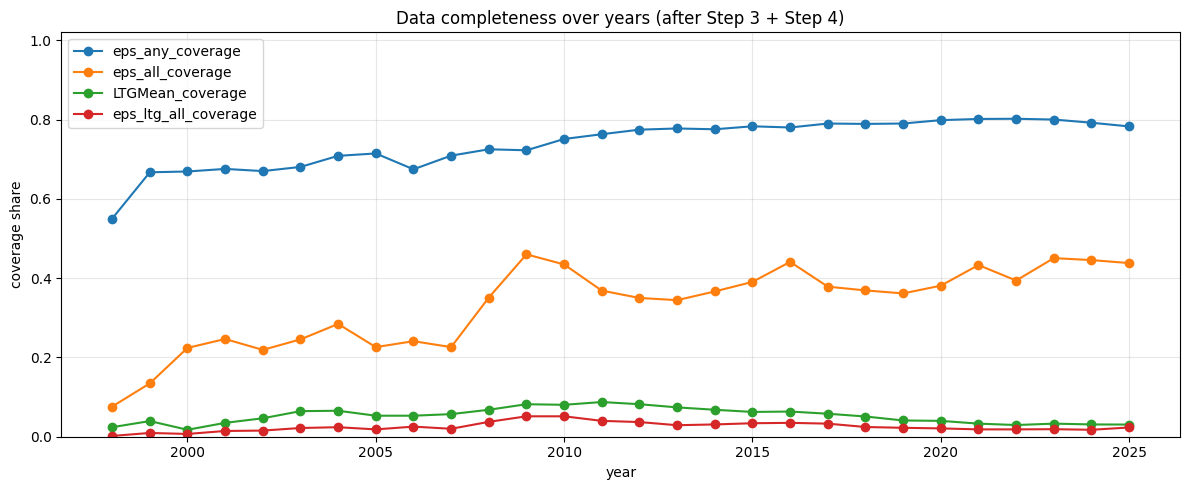

In [ ]:

if not EURO500_EPS_PATH.exists():
    raise FileNotFoundError(f'Missing file: {EURO500_EPS_PATH}')

cov = pd.read_parquet(EURO500_EPS_PATH).copy()

# Datumsanker fuer Jahresanalyse
if 'asof_date' in cov.columns:
    cov['asof_date'] = pd.to_datetime(cov['asof_date'], errors='coerce')
else:
    cov['asof_date'] = _asof_from_euro500(cov)

cov = cov[cov['asof_date'].notna()].copy()
if cov.empty:
    raise ValueError('No valid asof_date values found for completeness analysis.')

cov['year'] = cov['asof_date'].dt.year

eps_cols = [f'EPS_{h}' for h in HORIZONS]
for c in eps_cols + [LTG_COL]:
    if c not in cov.columns:
        cov[c] = np.nan
    cov[c] = pd.to_numeric(cov[c], errors='coerce')

cov['eps_any'] = cov[eps_cols].notna().any(axis=1)
cov['eps_all'] = cov[eps_cols].notna().all(axis=1)
cov['eps_ltg_all'] = cov['eps_all'] & cov[LTG_COL].notna()

agg = {'rows': ('year', 'size')}
for c in eps_cols + [LTG_COL]:
    agg[f'{c}_non_null'] = (c, lambda s: int(s.notna().sum()))
for c in ['eps_any', 'eps_all', 'eps_ltg_all']:
    agg[f'{c}_non_null'] = (c, lambda s: int(s.sum()))

by_year = cov.groupby('year', as_index=False).agg(**agg)

# Coverage-Raten ergaenzen
for c in eps_cols + [LTG_COL, 'eps_any', 'eps_all', 'eps_ltg_all']:
    by_year[f'{c}_coverage'] = by_year[f'{c}_non_null'] / by_year['rows']

# Lesbare Spaltenauswahl
show_cols = ['year', 'rows']
show_cols += [f'{c}_coverage' for c in eps_cols]
show_cols += [f'{LTG_COL}_coverage', 'eps_any_coverage', 'eps_all_coverage', 'eps_ltg_all_coverage']

print('Coverage by year (Step 3+4 outputs):')
display(by_year[show_cols].sort_values('year'))

# Schwachstellen: schlechteste Jahre
worst = (
    by_year[['year', 'eps_ltg_all_coverage']]
    .sort_values('eps_ltg_all_coverage', ascending=True)
    .head(10)
)
print('10 years with lowest joint EPS+LTG completeness:')
display(worst)

# Plot: Zeitverlauf der wichtigsten Coverage-Metriken
plot_cols = [
    'eps_any_coverage',
    'eps_all_coverage',
    f'{LTG_COL}_coverage',
    'eps_ltg_all_coverage',
]

fig, ax = plt.subplots(figsize=(12, 5))
for col in plot_cols:
    ax.plot(by_year['year'], by_year[col], marker='o', label=col)

ax.set_title('Data completeness over years (after Step 3 + Step 4)')
ax.set_xlabel('year')
ax.set_ylabel('coverage share')
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


# Zusatzplot: Non-Financials only (trbc_sector != 'financials')
if 'trbc_sector' in cov.columns:
    cov_nonfin = cov[cov['trbc_sector'].astype(str).str.strip().str.lower() != 'financials'].copy()
    if not cov_nonfin.empty:
        agg_nf = {'rows': ('year', 'size')}
        for c in eps_cols + [LTG_COL]:
            agg_nf[f'{c}_non_null'] = (c, lambda s: int(s.notna().sum()))
        for c in ['eps_any', 'eps_all', 'eps_ltg_all']:
            agg_nf[f'{c}_non_null'] = (c, lambda s: int(s.sum()))

        by_year_nf = cov_nonfin.groupby('year', as_index=False).agg(**agg_nf)
        for c in eps_cols + [LTG_COL, 'eps_any', 'eps_all', 'eps_ltg_all']:
            by_year_nf[f'{c}_coverage'] = by_year_nf[f'{c}_non_null'] / by_year_nf['rows']

        fig, ax = plt.subplots(figsize=(12, 5))
        for col in plot_cols:
            ax.plot(by_year_nf['year'], by_year_nf[col], marker='o', label=col)

        ax.set_title('Data completeness over years (Step 3+4, Non-Financials only)')
        ax.set_xlabel('year')
        ax.set_ylabel('coverage share')
        ax.set_ylim(0, 1.02)
        ax.grid(alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        print('No non-financial rows available for Non-Financials coverage plot.')
else:
    print('Column trbc_sector missing; skipping Non-Financials coverage plot.')





### 4B. LTG-Qualitaetscheck (Plausibilitaet)

Diese Analyse prueft die Guete der Spalte `LTGMean`.

Checks:
- Abdeckung gesamt und ueber die Zeit
- Verteilung (roh und winsorized)
- Plausibilitaetsbaender (z. B. extreme negative/positive LTG-Werte)
- Querschnittsmuster nach Sektor und Land


,rows_total,ltg_non_null,ltg_missing,coverage_share,ltg_lt_-1_count,ltg_gt_+1_count
0,54000,2890,51110,0.053519,280,2522


LTGMean describe (raw):


count    2890.000000
mean       12.754589
std        19.986561
min       -67.433330
1%        -21.877250
5%         -6.681000
25%         4.995418
50%        10.140950
75%        15.174285
95%        39.088500
99%        99.836336
max       245.100000
Name: LTGMean, dtype: float64

LTGMean describe (winsorized 1%-99%):


count    2890.000000
mean       12.340722
std        16.114078
min       -21.877250
1%        -21.830748
5%         -6.681000
25%         4.995418
50%        10.140950
75%        15.174285
95%        39.088500
99%        99.774333
max        99.836336
Name: LTGMean, dtype: float64

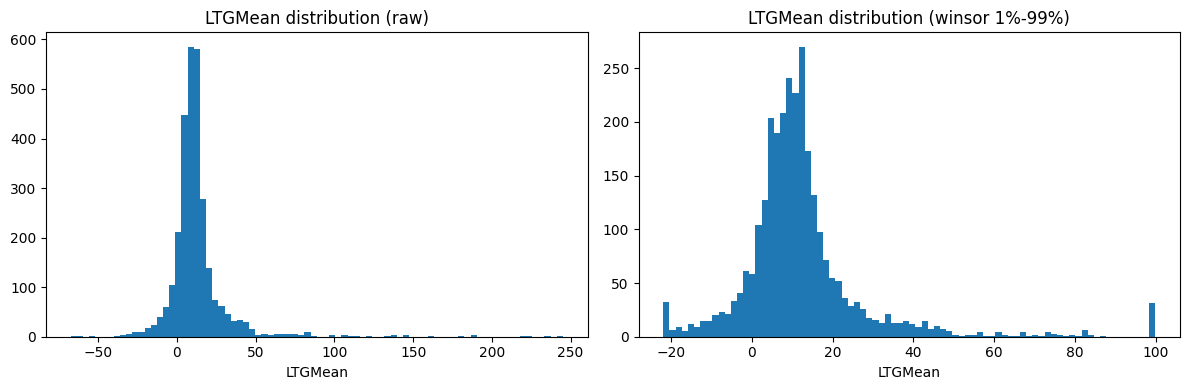

,year,rows,non_null,median,p10,p90,coverage
0,1998,500,12,15.716665,10.171000,25.212330,0.0240
1,1999,2000,79,10.000000,2.968000,18.254000,0.0395
2,2000,2000,35,11.500000,4.760000,21.910256,0.0175
3,2001,2000,70,10.766665,0.291000,19.323000,0.0350
4,2002,2000,93,10.963330,2.093334,16.544266,0.0465
5,2003,2000,129,9.915000,-0.332000,14.870666,0.0645
6,2004,2000,131,11.294000,4.225000,19.195000,0.0655
7,2005,2000,106,9.440000,2.765000,22.372500,0.0530
8,2006,2000,106,10.580000,4.197500,23.020000,0.0530
9,2007,2000,114,11.398335,2.650000,30.857500,0.0570


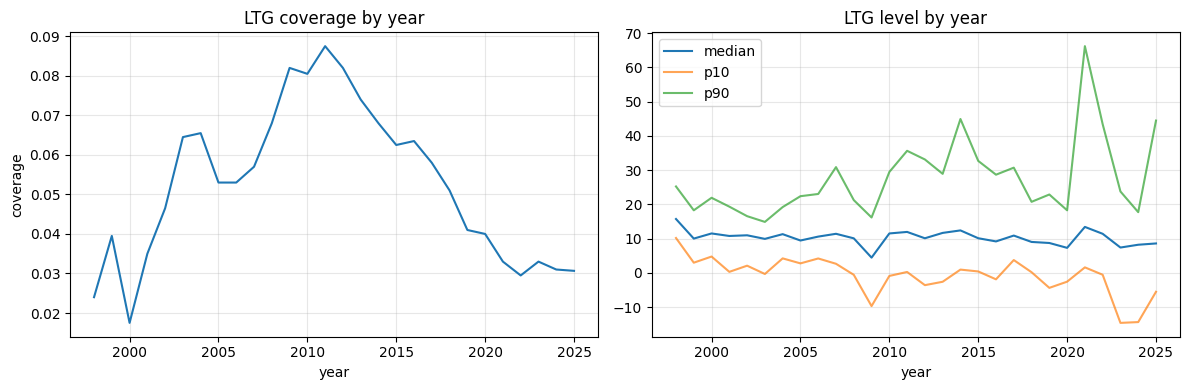

By trbc_sector:


,trbc_sector,n,non_null,median,mean,coverage
8,"Institutions, Associations & Organizations",11,5,8.92667,9.207334,0.454545
6,Healthcare,4135,555,11.06667,15.265868,0.134220
4,Energy,2280,264,4.94750,4.929650,0.115789
11,Utilities,2964,265,12.75000,14.431944,0.089406
3,Consumer Non-Cyclicals,3805,246,9.69500,14.935391,0.064652
1,Basic Materials,5528,346,11.61979,15.371096,0.062590
7,Industrials,9877,601,8.70000,10.648249,0.060848
9,Real Estate,2992,160,15.13357,22.059573,0.053476
10,Technology,5971,199,6.80000,5.574200,0.033328
2,Consumer Cyclicals,8488,249,11.18333,12.792667,0.029336


By hq_country:


,hq_country,n,non_null,median,mean,coverage
3,Cyprus,51,16,13.650000,12.202396,0.313725
1,Belgium,3457,392,10.950355,13.410188,0.113393
18,Spain,4429,375,12.549000,11.637192,0.084669
6,France,12325,994,9.715835,12.931053,0.080649
10,Italy,5537,291,9.030000,9.740393,0.052556
9,Ireland,2993,151,10.400000,15.269666,0.050451
0,Austria,2555,115,9.214000,15.763433,0.045010
14,Netherlands,3850,120,5.050000,6.945367,0.031169
15,Portugal,1147,33,9.750000,9.342879,0.028771
7,Germany,11409,324,8.294585,13.240064,0.028399


In [ ]:

if not EURO500_EPS_PATH.exists():
    raise FileNotFoundError(f'Missing file: {EURO500_EPS_PATH}')

ltg_df = pd.read_parquet(EURO500_EPS_PATH).copy()
if 'LTGMean' not in ltg_df.columns:
    raise KeyError('Column LTGMean not found. Run Step 4 first.')

# Datentypen / Datumsfelder
for dc in ['asof_date', 'date', 'formation_date', 'effective_date']:
    if dc in ltg_df.columns:
        ltg_df[dc] = pd.to_datetime(ltg_df[dc], errors='coerce')

ltg_df['LTGMean'] = pd.to_numeric(ltg_df['LTGMean'], errors='coerce')

if 'asof_date' in ltg_df.columns and ltg_df['asof_date'].notna().any():
    ltg_df['year'] = ltg_df['asof_date'].dt.year
elif 'date' in ltg_df.columns:
    ltg_df['year'] = ltg_df['date'].dt.year
else:
    ltg_df['year'] = pd.NA

# 1) Overall coverage + basic stats
n_total = len(ltg_df)
n_non_null = int(ltg_df['LTGMean'].notna().sum())
n_missing = n_total - n_non_null
coverage = (n_non_null / n_total) if n_total else np.nan

outlier_lo = (ltg_df['LTGMean'] < -1).sum()
outlier_hi = (ltg_df['LTGMean'] > 1).sum()

summary = pd.DataFrame([{
    'rows_total': n_total,
    'ltg_non_null': n_non_null,
    'ltg_missing': n_missing,
    'coverage_share': coverage,
    'ltg_lt_-1_count': int(outlier_lo),
    'ltg_gt_+1_count': int(outlier_hi),
}])
display(summary)

ltg_ok = ltg_df['LTGMean'].dropna()
if len(ltg_ok) > 0:
    print('LTGMean describe (raw):')
    display(ltg_ok.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

    p01, p99 = ltg_ok.quantile([0.01, 0.99])
    ltg_w = ltg_ok.clip(lower=p01, upper=p99)
    print('LTGMean describe (winsorized 1%-99%):')
    display(ltg_w.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].hist(ltg_ok, bins=80)
    ax[0].set_title('LTGMean distribution (raw)')
    ax[0].set_xlabel('LTGMean')

    ax[1].hist(ltg_w, bins=80)
    ax[1].set_title('LTGMean distribution (winsor 1%-99%)')
    ax[1].set_xlabel('LTGMean')
    plt.tight_layout()
    plt.show()


    # Zusatzplot: LTG coverage by year (Non-Financials only)
    if 'trbc_sector' in ltg_df.columns:
        ltg_nonfin = ltg_df[ltg_df['trbc_sector'].astype(str).str.strip().str.lower() != 'financials'].copy()
        if ltg_nonfin['year'].notna().any():
            cov_year_nf = ltg_nonfin.groupby('year', as_index=False).agg(
                rows=('LTGMean', 'size'),
                non_null=('LTGMean', lambda s: s.notna().sum()),
                median=('LTGMean', 'median'),
                p10=('LTGMean', lambda s: s.quantile(0.10)),
                p90=('LTGMean', lambda s: s.quantile(0.90)),
            )
            cov_year_nf['coverage'] = cov_year_nf['non_null'] / cov_year_nf['rows']

            fig, ax = plt.subplots(1, 2, figsize=(12, 4))
            ax[0].plot(cov_year_nf['year'], cov_year_nf['coverage'])
            ax[0].set_title('LTG coverage by year (Non-Financials)')
            ax[0].set_xlabel('year')
            ax[0].set_ylabel('coverage')
            ax[0].set_ylim(0, 1.02)
            ax[0].grid(alpha=0.3)

            ax[1].plot(cov_year_nf['year'], cov_year_nf['median'], label='median')
            ax[1].plot(cov_year_nf['year'], cov_year_nf['p10'], label='p10', alpha=0.7)
            ax[1].plot(cov_year_nf['year'], cov_year_nf['p90'], label='p90', alpha=0.7)
            ax[1].set_title('LTG level by year (Non-Financials)')
            ax[1].set_xlabel('year')
            ax[1].legend()
            ax[1].grid(alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print('No valid year info for LTG Non-Financials coverage plot.')
    else:
        print('Column trbc_sector missing; skipping LTG Non-Financials coverage plot.')


else:
    print('No non-null LTGMean values found.')

# 2) Coverage over time
if 'year' in ltg_df.columns and ltg_df['year'].notna().any():
    cov_year = ltg_df.groupby('year', as_index=False).agg(
        rows=('LTGMean', 'size'),
        non_null=('LTGMean', lambda s: s.notna().sum()),
        median=('LTGMean', 'median'),
        p10=('LTGMean', lambda s: s.quantile(0.10)),
        p90=('LTGMean', lambda s: s.quantile(0.90)),
    )
    cov_year['coverage'] = cov_year['non_null'] / cov_year['rows']
    display(cov_year.head(20))

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(cov_year['year'], cov_year['coverage'])
    ax[0].set_title('LTG coverage by year')
    ax[0].set_xlabel('year')
    ax[0].set_ylabel('coverage')
    ax[0].grid(alpha=0.3)

    ax[1].plot(cov_year['year'], cov_year['median'], label='median')
    ax[1].plot(cov_year['year'], cov_year['p10'], label='p10', alpha=0.7)
    ax[1].plot(cov_year['year'], cov_year['p90'], label='p90', alpha=0.7)
    ax[1].set_title('LTG level by year')
    ax[1].set_xlabel('year')
    ax[1].legend()
    ax[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



    # Zusatzplot: LTG coverage by year (Non-Financials, coverage section)
    if 'trbc_sector' in ltg_df.columns:
        ltg_nonfin_cov = ltg_df[ltg_df['trbc_sector'].astype(str).str.strip().str.lower() != 'financials'].copy()
        if ltg_nonfin_cov['year'].notna().any():
            cov_year_nf = ltg_nonfin_cov.groupby('year', as_index=False).agg(
                rows=('LTGMean', 'size'),
                non_null=('LTGMean', lambda s: s.notna().sum()),
                median=('LTGMean', 'median'),
                p10=('LTGMean', lambda s: s.quantile(0.10)),
                p90=('LTGMean', lambda s: s.quantile(0.90)),
            )
            cov_year_nf['coverage'] = cov_year_nf['non_null'] / cov_year_nf['rows']

            fig, ax = plt.subplots(1, 2, figsize=(12, 4))
            ax[0].plot(cov_year_nf['year'], cov_year_nf['coverage'])
            ax[0].set_title('LTG coverage by year (Non-Financials)')
            ax[0].set_xlabel('year')
            ax[0].set_ylabel('coverage')
            ax[0].set_ylim(0, 1.02)
            ax[0].grid(alpha=0.3)

            ax[1].plot(cov_year_nf['year'], cov_year_nf['median'], label='median')
            ax[1].plot(cov_year_nf['year'], cov_year_nf['p10'], label='p10', alpha=0.7)
            ax[1].plot(cov_year_nf['year'], cov_year_nf['p90'], label='p90', alpha=0.7)
            ax[1].set_title('LTG level by year (Non-Financials)')
            ax[1].set_xlabel('year')
            ax[1].legend()
            ax[1].grid(alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print('No valid year info for LTG Non-Financials coverage plot.')
    else:
        print('Column trbc_sector missing; skipping LTG Non-Financials coverage plot.')

# 3) Cross-section by sector / country
for grp_col in ['trbc_sector', 'hq_country']:
    if grp_col in ltg_df.columns:
        g = (
            ltg_df.groupby(grp_col, dropna=False)['LTGMean']
            .agg(n='size', non_null=lambda s: s.notna().sum(), median='median', mean='mean')
            .reset_index()
        )
        g['coverage'] = g['non_null'] / g['n']
        g = g.sort_values(['coverage', 'n'], ascending=[False, False])
        print(f'By {grp_col}:')
        display(g.head(20))



## 5. Modul A: Annual Balance Sheet (FY)

Geladene Targets:
- `BE` (Book Equity)
- `assets`
- `debt`

Pull-Logik (konsistent mit DailyReturns-Workflow):
- Fallback-ID-Kette: `ISIN -> RIC_current -> RIC`
- Cache je `firm_id` und Kandidat-ID
- Nur fehlende Zeitsegmente werden nachgezogen
- As-of-Mapping via `merge_asof` (backward, mit Toleranzfenster)


In [6]:
# ------------------------------------------------------------
# Step 5 — Netpayout Table (clean): BE, assets, debt + beta
#   Input  : euro500.parquet
#   Output : euro500_netpayout.parquet
# ------------------------------------------------------------


# -------------------------
# Config
# -------------------------
BASE_PATH = DATA_DIR / 'euro500.parquet'
OUTPUT_PATH = DATA_DIR / 'euro500_netpayout.parquet'
CACHE_DIR = DATA_DIR / 'moduleA_cache_by_company_id'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
BAD_LOG_PATH = DATA_DIR / 'moduleA_bad_ids.csv'
STEP5_ROWS_PATH = DATA_DIR / 'moduleA_step5_rows.parquet'
STEP5_CKPT_PATH = DATA_DIR / 'moduleA_step5_checkpoint.json'


TARGET_FIELDS = {
    'BE': 'TR.F.COMEQTOT(Period=FY0)',
    'assets': 'TR.F.TOTASSETS(Period=FY0)',
    'debt': 'TR.F.DEBTTOT(Period=FY0)',
}
TARGET_COLS = list(TARGET_FIELDS.keys())

ASOF_TOL_DAYS = 365
MAX_RETRIES = 2
BASE_SLEEP = 1.0
FORCE_REFRESH = False
CACHE_ONLY = False  # False => allow LSEG pull (cache still used)
CACHE_VERSION = 'v2'
DEBUG_FIRST_RAW = True
DEBUG_SHOWN = {'done': False}
DEBUG_VERBOSE = False
DEBUG_MAX_COMPANIES = 15

BATCH_SIZE = 100
BATCH_PAUSE_SEC = 0
MULTI_UNIVERSE_CHUNK = 25

RATE_LIMIT_EVENTS = 0
LAST_GETDATA_ERR_MSG = ""

# LSEG request governor (to avoid 429 storms)
MIN_CALL_INTERVAL_SEC = 0.7
RATE_LIMIT_COOLDOWN_SEC = 3.0
RATE_LIMIT_MULTIPLIER = 1.5
RATE_LIMIT_HARD_PAUSE_SEC = 10.0
RATE_LIMIT_STREAK_TRIGGER = 2
FAIL_FAST_ON_RATE_LIMIT = True
LAST_CALL_TS = 0.0
GLOBAL_COOLDOWN_UNTIL = 0.0
RATE_LIMIT_STREAK = 0

if not BASE_PATH.exists():
    raise FileNotFoundError(f'Missing file: {BASE_PATH}')

# -------------------------
# Helpers
# -------------------------
def _clean_str(s: pd.Series) -> pd.Series:
    x = s.astype('string').str.strip()
    return x.where(x.notna() & (x != ''), pd.NA)


def _resolve_asof(df: pd.DataFrame) -> pd.Series:
    if 'asof_date' in df.columns:
        return pd.to_datetime(df['asof_date'], errors='coerce').dt.normalize()
    if 'date' in df.columns:
        return pd.to_datetime(df['date'], errors='coerce').dt.normalize()
    if 'formation_date' in df.columns:
        return pd.to_datetime(df['formation_date'], errors='coerce').dt.normalize()
    if 'effective_date' in df.columns:
        return pd.to_datetime(df['effective_date'], errors='coerce').dt.normalize()
    raise ValueError('No usable as-of column found (asof_date/date/formation_date/effective_date).')


def _flatten_cols(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    if isinstance(x.columns, pd.MultiIndex):
        x.columns = [' | '.join([str(v) for v in tup if v is not None]).strip() for tup in x.columns]
    else:
        x.columns = [str(c).strip() for c in x.columns]
    return x


def _build_company_candidates(company_req: pd.DataFrame) -> list[tuple[str, str]]:
    """Collect all unique identifiers for one company across time."""
    q = company_req.copy().sort_values('asof_date')

    out = []
    seen = set()

    def _norm_isin(value):
        if pd.isna(value):
            return ''
        v = str(value).strip()
        if not v:
            return ''
        if v.upper().startswith('ISIN:'):
            v = v.split(':', 1)[1].strip()
        return v

    def _add(id_type: str, value):
        if pd.isna(value):
            return
        v = str(value).strip()
        if not v:
            return
        key = (id_type, v)
        if key in seen:
            return
        seen.add(key)
        out.append(key)

    if 'ISIN' in q.columns:
        for val in q['ISIN']:
            isin = _norm_isin(val)
            if isin:
                _add('ISIN', isin)
                _add('ISIN', f'ISIN:{isin}')

    if 'RIC_current' in q.columns:
        for val in q['RIC_current']:
            _add('RIC', val)

    if 'RIC' in q.columns:
        for val in q['RIC']:
            _add('RIC', val)

    if 'pull_id' in q.columns and 'id_type' in q.columns:
        for id_type, pull_id in zip(q['id_type'], q['pull_id']):
            it = str(id_type).upper().strip() if pd.notna(id_type) else ''
            if it == 'ISIN':
                isin = _norm_isin(pull_id)
                if isin:
                    _add('ISIN', isin)
                    _add('ISIN', f'ISIN:{isin}')
            elif it == 'RIC':
                _add('RIC', pull_id)

    return out


def _cache_file(firm_id: str, id_type: str, pull_id: str) -> Path:
    raw = f'{firm_id}|{id_type}|{pull_id}'
    h = hashlib.sha1(raw.encode('utf-8')).hexdigest()[:12]
    clean = re.sub(r'[^A-Za-z0-9._-]', '_', firm_id)
    preferred = CACHE_DIR / f"{clean[:70]}__{id_type}_{h}__{CACHE_VERSION}.parquet"
    if preferred.exists():
        return preferred

    # Fallback: allow changed firm_id while keeping same (id_type, pull_id) hash.
    matches = sorted(CACHE_DIR.glob(f"*__{id_type}_{h}__{CACHE_VERSION}.parquet"))
    if matches:
        return matches[0]

    # Legacy fallback without explicit cache version suffix.
    legacy = sorted(CACHE_DIR.glob(f"*__{id_type}_{h}.parquet"))
    if legacy:
        return legacy[0]

    return preferred


def _load_cache(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS)
    d = pd.read_parquet(path).copy()
    d['asof_date'] = pd.to_datetime(d.get('asof_date'), errors='coerce').dt.normalize()
    for c in TARGET_COLS:
        if c not in d.columns:
            d[c] = np.nan
        d[c] = pd.to_numeric(d[c], errors='coerce')
    d = d.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return d[['asof_date'] + TARGET_COLS]


def _save_cache(path: Path, d: pd.DataFrame) -> None:
    out = d.copy()
    out['asof_date'] = pd.to_datetime(out['asof_date'], errors='coerce').dt.normalize()
    for c in TARGET_COLS:
        out[c] = pd.to_numeric(out[c], errors='coerce')
    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    tmp = path.with_suffix(path.suffix + '.tmp')
    out.to_parquet(tmp, index=False)
    tmp.replace(path)


def _extract_history(raw: pd.DataFrame, value_col_name: str) -> pd.DataFrame:
    if raw is None or len(raw) == 0:
        return pd.DataFrame(columns=['asof_date', value_col_name])

    x = _flatten_cols(pd.DataFrame(raw).reset_index())
    if x.empty:
        return pd.DataFrame(columns=['asof_date', value_col_name])

    date_col = None
    for c in x.columns:
        if 'date' in c.lower() or c.lower() == 'date':
            date_col = c
            break
    if date_col is None:
        date_col = x.columns[0]

    id_like = set()
    for c in x.columns:
        cl = c.lower()
        if c == date_col:
            continue
        if cl in {'instrument', 'ric', 'isin'} or 'instrument' in cl or cl.endswith('ric') or cl.endswith('isin'):
            id_like.add(c)

    value_candidates = [c for c in x.columns if c != date_col and c not in id_like]
    if not value_candidates:
        return pd.DataFrame(columns=['asof_date', value_col_name])

    best = None
    best_n = -1
    for c in value_candidates:
        n = int(pd.to_numeric(x[c], errors='coerce').notna().sum())
        if n > best_n:
            best_n = n
            best = c

    if best is None or best_n <= 0:
        return pd.DataFrame(columns=['asof_date', value_col_name])

    out = pd.DataFrame({
        'asof_date': pd.to_datetime(x[date_col], errors='coerce').dt.normalize(),
        value_col_name: pd.to_numeric(x[best], errors='coerce'),
    })
    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return out[['asof_date', value_col_name]]


def _govern_requests() -> None:
    global LAST_CALL_TS, GLOBAL_COOLDOWN_UNTIL
    now = time.time()
    if now < GLOBAL_COOLDOWN_UNTIL:
        wait = GLOBAL_COOLDOWN_UNTIL - now
        if wait > 0:
            time.sleep(wait)
    now = time.time()
    gap = now - LAST_CALL_TS
    if gap < MIN_CALL_INTERVAL_SEC:
        time.sleep(MIN_CALL_INTERVAL_SEC - gap)


def _cache_covers_range(cached: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp) -> bool:
    if cached is None or cached.empty:
        return False
    cmin = cached['asof_date'].min()
    cmax = cached['asof_date'].max()
    has_any_cached_value = bool(cached[TARGET_COLS].notna().any().any()) if not cached.empty else False
    return bool(pd.notna(cmin) and pd.notna(cmax) and cmin <= start and cmax >= end and has_any_cached_value)


def _call_get_data(universe: list[str], fields: list[str], params: dict, dbg_label: str) -> pd.DataFrame:
    global LAST_CALL_TS, GLOBAL_COOLDOWN_UNTIL, RATE_LIMIT_STREAK, RATE_LIMIT_EVENTS, LAST_GETDATA_ERR_MSG

    LAST_GETDATA_ERR_MSG = ""
    last_err = None
    raw = None
    for r in range(MAX_RETRIES):
        try:
            _govern_requests()
            raw = ld.get_data(universe=universe, fields=fields, parameters=params)
            LAST_CALL_TS = time.time()
            RATE_LIMIT_STREAK = 0
            LAST_GETDATA_ERR_MSG = ""
            break
        except Exception as e:
            LAST_CALL_TS = time.time()
            last_err = e
            LAST_GETDATA_ERR_MSG = str(e)
            msg = str(e)
            is_rate_limit = 'Too many requests' in msg or '429' in msg
            if is_rate_limit:
                RATE_LIMIT_STREAK += 1
                RATE_LIMIT_EVENTS += 1
                cooldown = RATE_LIMIT_COOLDOWN_SEC * (RATE_LIMIT_MULTIPLIER ** r) + random.random()
                if RATE_LIMIT_STREAK >= RATE_LIMIT_STREAK_TRIGGER:
                    cooldown = max(cooldown, RATE_LIMIT_HARD_PAUSE_SEC)
                GLOBAL_COOLDOWN_UNTIL = max(GLOBAL_COOLDOWN_UNTIL, time.time() + cooldown)
                if DEBUG_VERBOSE:
                    print(f'[DEBUG rate limit] id={dbg_label} retry={r+1}/{MAX_RETRIES} streak={RATE_LIMIT_STREAK} cooldown={cooldown:.1f}s err={type(e).__name__}: {e}')
                if FAIL_FAST_ON_RATE_LIMIT:
                    break
                time.sleep(cooldown)
            else:
                RATE_LIMIT_STREAK = 0
                if DEBUG_VERBOSE:
                    print(f'[DEBUG get_data error] id={dbg_label} retry={r+1}/{MAX_RETRIES} err={type(e).__name__}: {e}')
                time.sleep(BASE_SLEEP * (2 ** r) + random.random() * 0.3)

    if raw is None or len(raw) == 0:
        if DEBUG_VERBOSE:
            if last_err is not None:
                print(f'[DEBUG empty raw after errors] id={dbg_label} last_err={type(last_err).__name__}: {last_err} (skipped)')
            else:
                print(f'[DEBUG empty raw no exception] id={dbg_label}')
        return pd.DataFrame()

    return pd.DataFrame(raw)


def _hist_from_flat_frame(x: pd.DataFrame) -> pd.DataFrame:
    if x is None or x.empty:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS)

    x = _flatten_cols(x)
    if x.empty:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS)

    date_col = None
    for c in x.columns:
        uc = c.upper()
        if 'PERIOD' in uc and 'DATE' in uc:
            date_col = c
            break
    if date_col is None:
        for c in x.columns:
            if 'date' in c.lower():
                date_col = c
                break
    if date_col is None:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS)

    out = pd.DataFrame({'asof_date': pd.to_datetime(x[date_col], errors='coerce').dt.normalize()})

    def _norm(s: str) -> str:
        return re.sub(r'[^A-Z0-9]', '', str(s).upper())

    def _field_token(field_expr: str) -> str:
        m = re.search(r'TR\.F\.([A-Z0-9_]+)', str(field_expr), flags=re.IGNORECASE)
        return _norm(m.group(1)) if m else _norm(field_expr)

    fallback_tokens = {
        'BE': ['COMEQTOT', 'COMEQ', 'EQUITY', 'COMMONEQUITY', 'BOOKEQUITY'],
        'assets': ['TOTASSETS', 'TOTALASSETS', 'ASSETS'],
        'debt': ['DEBTTOT', 'TOTALDEBT', 'DEBT'],
    }

    norm_cols = {c: _norm(c) for c in x.columns}

    for tgt, field_expr in TARGET_FIELDS.items():
        token = _field_token(field_expr)
        cand = None
        for c, cn in norm_cols.items():
            if token and (token in cn or cn in token):
                cand = c
                break
        if cand is None:
            for alt in fallback_tokens.get(tgt, []):
                alt_n = _norm(alt)
                for c, cn in norm_cols.items():
                    if alt_n and alt_n in cn:
                        cand = c
                        break
                if cand is not None:
                    break
        out[tgt] = pd.to_numeric(x[cand], errors='coerce') if cand is not None else np.nan

    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return out[['asof_date'] + TARGET_COLS]


def _pull_targets_segment(pull_id: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    if pd.isna(start) or pd.isna(end) or start > end:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS)

    params = {
        'SDate': start.strftime('%Y-%m-%d'),
        'EDate': end.strftime('%Y-%m-%d'),
        'Frq': 'FY',
    }
    fields = ['TR.F.PeriodEndDate(Period=FY0)'] + list(TARGET_FIELDS.values())

    raw_df = _call_get_data(universe=[pull_id], fields=fields, params=params, dbg_label=pull_id)
    if raw_df.empty:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS)

    if DEBUG_FIRST_RAW and (not DEBUG_SHOWN['done']):
        print('DEBUG first raw get_data shape:', raw_df.shape)
        print('DEBUG first raw columns:', list(raw_df.columns)[:20])
        try:
            nn = raw_df.notna().sum()
            print('DEBUG first raw non-null counts (top):')
            print(nn.head(20))
        except Exception:
            pass
        DEBUG_SHOWN['done'] = True

    return _hist_from_flat_frame(raw_df)


def _pull_targets_multi_segment(pull_ids: list[str], start: pd.Timestamp, end: pd.Timestamp) -> dict[str, pd.DataFrame]:
    if not pull_ids or pd.isna(start) or pd.isna(end) or start > end:
        return {}

    uniq = []
    seen = set()
    for pid in pull_ids:
        v = str(pid).strip()
        if not v:
            continue
        k = v.upper()
        if k in seen:
            continue
        seen.add(k)
        uniq.append(v)

    if not uniq:
        return {}

    params = {
        'SDate': start.strftime('%Y-%m-%d'),
        'EDate': end.strftime('%Y-%m-%d'),
        'Frq': 'FY',
    }
    fields = ['TR.F.PeriodEndDate(Period=FY0)'] + list(TARGET_FIELDS.values())

    out = {pid: pd.DataFrame(columns=['asof_date'] + TARGET_COLS) for pid in uniq}

    def _assign_from_raw(ids: list[str], raw_df: pd.DataFrame) -> None:
        if raw_df is None or raw_df.empty:
            return
        x = _flatten_cols(raw_df)
        if x.empty:
            return

        inst_col = None
        for c in x.columns:
            cl = c.lower()
            if 'instrument' in cl or cl in {'ric', 'isin'}:
                inst_col = c
                break

        if inst_col is None:
            if len(ids) == 1:
                out[ids[0]] = _hist_from_flat_frame(x)
            return

        inst_norm = x[inst_col].astype('string').str.strip().str.upper()
        for pid in ids:
            g = x.loc[inst_norm == str(pid).upper()].copy()
            if g.empty:
                continue
            out[pid] = _hist_from_flat_frame(g)

    def _periodend_collect_error(msg: str) -> bool:
        m = (msg or '').lower()
        return ('unable to collect data for the field' in m) and ('periodenddate' in m)

    def _fetch_ids(ids: list[str]) -> None:
        if not ids:
            return
        label = f'multi[{len(ids)}]:' + ','.join(ids[:3])
        raw_df = _call_get_data(universe=ids, fields=fields, params=params, dbg_label=label)

        if raw_df.empty:
            err = LAST_GETDATA_ERR_MSG
            # Some bad identifiers can poison a whole multi request: split recursively.
            if len(ids) > 1 and _periodend_collect_error(err):
                mid = len(ids) // 2
                left = ids[:mid]
                right = ids[mid:]
                if DEBUG_VERBOSE:
                    print(f'[DEBUG multi split] size={len(ids)} -> {len(left)}+{len(right)} due to PeriodEndDate collect error')
                _fetch_ids(left)
                _fetch_ids(right)
            return

        _assign_from_raw(ids, raw_df)

    for i in range(0, len(uniq), MULTI_UNIVERSE_CHUNK):
        chunk = uniq[i:i+MULTI_UNIVERSE_CHUNK]
        _fetch_ids(chunk)

    return out


def _combine(frames: list[pd.DataFrame]) -> pd.DataFrame:

    recs = []
    for f in frames:
        if f is None or not isinstance(f, pd.DataFrame) or f.empty:
            continue
        g = f.copy()
        for c in ['asof_date'] + TARGET_COLS:
            if c not in g.columns:
                g[c] = np.nan if c != 'asof_date' else pd.NaT
        g = g[['asof_date'] + TARGET_COLS]
        g = g.loc[~g.isna().all(axis=1)]
        if g.empty:
            continue
        recs.extend(g.to_dict('records'))

    if not recs:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS)

    out = pd.DataFrame.from_records(recs, columns=['asof_date'] + TARGET_COLS)
    out['asof_date'] = pd.to_datetime(out['asof_date'], errors='coerce').dt.normalize()
    for c in TARGET_COLS:
        out[c] = pd.to_numeric(out[c], errors='coerce')
    return out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')


def _update_cache(firm_id: str, id_type: str, pull_id: str, start: pd.Timestamp, end: pd.Timestamp, force_refresh: bool = False) -> pd.DataFrame:
    path = _cache_file(firm_id, id_type, pull_id)
    cached = pd.DataFrame(columns=['asof_date'] + TARGET_COLS) if force_refresh else _load_cache(path)

    segments = []
    if cached.empty:
        segments.append((start, end))
    else:
        cmin = cached['asof_date'].min()
        cmax = cached['asof_date'].max()
        has_any_cached_value = bool(cached[TARGET_COLS].notna().any().any()) if not cached.empty else False
        # short-circuit only if cache covers range AND contains at least one real value
        if pd.notna(cmin) and pd.notna(cmax) and cmin <= start and cmax >= end and has_any_cached_value and (not force_refresh):
            return cached
        if start < cmin:
            segments.append((start, cmin - pd.Timedelta(days=1)))
        if end > cmax:
            segments.append((cmax + pd.Timedelta(days=1), end))

    pulled = []
    for sdt, edt in segments:
        if sdt > edt:
            continue
        seg = _pull_targets_segment(pull_id, sdt, edt)
        if not seg.empty:
            pulled.append(seg)

    combined = _combine([cached] + pulled)
    if not combined.empty or force_refresh:
        _save_cache(path, combined)

    out = _load_cache(path)
    return out if not out.empty else combined


def _map_to_asof(req_dates: pd.Series, hist: pd.DataFrame, tol_days: int) -> pd.DataFrame:
    left = pd.DataFrame({'asof_date': pd.to_datetime(req_dates, errors='coerce').dt.normalize()}).dropna().sort_values('asof_date')
    if left.empty:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS)

    if hist is None or hist.empty:
        for c in TARGET_COLS:
            left[c] = np.nan
        return left

    right = hist[['asof_date'] + TARGET_COLS].copy().sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    out = pd.merge_asof(
        left,
        right,
        on='asof_date',
        direction='backward',
        tolerance=pd.Timedelta(days=ASOF_TOL_DAYS),
    )
    return out


rebuild_output = FORCE_REFRESH or (locals().get('N', 0) > 0) or (not STEP5_ROWS_PATH.exists()) or (not OUTPUT_PATH.exists())
if (not rebuild_output) and BASE_PATH.exists() and OUTPUT_PATH.exists():
    rebuild_output = BASE_PATH.stat().st_mtime > OUTPUT_PATH.stat().st_mtime


def _build_step5_rows_from_cache(base_df: pd.DataFrame) -> pd.DataFrame:
    req_cols = [c for c in ['firm_id', 'asof_date', 'ISIN', 'RIC_current', 'RIC', 'id_type', 'pull_id'] if c in base_df.columns]
    req = (
        base_df[req_cols]
        .dropna(subset=['firm_id', 'asof_date'])
        .drop_duplicates(['firm_id', 'asof_date'], keep='last')
        .copy()
    )
    if req.empty:
        return pd.DataFrame(columns=['firm_id', 'asof_date'] + TARGET_COLS)

    rows = []
    groups = req.groupby('firm_id', sort=False)
    total = len(groups)
    for ix, (firm_id, g) in enumerate(groups, start=1):
        dates = pd.to_datetime(g['asof_date'], errors='coerce').dropna().sort_values().unique()
        panel = pd.DataFrame({'asof_date': pd.to_datetime(dates)})
        for c in TARGET_COLS:
            panel[c] = np.nan

        # Dynamic candidate list per company using the same normalization as in main pull logic.
        uniq = _build_company_candidates(g)

        for id_type, pull_id in uniq:
            hist = _load_cache(_cache_file(str(firm_id), str(id_type), str(pull_id)))
            if hist.empty:
                continue
            mapped = _map_to_asof(panel['asof_date'], hist, ASOF_TOL_DAYS)
            if mapped.empty:
                continue
            for c in TARGET_COLS:
                if c in mapped.columns:
                    panel[c] = pd.to_numeric(panel[c], errors='coerce').combine_first(pd.to_numeric(mapped[c], errors='coerce'))
            if panel[TARGET_COLS].notna().all(axis=1).all():
                break

        panel.insert(0, 'firm_id', str(firm_id))
        rows.append(panel[['firm_id', 'asof_date'] + TARGET_COLS])

        if ix % 100 == 0 or ix == total:
            found = int(panel[TARGET_COLS].notna().all(axis=1).sum())
            print(f'[Step5 cache rebuild] {ix}/{total} company={str(firm_id)[:40]} resolved_rows={found}/{len(panel)}')

    if not rows:
        return pd.DataFrame(columns=['firm_id', 'asof_date'] + TARGET_COLS)

    out = pd.concat(rows, ignore_index=True)
    out['asof_date'] = pd.to_datetime(out['asof_date'], errors='coerce').dt.normalize()
    for c in TARGET_COLS:
        out[c] = pd.to_numeric(out[c], errors='coerce')
    out = out.sort_values(['firm_id', 'asof_date']).drop_duplicates(['firm_id', 'asof_date'], keep='last')
    return out


# -------------------------
# Pull loop (batched + resume)
# -------------------------
if 'base' not in locals():
    base = pd.read_parquet(BASE_PATH).copy()
    if 'asof_date' not in base.columns:
        base['asof_date'] = _resolve_asof(base)
    else:
        base['asof_date'] = pd.to_datetime(base['asof_date'], errors='coerce').dt.normalize()

    for c in ['firm_id', 'ISIN', 'RIC_current', 'RIC', 'pull_id', 'id_type']:
        if c in base.columns:
            base[c] = _clean_str(base[c])

    if 'id_type' not in base.columns:
        base['id_type'] = np.select(
            [base.get('ISIN', pd.Series(pd.NA, index=base.index)).notna(),
             base.get('RIC_current', pd.Series(pd.NA, index=base.index)).notna(),
             base.get('RIC', pd.Series(pd.NA, index=base.index)).notna()],
            ['ISIN', 'RIC', 'RIC'],
            default=pd.NA,
        )
    if 'pull_id' not in base.columns:
        base['pull_id'] = np.select(
            [base.get('ISIN', pd.Series(pd.NA, index=base.index)).notna(),
             base.get('RIC_current', pd.Series(pd.NA, index=base.index)).notna(),
             base.get('RIC', pd.Series(pd.NA, index=base.index)).notna()],
            [base.get('ISIN', pd.Series(pd.NA, index=base.index)),
             base.get('RIC_current', pd.Series(pd.NA, index=base.index)),
             base.get('RIC', pd.Series(pd.NA, index=base.index))],
            default=pd.NA,
        )

    base['id_type'] = _clean_str(base['id_type'])
    base['pull_id'] = _clean_str(base['pull_id'])

    if 'firm_id' not in base.columns:
        base['firm_id'] = pd.Series(pd.NA, index=base.index, dtype='string')

req_cols = [c for c in ['firm_id', 'asof_date', 'ISIN', 'RIC_current', 'RIC', 'id_type', 'pull_id'] if c in base.columns]
req = (
    base[req_cols]
    .dropna(subset=['firm_id', 'asof_date'])
    .drop_duplicates(['firm_id', 'asof_date'], keep='last')
    .reset_index(drop=True)
)
if req.empty:
    raise ValueError('No valid (firm_id, asof_date) rows found for Step 5.')

company_candidates_map = {}
for ck, g in req.groupby('firm_id', sort=False):
    company_candidates_map[str(ck)] = _build_company_candidates(g)

companies_all = req['firm_id'].dropna().astype(str).unique().tolist()
N_total = len(companies_all)

existing_step_rows = pd.DataFrame(columns=['firm_id', 'asof_date'] + TARGET_COLS)
if STEP5_ROWS_PATH.exists():
    try:
        existing_step_rows = pd.read_parquet(STEP5_ROWS_PATH)
        if 'asof_date' in existing_step_rows.columns:
            existing_step_rows['asof_date'] = pd.to_datetime(existing_step_rows['asof_date'], errors='coerce').dt.normalize()
        for c in TARGET_COLS:
            if c not in existing_step_rows.columns:
                existing_step_rows[c] = np.nan
            existing_step_rows[c] = pd.to_numeric(existing_step_rows[c], errors='coerce')
        existing_step_rows = existing_step_rows[['firm_id', 'asof_date'] + TARGET_COLS]
    except Exception as e:
        print(f'Warning: failed to read STEP5 rows cache, continuing empty: {e}')
        existing_step_rows = pd.DataFrame(columns=['firm_id', 'asof_date'] + TARGET_COLS)

processed_from_rows = set(existing_step_rows['firm_id'].dropna().astype(str).unique().tolist()) if not existing_step_rows.empty else set()
processed_from_ckpt = set()
if STEP5_CKPT_PATH.exists():
    try:
        ck = json.loads(STEP5_CKPT_PATH.read_text())
        processed_from_ckpt = set(str(x) for x in ck.get('processed_companies', []) if str(x).strip())
    except Exception as e:
        print(f'Warning: failed to read checkpoint, ignoring: {e}')

cache_file_count = len(list(CACHE_DIR.glob('*.parquet')))
if cache_file_count == 0 and (processed_from_rows or processed_from_ckpt):
    print('Step5: cache directory is empty -> ignoring step rows/checkpoint and starting full rebuild.')
    processed_from_rows = set()
    processed_from_ckpt = set()

processed_companies = set(processed_from_rows) | set(processed_from_ckpt)
companies = [c for c in companies_all if str(c) not in processed_companies]
N = len(companies)

print('Resume info: total_companies=', N_total, 'already_processed=', len(processed_companies), 'remaining=', N, 'cache_files=', cache_file_count)
print('Step 5 request rows (company x asof):', len(req))
print('As-of range:', req['asof_date'].min(), 'to', req['asof_date'].max())
print('Unique companies:', req['firm_id'].nunique())
print('Active LSEG fields:', TARGET_FIELDS)
print('Mode:', 'CACHE_ONLY' if CACHE_ONLY else 'CACHE+NETWORK')
print('ID fallback order (historical per firm): all ISINs -> all RIC_current -> all RIC (+ pull_id/id_type history)')

run_t0 = time.time()
new_rows_out = []
bad_rows = []

total_cand_calls = 0
total_all3_resolved = 0
total_not_all3 = 0
total_item_found = {c: 0 for c in TARGET_COLS}

if not CACHE_ONLY:
    ld.open_session()
try:
    if N == 0:
        print('No remaining companies to pull in Step 5.')

    n_batches = int(np.ceil(N / BATCH_SIZE)) if N > 0 else 0
    for b_ix, b_start in enumerate(range(0, N, BATCH_SIZE), start=1):
        b_end = min(N, b_start + BATCH_SIZE)
        batch_companies = companies[b_start:b_end]
        batch_t0 = time.time()
        batch_new_rows = []
        batch_processed = []

        print(f'[BATCH {b_ix}/{n_batches}] companies={len(batch_companies)} idx={b_start+1}-{b_end}')

        for k, firm_id in enumerate(batch_companies, start=1):
            q = req[req['firm_id'] == firm_id].copy().sort_values('asof_date')
            dates = q['asof_date'].dropna().drop_duplicates().sort_values().reset_index(drop=True)
            if dates.empty:
                continue

            start = pd.to_datetime(dates.min()).normalize()
            end = pd.to_datetime(dates.max()).normalize()

            panel = pd.DataFrame({'asof_date': dates})
            for c in TARGET_COLS:
                panel[c] = np.nan

            cands = company_candidates_map.get(str(firm_id), [])
            cand_used = 0
            attempted_ids = []

            for cand in cands:
                if panel[TARGET_COLS].notna().all(axis=1).all():
                    break
                if (not isinstance(cand, (list, tuple))) or len(cand) != 2:
                    continue

                id_type = str(cand[0]).upper().strip()
                pull_id = str(cand[1]).strip()
                if not id_type or not pull_id:
                    continue

                cand_used += 1
                total_cand_calls += 1
                attempted_ids.append(pull_id if str(pull_id).upper().startswith('ISIN:') else f'{id_type}:{pull_id}')

                cache_path = _cache_file(str(firm_id), id_type, pull_id)
                cached_pre = _load_cache(cache_path)
                if _cache_covers_range(cached_pre, start, end) and (not FORCE_REFRESH):
                    hist = cached_pre
                else:
                    hist = _update_cache(
                        firm_id=str(firm_id),
                        id_type=id_type,
                        pull_id=pull_id,
                        start=start,
                        end=end,
                        force_refresh=FORCE_REFRESH,
                    )

                if hist is None or hist.empty:
                    continue

                mapped = _map_to_asof(panel['asof_date'], hist, ASOF_TOL_DAYS)
                if mapped is None or mapped.empty:
                    continue

                for c in TARGET_COLS:
                    if c in mapped.columns:
                        panel[c] = pd.to_numeric(panel[c], errors='coerce').combine_first(pd.to_numeric(mapped[c], errors='coerce'))

            panel['firm_id'] = str(firm_id)
            panel = panel[['firm_id', 'asof_date'] + TARGET_COLS]

            row_all = panel[TARGET_COLS].notna().all(axis=1)
            all3_resolved = int(row_all.sum())
            not_all3 = int((~row_all).sum())
            total_all3_resolved += all3_resolved
            total_not_all3 += not_all3

            item_found = {c: int(panel[c].notna().sum()) for c in TARGET_COLS}
            for c in TARGET_COLS:
                total_item_found[c] += item_found[c]

            batch_new_rows.extend(panel.to_dict('records'))
            batch_processed.append(str(firm_id))

            unresolved = panel[panel[TARGET_COLS].isna().any(axis=1)]
            if not unresolved.empty:
                bad_rows.extend(
                    unresolved[['firm_id', 'asof_date']]
                    .assign(reason='not_all3_resolved', n_candidates=int(len(cands)))
                    .to_dict('records')
                )

            elapsed = time.time() - run_t0
            print(
                f'[BATCH {b_ix}/{n_batches}] [{b_start+k}/{N}] company={str(firm_id)[:40]} rows={len(dates)} '
                f'cand_used={cand_used}/{len(cands)} all3_resolved={all3_resolved} not_all3={not_all3} '
                f'found_BE={item_found.get("BE",0)} found_assets={item_found.get("assets",0)} found_debt={item_found.get("debt",0)} '
                f'elapsed={elapsed/60:.1f}m'
            )

        # Persist batch rows for resume
        if batch_new_rows:
            batch_df = pd.DataFrame(batch_new_rows)
            batch_df['asof_date'] = pd.to_datetime(batch_df['asof_date'], errors='coerce').dt.normalize()
            for c in TARGET_COLS:
                batch_df[c] = pd.to_numeric(batch_df[c], errors='coerce')
            batch_df = batch_df.dropna(subset=['firm_id', 'asof_date'])

            if STEP5_ROWS_PATH.exists():
                prev = pd.read_parquet(STEP5_ROWS_PATH)
                if prev is None or prev.empty:
                    combined = batch_df.copy()
                else:
                    prev = prev.copy()
                    prev['asof_date'] = pd.to_datetime(prev.get('asof_date'), errors='coerce').dt.normalize()
                    for c in TARGET_COLS:
                        if c not in prev.columns:
                            prev[c] = np.nan
                        prev[c] = pd.to_numeric(prev[c], errors='coerce')
                    prev = prev[['firm_id', 'asof_date'] + TARGET_COLS].dropna(subset=['firm_id', 'asof_date'])
                    combined = pd.concat([prev, batch_df], ignore_index=True)
            else:
                combined = batch_df.copy()

            combined = combined.sort_values(['firm_id', 'asof_date']).drop_duplicates(['firm_id', 'asof_date'], keep='last')
            combined.to_parquet(STEP5_ROWS_PATH, index=False)
            new_rows_out = combined.to_dict('records')

        if batch_processed:
            processed_companies.update(batch_processed)
            ckpt_payload = {
                'updated_at': pd.Timestamp.utcnow().isoformat(),
                'processed_companies': sorted(processed_companies),
                'rows': int(len(new_rows_out)),
                'remaining_companies': max(0, N_total - len(processed_companies)),
            }
            STEP5_CKPT_PATH.write_text(json.dumps(ckpt_payload, ensure_ascii=False, indent=2))

        if BATCH_PAUSE_SEC > 0 and b_ix < n_batches:
            time.sleep(BATCH_PAUSE_SEC)

finally:
    try:
        if not CACHE_ONLY:
            ld.close_session()
    except Exception:
        pass

print(
    f'Done Step 5: total_companies={N_total}, run_remaining_start={N}, candidate_calls={total_cand_calls}, '
    f'all3_resolved_rows={total_all3_resolved}, not_all3_rows={total_not_all3}, '
    + ', '.join([f'found_{c}={total_item_found[c]}' for c in TARGET_COLS])
)


# Build final output table
if rebuild_output and STEP5_ROWS_PATH.exists():
    out_panel = pd.read_parquet(STEP5_ROWS_PATH)
else:
    out_panel = pd.DataFrame(locals().get('new_rows_out', []))

# If existing step rows are present but contain no usable values, force cache rebuild.
if rebuild_output and (not out_panel.empty):
    _nonnull_any = False
    for _c in TARGET_COLS:
        if _c in out_panel.columns and pd.to_numeric(out_panel[_c], errors='coerce').notna().any():
            _nonnull_any = True
            break
    if not _nonnull_any:
        out_panel = pd.DataFrame(columns=['firm_id', 'asof_date'] + TARGET_COLS)

if rebuild_output and out_panel.empty:
    # Rebuild from moduleA caches (no LSEG calls).
    _base_tmp = pd.read_parquet(BASE_PATH).copy()
    if 'asof_date' not in _base_tmp.columns:
        _base_tmp['asof_date'] = _resolve_asof(_base_tmp)
    else:
        _base_tmp['asof_date'] = pd.to_datetime(_base_tmp['asof_date'], errors='coerce').dt.normalize()
    for _idc in ['firm_id', 'ISIN', 'RIC_current', 'RIC']:
        if _idc in _base_tmp.columns:
            _base_tmp[_idc] = _clean_str(_base_tmp[_idc])

    if 'firm_id' not in _base_tmp.columns:
        _base_tmp['firm_id'] = _clean_str(_base_tmp.get('firm_id', pd.Series(pd.NA, index=_base_tmp.index)))

    out_panel = _build_step5_rows_from_cache(_base_tmp)
elif rebuild_output:
    out_panel['asof_date'] = pd.to_datetime(out_panel['asof_date'], errors='coerce').dt.normalize()
    for c in TARGET_COLS:
        if c not in out_panel.columns:
            out_panel[c] = np.nan
        out_panel[c] = pd.to_numeric(out_panel[c], errors='coerce')
    out_panel = out_panel[['firm_id', 'asof_date'] + TARGET_COLS]
    out_panel = out_panel.sort_values(['firm_id', 'asof_date']).drop_duplicates(['firm_id', 'asof_date'], keep='last')

# Persist Step-5 resume artifacts (rows + checkpoint) so resume works after restarts.
if rebuild_output:
    out_panel.to_parquet(STEP5_ROWS_PATH, index=False)
    ckpt = {
        'updated_at': pd.Timestamp.utcnow().isoformat(),
        'rows': int(len(out_panel)),
        'processed_companies': sorted(set(out_panel['firm_id'].dropna().astype(str).unique().tolist())) if 'firm_id' in out_panel.columns else [],
    }
    with open(STEP5_CKPT_PATH, 'w', encoding='utf-8') as f:
        json.dump(ckpt, f)
    print('Step5 rows cache:', STEP5_ROWS_PATH, 'rows:', len(out_panel))
    print('Step5 checkpoint:', STEP5_CKPT_PATH)

if 'base' not in locals():
    base = pd.read_parquet(BASE_PATH).copy()
    if 'asof_date' not in base.columns:
        base['asof_date'] = _resolve_asof(base)
    else:
        base['asof_date'] = pd.to_datetime(base['asof_date'], errors='coerce').dt.normalize()

    for c in ['firm_id', 'ISIN', 'RIC_current', 'RIC', 'pull_id', 'id_type', 'firm_id']:
        if c in base.columns:
            base[c] = _clean_str(base[c])

    if 'id_type' not in base.columns:
        base['id_type'] = np.select(
            [base.get('ISIN', pd.Series(pd.NA, index=base.index)).notna(),
             base.get('RIC_current', pd.Series(pd.NA, index=base.index)).notna(),
             base.get('RIC', pd.Series(pd.NA, index=base.index)).notna()],
            ['ISIN', 'RIC', 'RIC'],
            default=pd.NA,
        )
    if 'pull_id' not in base.columns:
        base['pull_id'] = np.select(
            [base.get('ISIN', pd.Series(pd.NA, index=base.index)).notna(),
             base.get('RIC_current', pd.Series(pd.NA, index=base.index)).notna(),
             base.get('RIC', pd.Series(pd.NA, index=base.index)).notna()],
            [base.get('ISIN', pd.Series(pd.NA, index=base.index)),
             base.get('RIC_current', pd.Series(pd.NA, index=base.index)),
             base.get('RIC', pd.Series(pd.NA, index=base.index))],
            default=pd.NA,
        )

    base['id_type'] = _clean_str(base['id_type']) if 'id_type' in base.columns else pd.Series(pd.NA, index=base.index, dtype='string')
    base['pull_id'] = _clean_str(base['pull_id']) if 'pull_id' in base.columns else pd.Series(pd.NA, index=base.index, dtype='string')

    if 'firm_id' not in base.columns:
        base['firm_id'] = base['id_type'].astype('string') + ':' + base['pull_id'].astype('string')
        base.loc[base['pull_id'].isna(), 'firm_id'] = pd.NA
    else:
        base['firm_id'] = _clean_str(base['firm_id'])

if rebuild_output:
    # Stage 1: preferred merge on firm_id + asof_date
    if 'firm_id' in base.columns:
        out_panel_firm = out_panel.rename(columns={'firm_id': 'firm_id'})
        out = base.merge(out_panel_firm, on=['firm_id', 'asof_date'], how='left', suffixes=('', '_firm'))
    else:
        out = base.copy()

    # Stage 2 fallback: merge on firm_id + asof_date
    add = base.merge(out_panel, on=['firm_id', 'asof_date'], how='left', suffixes=('', '_key'))

    for c in TARGET_COLS:
        old_s = pd.to_numeric(out[c], errors='coerce') if c in out.columns else pd.Series(np.nan, index=out.index)
        new_firm_s = pd.to_numeric(out[f'{c}_firm'] if f'{c}_firm' in out.columns else pd.Series(np.nan, index=out.index), errors='coerce')
        new_key_s = pd.to_numeric(add[f'{c}_key'] if f'{c}_key' in add.columns else pd.Series(np.nan, index=out.index), errors='coerce')
        out[c] = new_firm_s.combine_first(new_key_s).combine_first(old_s)
        if f'{c}_firm' in out.columns:
            out = out.drop(columns=[f'{c}_firm'])

if rebuild_output:
    out.to_parquet(OUTPUT_PATH, index=False)

    print('Saved netpayout output:', OUTPUT_PATH, 'rows:', len(out))
    euro500_netpayout_df = out.copy()
    print('Data Wrangler variable ready: euro500_netpayout_df')
else:
    out = pd.read_parquet(OUTPUT_PATH)
    print('Skipped Step-5 rebuild (already up-to-date):', OUTPUT_PATH, 'rows:', len(out))
    euro500_netpayout_df = out.copy()
    print('Data Wrangler variable ready: euro500_netpayout_df')

if locals().get('bad_rows', []):
    bad_df = pd.DataFrame(locals().get('bad_rows', []))
    if BAD_LOG_PATH.exists():
        old = pd.read_csv(BAD_LOG_PATH)
        for c in ['firm_id', 'asof_date', 'reason', 'n_candidates']:
            if c not in old.columns:
                old[c] = pd.NA
            if c not in bad_df.columns:
                bad_df[c] = pd.NA
        out_bad = pd.DataFrame.from_records(
            old[['firm_id', 'asof_date', 'reason', 'n_candidates']].to_dict('records')
            + bad_df[['firm_id', 'asof_date', 'reason', 'n_candidates']].to_dict('records'),
            columns=['firm_id', 'asof_date', 'reason', 'n_candidates'],
        )
    else:
        out_bad = bad_df

    out_bad['asof_date'] = pd.to_datetime(out_bad['asof_date'], errors='coerce').dt.normalize()
    out_bad = out_bad.drop_duplicates(subset=['firm_id', 'asof_date', 'reason'], keep='last')
    out_bad.to_csv(BAD_LOG_PATH, index=False)
    print('Updated bad-id log:', BAD_LOG_PATH, 'rows:', len(out_bad))











Resume info: total_companies= 1166 already_processed= 1166 remaining= 0 cache_files= 1666
Step 5 request rows (company x asof): 54000
As-of range: 1999-03-31 00:00:00 to 2025-12-31 00:00:00
Unique companies: 1166
Active LSEG fields: {'BE': 'TR.F.COMEQTOT(Period=FY0)', 'assets': 'TR.F.TOTASSETS(Period=FY0)', 'debt': 'TR.F.DEBTTOT(Period=FY0)'}
Mode: CACHE+NETWORK
ID fallback order (historical per firm): all ISINs -> all RIC_current -> all RIC (+ pull_id/id_type history)
No remaining companies to pull in Step 5.
Done Step 5: total_companies=1166, run_remaining_start=0, candidate_calls=0, all3_resolved_rows=0, not_all3_rows=0, found_BE=0, found_assets=0, found_debt=0
Step5 rows cache: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/moduleA_step5_rows.parquet rows: 54000
Step5 checkpoint: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/moduleA_step5_checkpoint.json
Saved netpayout outp

### 5B. Coverage-Analyse Modul A (`BE`, `assets`, `debt`)

Geprueft werden:
- Row-Coverage je Einzelvariable
- Coverage ueber `asof_year`
- Anteil der Zeilen mit allen drei Variablen gleichzeitig


,rows_total,cov_BE,cov_assets,cov_debt,cov_all3
0,54000,0.956574,0.959722,0.941981,0.939241


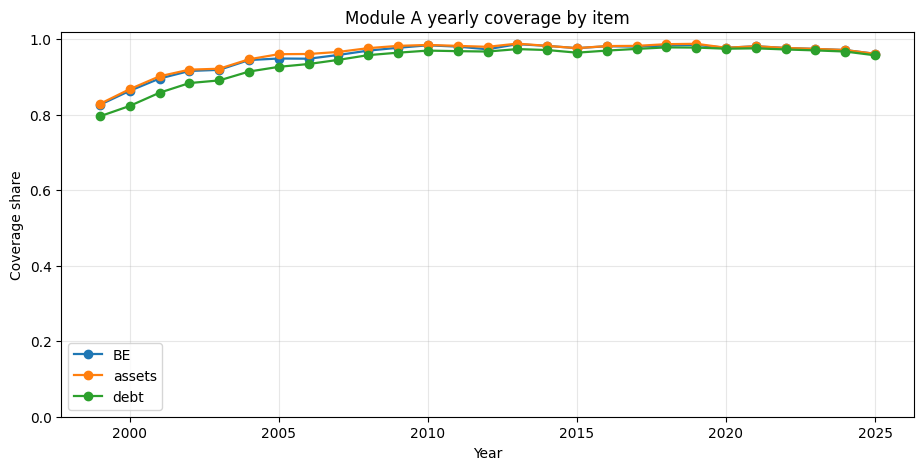

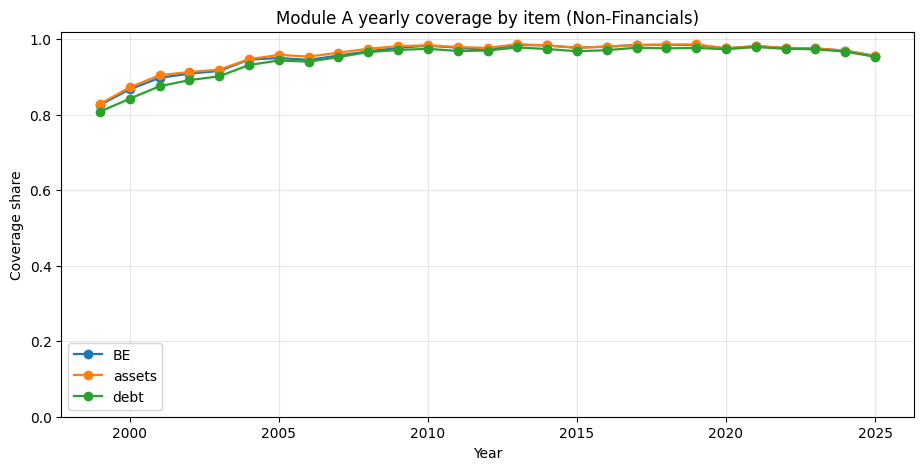

In [7]:

# Robust path resolution for Step 5B (works even after kernel restart)
MODULEA_OUTPUT_PATH = globals().get('OUTPUT_PATH', DATA_DIR / 'euro500_netpayout.parquet')

if not MODULEA_OUTPUT_PATH.exists():
    raise FileNotFoundError(f'Missing file: {MODULEA_OUTPUT_PATH}')

m = pd.read_parquet(MODULEA_OUTPUT_PATH).copy()
for c in ['asof_date']:
    if c in m.columns:
        m[c] = pd.to_datetime(m[c], errors='coerce')

targets = [c for c in ['BE', 'assets', 'debt'] if c in m.columns]
if not targets:
    raise KeyError('No Module A columns found (expected BE/assets/debt). Run Step 5 first.')

for c in targets:
    m[c] = pd.to_numeric(m[c], errors='coerce')

if 'asof_date' in m.columns and m['asof_date'].notna().any():
    m['year'] = m['asof_date'].dt.year
else:
    m['year'] = pd.NA

m['all3_available'] = m[targets].notna().all(axis=1)

# Overall coverage
overall = {'rows_total': len(m)}
for c in targets:
    overall[f'cov_{c}'] = float(m[c].notna().mean()) if len(m) else np.nan
overall['cov_all3'] = float(m['all3_available'].mean()) if len(m) else np.nan

display(pd.DataFrame([overall]))

# Year coverage plot (all three items)
if m['year'].notna().any():
    y = m.groupby('year', as_index=False).agg(rows=('year', 'size'))
    for c in targets:
        y[f'cov_{c}'] = m.groupby('year')[c].apply(lambda s: s.notna().mean()).values
    y['cov_all3'] = m.groupby('year')['all3_available'].apply(lambda s: float(s.mean())).values

    plt.figure(figsize=(11, 5))
    for c in targets:
        plt.plot(y['year'], y[f'cov_{c}'], marker='o', linewidth=1.6, label=c)
    plt.title('Module A yearly coverage by item')
    plt.xlabel('Year')
    plt.ylabel('Coverage share')
    plt.ylim(0, 1.02)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


    # Zusatzplot: Module A coverage (Non-Financials only)
    if 'trbc_sector' in m.columns:
        m_nf = m[m['trbc_sector'].astype(str).str.strip().str.lower() != 'financials'].copy()
        if m_nf['year'].notna().any() and not m_nf.empty:
            y_nf = m_nf.groupby('year', as_index=False).agg(rows=('year', 'size'))
            for c in targets:
                y_nf[f'cov_{c}'] = m_nf.groupby('year')[c].apply(lambda s: s.notna().mean()).values
            y_nf['cov_all3'] = m_nf.groupby('year')['all3_available'].apply(lambda s: float(s.mean())).values

            plt.figure(figsize=(11, 5))
            for c in targets:
                plt.plot(y_nf['year'], y_nf[f'cov_{c}'], marker='o', linewidth=1.6, label=c)
            plt.title('Module A yearly coverage by item (Non-Financials)')
            plt.xlabel('Year')
            plt.ylabel('Coverage share')
            plt.ylim(0, 1.02)
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()
        else:
            print('No valid Non-Financials rows/year information for Module A coverage plot.')
    else:
        print('Column trbc_sector missing; skipping Module A Non-Financials coverage plot.')
else:
    print('No valid year information available for yearly coverage plot.')



## 6. Modul B: Annual Income Statement (FY)

Geladene Targets:
- `Sales`
- `NetIncome`
- `GrossProfit`

Verwendete LSEG-Items:
- `TR.F.TotRevenue`
- `TR.F.NetIncAfterTax`
- `TR.F.CogsTot`

Pull-Logik:
- Fallback-ID-Kette: `ISIN -> RIC_current -> RIC`
- Cache je `firm_id` und Kandidat-ID
- Nur fehlende Zeitsegmente werden nachgezogen
- As-of-Mapping via `merge_asof` (backward, mit Toleranzfenster)


In [8]:
# ------------------------------------------------------------
# Step 6 — Module B: Income Statement (FY): Sales, NetIncome, GrossProfit + beta
#   Input  : euro500.parquet
#   Output : euro500_income_statement.parquet
# ------------------------------------------------------------

# -------------------------
# Config
# -------------------------
BASE_PATH = DATA_DIR / 'euro500.parquet'
OUTPUT_PATH_COMBINED = DATA_DIR / 'euro500_netpayout.parquet'

CACHE_DIR_B = DATA_DIR / 'moduleB_cache_by_company_id'
CACHE_DIR_B.mkdir(parents=True, exist_ok=True)
BAD_LOG_PATH_B = DATA_DIR / 'moduleB_bad_ids.csv'
STEP6_ROWS_PATH = DATA_DIR / 'moduleB_step6_rows.parquet'
STEP6_CKPT_PATH = DATA_DIR / 'moduleB_step6_checkpoint.json'


TARGET_FIELDS_B = {
    'Sales': 'TR.F.TotRevenue(Period=FY0)',
    'NetIncome': 'TR.F.NetIncAfterTax(Period=FY0)',
    'GrossProfit': 'TR.F.GrossProfIndPropTot(Period=FY0)',
    'Cogs': 'TR.F.COGSTot(Period=FY0)',
}
TARGET_COLS_B = list(TARGET_FIELDS_B.keys())
REQUIRED_COLS_B = ['Sales', 'NetIncome', 'GrossProfit']

ASOF_TOL_DAYS_B = 365
MAX_RETRIES_B = 2
BASE_SLEEP_B = 1.0
FORCE_REFRESH_B = False
CACHE_ONLY_B = False  # False => allow LSEG pull (cache still used)
CACHE_VERSION_B = 'v1'

BATCH_SIZE_B = 100
BATCH_PAUSE_SEC_B = 0
MULTI_UNIVERSE_CHUNK_B = 25

RATE_LIMIT_EVENTS_B = 0
LAST_GETDATA_ERR_MSG_B = ''
DEBUG_VERBOSE_B = False

# LSEG request governor (Step-5 style)
MIN_CALL_INTERVAL_SEC_B = 0.7
RATE_LIMIT_COOLDOWN_SEC_B = 5.0    # wait 5s on first 429 (was 3s)
RATE_LIMIT_MULTIPLIER_B = 2.0      # double each retry (was 1.5)
RATE_LIMIT_HARD_PAUSE_SEC_B = 30.0 # hard pause after repeated 429s (was 10s)
RATE_LIMIT_STREAK_TRIGGER_B = 2
FAIL_FAST_ON_RATE_LIMIT_B = False  # allow retry with cooldown (429 should not abort)
LAST_CALL_TS_B = 0.0
GLOBAL_COOLDOWN_UNTIL_B = 0.0
RATE_LIMIT_STREAK_B = 0

if not BASE_PATH.exists():
    raise FileNotFoundError(f'Missing file: {BASE_PATH}')


# -------------------------
# Helpers
# -------------------------
def _b_clean_str(s: pd.Series) -> pd.Series:
    x = s.astype('string').str.strip()
    return x.where(x.notna() & (x != ''), pd.NA)


def _b_resolve_asof(df: pd.DataFrame) -> pd.Series:
    if 'asof_date' in df.columns:
        return pd.to_datetime(df['asof_date'], errors='coerce').dt.normalize()
    if 'date' in df.columns:
        return pd.to_datetime(df['date'], errors='coerce').dt.normalize()
    if 'formation_date' in df.columns:
        return pd.to_datetime(df['formation_date'], errors='coerce').dt.normalize()
    if 'effective_date' in df.columns:
        return pd.to_datetime(df['effective_date'], errors='coerce').dt.normalize()
    raise ValueError('No usable as-of column found (asof_date/date/formation_date/effective_date).')


def _b_flatten_cols(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    if isinstance(x.columns, pd.MultiIndex):
        x.columns = [' | '.join([str(v) for v in tup if v is not None]).strip() for tup in x.columns]
    else:
        x.columns = [str(c).strip() for c in x.columns]
    return x


def _b_build_company_candidates(company_req: pd.DataFrame) -> list[tuple[str, str]]:
    """Collect all unique identifiers for one company across time."""
    q = company_req.copy().sort_values('asof_date')

    out = []
    seen = set()

    def _norm_isin(value):
        if pd.isna(value):
            return ''
        v = str(value).strip()
        if not v:
            return ''
        if v.upper().startswith('ISIN:'):
            v = v.split(':', 1)[1].strip()
        return v

    def _add(id_type: str, value):
        if pd.isna(value):
            return
        v = str(value).strip()
        if not v:
            return
        key = (id_type, v)
        if key in seen:
            return
        seen.add(key)
        out.append(key)

    if 'ISIN' in q.columns:
        for val in q['ISIN']:
            isin = _norm_isin(val)
            if isin:
                _add('ISIN', isin)

    if 'RIC_current' in q.columns:
        for val in q['RIC_current']:
            _add('RIC', val)

    if 'RIC' in q.columns:
        for val in q['RIC']:
            _add('RIC', val)

    if 'pull_id' in q.columns and 'id_type' in q.columns:
        for id_type, pull_id in zip(q['id_type'], q['pull_id']):
            it = str(id_type).upper().strip() if pd.notna(id_type) else ''
            if it == 'ISIN':
                isin = _norm_isin(pull_id)
                if isin:
                    _add('ISIN', isin)
            elif it == 'RIC':
                _add('RIC', pull_id)

    return out


def _b_cache_file(firm_id: str, id_type: str, pull_id: str) -> Path:
    raw = f'{firm_id}|{id_type}|{pull_id}'
    h = hashlib.sha1(raw.encode('utf-8')).hexdigest()[:12]
    clean = re.sub(r'[^A-Za-z0-9._-]', '_', firm_id)
    preferred = CACHE_DIR_B / f"{clean[:70]}__{id_type}_{h}__{CACHE_VERSION_B}.parquet"
    if preferred.exists():
        return preferred

    matches = sorted(CACHE_DIR_B.glob(f"*__{id_type}_{h}__{CACHE_VERSION_B}.parquet"))
    if matches:
        return matches[0]

    legacy = sorted(CACHE_DIR_B.glob(f"*__{id_type}_{h}.parquet"))
    if legacy:
        return legacy[0]

    return preferred


def _b_load_cache(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS_B)
    d = pd.read_parquet(path).copy()
    d = _b_flatten_cols(d)
    if 'asof_date' in d.columns:
        d['asof_date'] = pd.to_datetime(d['asof_date'], errors='coerce').dt.normalize()
    else:
        d['asof_date'] = pd.NaT

    for c in TARGET_COLS_B:
        if c not in d.columns:
            d[c] = np.nan
        d[c] = pd.to_numeric(d[c], errors='coerce')

    d = d.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return d[['asof_date'] + TARGET_COLS_B]


def _b_save_cache(path: Path, d: pd.DataFrame) -> None:
    tmp = path.with_suffix(path.suffix + '.tmp')
    out = d.copy()
    out['asof_date'] = pd.to_datetime(out['asof_date'], errors='coerce').dt.normalize()
    for c in TARGET_COLS_B:
        if c not in out.columns:
            out[c] = np.nan
        out[c] = pd.to_numeric(out[c], errors='coerce')
    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    out.to_parquet(tmp, index=False)
    tmp.replace(path)


def _b_cache_covers_range(cached: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp) -> bool:
    if cached is None or cached.empty:
        return False
    cmin = cached['asof_date'].min()
    cmax = cached['asof_date'].max()
    if pd.isna(cmin) or pd.isna(cmax):
        return False

    has_any_cached_value = bool(cached[REQUIRED_COLS_B].notna().any().any())
    if not has_any_cached_value:
        return False

    return bool((cmin <= start) and (cmax >= end))


def _b_combine(parts: list[pd.DataFrame]) -> pd.DataFrame:
    recs = []
    for part in parts:
        if part is None or len(part) == 0:
            continue
        g = _b_flatten_cols(part.copy())
        for c in ['asof_date'] + TARGET_COLS_B:
            if c not in g.columns:
                g[c] = np.nan
        g['asof_date'] = pd.to_datetime(g['asof_date'], errors='coerce').dt.normalize()
        for c in TARGET_COLS_B:
            g[c] = pd.to_numeric(g[c], errors='coerce')
        g = g[['asof_date'] + TARGET_COLS_B]
        recs.extend(g.to_dict('records'))

    if not recs:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS_B)

    out = pd.DataFrame.from_records(recs, columns=['asof_date'] + TARGET_COLS_B)
    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return out


def _b_extract_targets_history(raw: pd.DataFrame) -> pd.DataFrame:
    if raw is None or len(raw) == 0:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS_B)

    x = _b_flatten_cols(pd.DataFrame(raw).copy().reset_index())
    if x.empty:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS_B)

    date_col = None
    for c in x.columns:
        uc = str(c).upper()
        if 'PERIOD' in uc and 'DATE' in uc:
            date_col = c
            break
    if date_col is None:
        for c in x.columns:
            if 'date' in str(c).lower():
                date_col = c
                break
    if date_col is None:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS_B)

    out = pd.DataFrame({'asof_date': pd.to_datetime(x[date_col], errors='coerce').dt.normalize()})

    def _norm(txt: str) -> str:
        return re.sub(r'[^A-Z0-9]', '', str(txt).upper())

    def _field_token(field_expr: str) -> str:
        m = re.search(r'TR\.F\.([A-Z0-9_]+)', str(field_expr), flags=re.IGNORECASE)
        return _norm(m.group(1)) if m else _norm(field_expr)

    fallback_tokens = {
        'Sales': ['TOTREVENUE', 'REVENUE', 'SALES'],
        'NetIncome': ['NETINCAFTERTAX', 'NETINCOME', 'NETPROFIT'],
        'GrossProfit': ['GROSSPROFINDPROPTOT', 'GROSSPROFIT'],
        'Cogs': ['COGSTOT', 'COGS', 'COSTOFGOODSSOLD'],
    }

    norm_cols = {c: _norm(c) for c in x.columns}

    for tgt, field_expr in TARGET_FIELDS_B.items():
        token = _field_token(field_expr)
        cand = None
        for c, cn in norm_cols.items():
            if token and (token in cn or cn in token):
                cand = c
                break
        if cand is None:
            for alt in fallback_tokens.get(tgt, []):
                alt_n = _norm(alt)
                for c, cn in norm_cols.items():
                    if alt_n and alt_n in cn:
                        cand = c
                        break
                if cand is not None:
                    break
        out[tgt] = pd.to_numeric(x[cand], errors='coerce') if cand is not None else np.nan

    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return out[['asof_date'] + TARGET_COLS_B]


def _b_govern_requests() -> None:
    global LAST_CALL_TS_B, GLOBAL_COOLDOWN_UNTIL_B
    now = time.time()
    if now < GLOBAL_COOLDOWN_UNTIL_B:
        wait = GLOBAL_COOLDOWN_UNTIL_B - now
        if wait > 0:
            time.sleep(wait)
    now = time.time()
    gap = now - LAST_CALL_TS_B
    if gap < MIN_CALL_INTERVAL_SEC_B:
        time.sleep(MIN_CALL_INTERVAL_SEC_B - gap)


def _b_call_get_data(universe: list[str], fields: list[str], params: dict, dbg_label: str) -> pd.DataFrame:
    global LAST_CALL_TS_B, GLOBAL_COOLDOWN_UNTIL_B, RATE_LIMIT_STREAK_B, RATE_LIMIT_EVENTS_B, LAST_GETDATA_ERR_MSG_B

    LAST_GETDATA_ERR_MSG_B = ''
    last_err = None
    raw = None
    for r in range(MAX_RETRIES_B):
        try:
            _b_govern_requests()
            raw = ld.get_data(universe=universe, fields=fields, parameters=params)
            LAST_CALL_TS_B = time.time()
            RATE_LIMIT_STREAK_B = 0
            LAST_GETDATA_ERR_MSG_B = ''
            break
        except Exception as e:
            LAST_CALL_TS_B = time.time()
            last_err = e
            LAST_GETDATA_ERR_MSG_B = str(e)
            msg = str(e)
            is_rate_limit = ('Too many requests' in msg) or ('429' in msg)
            if is_rate_limit:
                RATE_LIMIT_STREAK_B += 1
                RATE_LIMIT_EVENTS_B += 1
                cooldown = RATE_LIMIT_COOLDOWN_SEC_B * (RATE_LIMIT_MULTIPLIER_B ** r) + random.random()
                if RATE_LIMIT_STREAK_B >= RATE_LIMIT_STREAK_TRIGGER_B:
                    cooldown = max(cooldown, RATE_LIMIT_HARD_PAUSE_SEC_B)
                GLOBAL_COOLDOWN_UNTIL_B = max(GLOBAL_COOLDOWN_UNTIL_B, time.time() + cooldown)
                if DEBUG_VERBOSE_B:
                    print(
                        f'[DEBUG rate limit B] id={dbg_label} retry={r+1}/{MAX_RETRIES_B} '
                        f'streak={RATE_LIMIT_STREAK_B} cooldown={cooldown:.1f}s '
                        f'err={type(e).__name__}: {e}'
                    )
                if FAIL_FAST_ON_RATE_LIMIT_B:
                    break
                time.sleep(cooldown)
            else:
                RATE_LIMIT_STREAK_B = 0
                if DEBUG_VERBOSE_B:
                    print(f'[DEBUG get_data B error] id={dbg_label} retry={r+1}/{MAX_RETRIES_B} err={type(e).__name__}: {e}')
                time.sleep(BASE_SLEEP_B * (2 ** r) + random.random() * 0.3)

    if raw is None or len(raw) == 0:
        if last_err is not None:
            msg = str(last_err)
            if 'Unable to resolve all requested identifiers' not in msg:
                print(f'[WARN get_data B failed] id={dbg_label}: {type(last_err).__name__}: {last_err}')
        elif DEBUG_VERBOSE_B:
            print(f'[DEBUG empty raw B no exception] id={dbg_label}')
        return pd.DataFrame()

    return pd.DataFrame(raw)


def _b_pull_targets_multi_segment(pull_ids: list[str], start: pd.Timestamp, end: pd.Timestamp) -> dict[str, pd.DataFrame]:
    if not pull_ids or pd.isna(start) or pd.isna(end) or start > end:
        return {}

    uniq = []
    seen = set()
    for pid in pull_ids:
        v = str(pid).strip()
        if not v:
            continue
        k = v.upper()
        if k in seen:
            continue
        seen.add(k)
        uniq.append(v)

    if not uniq:
        return {}

    params = {
        'SDate': start.strftime('%Y-%m-%d'),
        'EDate': end.strftime('%Y-%m-%d'),
        'Frq': 'FY',
    }
    fields = ['TR.F.PeriodEndDate(Period=FY0)'] + list(TARGET_FIELDS_B.values())

    out = {pid: pd.DataFrame(columns=['asof_date'] + TARGET_COLS_B) for pid in uniq}

    def _assign_from_raw(ids: list[str], raw_df: pd.DataFrame) -> None:
        if raw_df is None or raw_df.empty:
            return
        x = _b_flatten_cols(raw_df)
        if x.empty:
            return

        inst_col = None
        for c in x.columns:
            cl = c.lower()
            if 'instrument' in cl or cl in {'ric', 'isin'}:
                inst_col = c
                break

        if inst_col is None:
            # No instrument column — attribute whole frame to the single identifier.
            if len(ids) == 1:
                hist = _b_extract_targets_history(x)
                if not hist.empty:
                    out[ids[0]] = _b_combine([out[ids[0]], hist])
            return

        inst_norm = x[inst_col].astype('string').str.strip().str.upper()
        for pid in ids:
            pnorm = str(pid).strip().upper()
            g = x.loc[inst_norm == pnorm].copy()
            if g.empty:
                # Some providers return decorated instruments (e.g. LSEG strips ISIN: prefix).
                g = x.loc[inst_norm.str.contains(re.escape(pnorm), regex=True, na=False)].copy()
            if g.empty:
                # If single-id chunk and instrument mismatch, still use full frame.
                if len(ids) == 1:
                    g = x.copy()
                else:
                    continue
            hist = _b_extract_targets_history(g)
            if not hist.empty:
                out[pid] = _b_combine([out[pid], hist])

    def _periodend_collect_error(msg: str) -> bool:
        m = (msg or '').lower()
        return ('unable to collect data for the field' in m) and ('periodenddate' in m)

    def _fetch_ids(ids: list[str]) -> None:
        if not ids:
            return
        label = f'multiB[{len(ids)}]:' + ','.join(ids[:3])
        raw_df = _b_call_get_data(universe=ids, fields=fields, params=params, dbg_label=label)

        if raw_df.empty:
            err = LAST_GETDATA_ERR_MSG_B
            # Same strategy as Step 5: split poisoned multi requests recursively.
            if len(ids) > 1 and _periodend_collect_error(err):
                mid = len(ids) // 2
                _fetch_ids(ids[:mid])
                _fetch_ids(ids[mid:])
            return

        _assign_from_raw(ids, raw_df)

    for i in range(0, len(uniq), MULTI_UNIVERSE_CHUNK_B):
        chunk = uniq[i:i + MULTI_UNIVERSE_CHUNK_B]
        _fetch_ids(chunk)

    return out


def _b_update_company_cache(firm_id: str, id_type: str, pull_id: str, start: pd.Timestamp, end: pd.Timestamp, force_refresh: bool = False) -> pd.DataFrame:
    path = _b_cache_file(firm_id, id_type, pull_id)
    cached = pd.DataFrame(columns=['asof_date'] + TARGET_COLS_B) if force_refresh else _b_load_cache(path)

    if _b_cache_covers_range(cached, start, end) and (not force_refresh):
        return cached

    if CACHE_ONLY_B:
        return cached

    pulled = _b_pull_targets_multi_segment([pull_id], start, end).get(pull_id, pd.DataFrame(columns=['asof_date'] + TARGET_COLS_B))
    combined = _b_combine([cached, pulled])
    if not combined.empty or force_refresh:
        _b_save_cache(path, combined)
    return _b_load_cache(path)


def _b_map_to_asof(req_dates: pd.Series, hist: pd.DataFrame, tol_days: int) -> pd.DataFrame:
    left = pd.DataFrame({'asof_date': pd.to_datetime(req_dates, errors='coerce').dt.normalize()}).dropna().sort_values('asof_date')
    if left.empty:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS_B)

    if hist is None or hist.empty:
        for c in TARGET_COLS_B:
            left[c] = np.nan
        return left

    right = hist[['asof_date'] + TARGET_COLS_B].copy().sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    out = pd.merge_asof(
        left,
        right,
        on='asof_date',
        direction='backward',
        tolerance=pd.Timedelta(days=tol_days),
    )
    return out



# -------------------------
# Build request table (company x asof) + dynamic fallback candidates
# -------------------------
base = pd.read_parquet(BASE_PATH).copy()
if 'asof_date' not in base.columns:
    base['asof_date'] = _b_resolve_asof(base)
else:
    base['asof_date'] = pd.to_datetime(base['asof_date'], errors='coerce').dt.normalize()

for c in ['firm_id', 'ISIN', 'RIC_current', 'RIC', 'pull_id', 'id_type', 'firm_id']:
    if c in base.columns:
        base[c] = _b_clean_str(base[c])

if 'id_type' not in base.columns:
    base['id_type'] = np.select(
        [base.get('ISIN', pd.Series(pd.NA, index=base.index)).notna(),
         base.get('RIC_current', pd.Series(pd.NA, index=base.index)).notna(),
         base.get('RIC', pd.Series(pd.NA, index=base.index)).notna()],
        ['ISIN', 'RIC', 'RIC'],
        default=pd.NA,
    )
if 'pull_id' not in base.columns:
    base['pull_id'] = np.select(
        [base.get('ISIN', pd.Series(pd.NA, index=base.index)).notna(),
         base.get('RIC_current', pd.Series(pd.NA, index=base.index)).notna(),
         base.get('RIC', pd.Series(pd.NA, index=base.index)).notna()],
        [base.get('ISIN', pd.Series(pd.NA, index=base.index)),
         base.get('RIC_current', pd.Series(pd.NA, index=base.index)),
         base.get('RIC', pd.Series(pd.NA, index=base.index))],
        default=pd.NA,
    )
if 'firm_id' not in base.columns:
    base['firm_id'] = _b_clean_str(base['id_type']).astype('string') + ':' + _b_clean_str(base['pull_id']).astype('string')
    base.loc[base['pull_id'].isna(), 'firm_id'] = pd.NA

req_cols_b = [c for c in ['firm_id', 'asof_date', 'ISIN', 'RIC_current', 'RIC', 'id_type', 'pull_id'] if c in base.columns]
req_b = (
    base[req_cols_b]
    .dropna(subset=['firm_id', 'asof_date'])
    .drop_duplicates(['firm_id', 'asof_date'], keep='last')
    .reset_index(drop=True)
)
if req_b.empty:
    raise ValueError('No valid (firm_id, asof_date) rows found for Step 6.')

company_candidates_map_b = {}
for ck, g in req_b.groupby('firm_id', sort=False):
    company_candidates_map_b[str(ck)] = _b_build_company_candidates(g)

req_b['n_id_candidates'] = req_b['firm_id'].astype(str).map(lambda ck: len(company_candidates_map_b.get(ck, [])))

print('Step 6 request rows (company x asof):', len(req_b))
print('As-of range:', req_b['asof_date'].min(), 'to', req_b['asof_date'].max())
print('Unique companies:', req_b['firm_id'].nunique())
print('Active LSEG fields:', TARGET_FIELDS_B)
print('Mode:', 'CACHE_ONLY' if CACHE_ONLY_B else 'CACHE+NETWORK')
print('ID fallback order (historical per firm): all ISINs -> all RIC_current -> all RIC (+ pull_id/id_type history)')

# -------------------------
# Pull loop (batched + resume)
# -------------------------
companies_all_b = req_b['firm_id'].dropna().unique().tolist()
N_total_b = len(companies_all_b)

existing_step_rows_b = pd.DataFrame(columns=['firm_id', 'asof_date'] + TARGET_COLS_B)
if STEP6_ROWS_PATH.exists():
    try:
        existing_step_rows_b = pd.read_parquet(STEP6_ROWS_PATH)
        if 'asof_date' in existing_step_rows_b.columns:
            existing_step_rows_b['asof_date'] = pd.to_datetime(existing_step_rows_b['asof_date'], errors='coerce').dt.normalize()
        for c in TARGET_COLS_B:
            if c not in existing_step_rows_b.columns:
                existing_step_rows_b[c] = np.nan
            existing_step_rows_b[c] = pd.to_numeric(existing_step_rows_b[c], errors='coerce')
        existing_step_rows_b = existing_step_rows_b[['firm_id', 'asof_date'] + TARGET_COLS_B].dropna(subset=['firm_id', 'asof_date'])
        existing_step_rows_b = existing_step_rows_b.drop_duplicates(['firm_id', 'asof_date'], keep='last')
    except Exception as e:
        print(f'Warning: failed to read STEP6 rows cache, continuing empty: {e}')
        existing_step_rows_b = pd.DataFrame(columns=['firm_id', 'asof_date'] + TARGET_COLS_B)

processed_from_rows_b = set(existing_step_rows_b['firm_id'].dropna().astype(str).unique().tolist()) if not existing_step_rows_b.empty else set()
processed_from_ckpt_b = set()
if STEP6_CKPT_PATH.exists():
    try:
        ck = json.loads(STEP6_CKPT_PATH.read_text())
        processed_from_ckpt_b = set(str(x) for x in ck.get('processed_companies', []) if str(x).strip())
    except Exception as e:
        print(f'Warning: failed to read checkpoint, ignoring: {e}')

cache_file_count_b = len(list(CACHE_DIR_B.glob('*.parquet')))
if cache_file_count_b == 0 and (processed_from_rows_b or processed_from_ckpt_b):
    print('Step6: cache directory is empty -> ignoring step rows/checkpoint and starting full rebuild.')
    processed_from_rows_b = set()
    processed_from_ckpt_b = set()

processed_companies_b = set(processed_from_rows_b) | set(processed_from_ckpt_b)
companies_b = [c for c in companies_all_b if str(c) not in processed_companies_b]
N_b = len(companies_b)

cache_firm_ids_b = set()
for _p in CACHE_DIR_B.glob('*.parquet'):
    _name = _p.name
    if '__' in _name:
        cache_firm_ids_b.add(_name.split('__', 1)[0])
print('Resume info: total_companies=', N_total_b, 'already_processed=', len(processed_companies_b), 'remaining=', N_b, 'cache_files=', cache_file_count_b, 'cache_firms=', len(cache_firm_ids_b))

run_t0_b = time.time()
new_rows_out_b = []
bad_rows_b = []

total_cand_calls_b = 0
total_all3_resolved_b = 0
total_not_all3_b = 0
total_item_found_b = {c: 0 for c in REQUIRED_COLS_B}

if not CACHE_ONLY_B:
    ld.open_session()
try:
    if N_b == 0:
        print('No remaining companies to pull in Step 6.')

    n_batches_b = int(np.ceil(N_b / BATCH_SIZE_B)) if N_b > 0 else 0
    for b_ix, b_start in enumerate(range(0, N_b, BATCH_SIZE_B), start=1):
        b_end = min(N_b, b_start + BATCH_SIZE_B)
        batch_companies = companies_b[b_start:b_end]
        batch_t0 = time.time()
        batch_new_rows = []
        batch_processed = []

        print(f'[BATCH {b_ix}/{n_batches_b}] companies={len(batch_companies)} idx={b_start+1}-{b_end}')

        for k, firm_id in enumerate(batch_companies, start=1):
            q = req_b[req_b['firm_id'] == firm_id].copy().sort_values('asof_date')
            dates = q['asof_date'].dropna().drop_duplicates().sort_values().reset_index(drop=True)
            if dates.empty:
                continue

            start = pd.to_datetime(dates.min()).normalize()
            end = pd.to_datetime(dates.max()).normalize()

            panel = pd.DataFrame({'asof_date': dates})
            for c in TARGET_COLS_B:
                panel[c] = np.nan

            cands = company_candidates_map_b.get(str(firm_id), [])
            cand_used = 0
            attempted_ids = []

            for cand in cands:
                if panel[REQUIRED_COLS_B].notna().all(axis=1).all():
                    break
                if (not isinstance(cand, (list, tuple))) or len(cand) != 2:
                    continue

                id_type = str(cand[0]).upper().strip()
                pull_id = str(cand[1]).strip()
                if not id_type or not pull_id:
                    continue

                cand_used += 1
                total_cand_calls_b += 1
                attempted_ids.append(f'{id_type}:{pull_id}')

                cache_path = _b_cache_file(str(firm_id), id_type, pull_id)
                cached_pre = _b_load_cache(cache_path)
                if _b_cache_covers_range(cached_pre, start, end) and (not FORCE_REFRESH_B):
                    hist = cached_pre
                else:
                    hist = _b_update_company_cache(
                        firm_id=str(firm_id),
                        id_type=id_type,
                        pull_id=pull_id,
                        start=start,
                        end=end,
                        force_refresh=FORCE_REFRESH_B,
                    )
                mapped = _b_map_to_asof(panel['asof_date'], hist, tol_days=ASOF_TOL_DAYS_B)
                if mapped.empty:
                    continue

                for c in TARGET_COLS_B:
                    cur = pd.to_numeric(panel[c], errors='coerce')
                    nxt = pd.to_numeric(mapped.get(c, np.nan), errors='coerce')
                    panel[c] = cur.where(cur.notna(), nxt)

            # GrossProfit fallback: TotRevenue - Cogs
            sales_s = pd.to_numeric(panel['Sales'], errors='coerce')
            gp_s = pd.to_numeric(panel['GrossProfit'], errors='coerce')
            cogs_s = pd.to_numeric(panel['Cogs'], errors='coerce')
            panel['GrossProfit'] = gp_s.combine_first(sales_s - cogs_s)

            panel.insert(0, 'firm_id', firm_id)
            recs = panel[['firm_id', 'asof_date'] + TARGET_COLS_B].to_dict('records')
            new_rows_out_b.extend(recs)
            batch_new_rows.extend(recs)
            batch_processed.append(str(firm_id))

            all3_resolved = int(panel[REQUIRED_COLS_B].notna().all(axis=1).sum())
            not_all3 = int(len(panel) - all3_resolved)
            item_found = {c: int(panel[c].notna().sum()) for c in REQUIRED_COLS_B}
            total_all3_resolved_b += all3_resolved
            total_not_all3_b += not_all3
            for c in REQUIRED_COLS_B:
                total_item_found_b[c] += item_found[c]

            any_required_found = bool(panel[REQUIRED_COLS_B].notna().any().any())
            if (not any_required_found) and attempted_ids:
                print(
                    f'[WARN company identifiers unresolved] company={str(firm_id)[:40]} '
                    f'ids={attempted_ids[:4]}'
                )

            unresolved = panel[panel[REQUIRED_COLS_B].isna().any(axis=1)]
            if not unresolved.empty:
                bad_rows_b.extend(
                    unresolved[['firm_id', 'asof_date']]
                    .assign(reason='not_all3_resolved', n_candidates=int(len(cands)))
                    .to_dict('records')
                )

            elapsed = time.time() - run_t0_b
            print(
                f'[BATCH {b_ix}/{n_batches_b}] [{b_start+k}/{N_b}] company={str(firm_id)[:40]} rows={len(dates)} '
                f'cand_used={cand_used}/{len(cands)} all3_resolved={all3_resolved} not_all3={not_all3} '
                f'found_Sales={item_found.get("Sales",0)} found_NetIncome={item_found.get("NetIncome",0)} found_GrossProfit={item_found.get("GrossProfit",0)} '
                f'elapsed={elapsed/60:.1f}m'
            )

        # Persist batch rows for resume
        if batch_new_rows:
            batch_df = pd.DataFrame(batch_new_rows)
            batch_df['asof_date'] = pd.to_datetime(batch_df['asof_date'], errors='coerce').dt.normalize()
            for c in TARGET_COLS_B:
                batch_df[c] = pd.to_numeric(batch_df[c], errors='coerce')
            batch_df = batch_df.dropna(subset=['firm_id', 'asof_date'])

            if STEP6_ROWS_PATH.exists():
                prev = pd.read_parquet(STEP6_ROWS_PATH)
                if prev is None or prev.empty:
                    combined = batch_df.copy()
                else:
                    prev = prev.copy()
                    prev['asof_date'] = pd.to_datetime(prev.get('asof_date'), errors='coerce').dt.normalize()
                    for c in TARGET_COLS_B:
                        if c not in prev.columns:
                            prev[c] = np.nan
                        prev[c] = pd.to_numeric(prev[c], errors='coerce')
                    prev = prev[['firm_id', 'asof_date'] + TARGET_COLS_B].dropna(subset=['firm_id', 'asof_date'])
                    combined = pd.concat([prev, batch_df], ignore_index=True)
            else:
                combined = batch_df.copy()

            combined = combined.sort_values(['firm_id', 'asof_date']).drop_duplicates(['firm_id', 'asof_date'], keep='last')
            combined.to_parquet(STEP6_ROWS_PATH, index=False)

        # Persist checkpoint
        processed_companies_b.update(batch_processed)
        ckpt_payload = {
            'processed_companies': sorted(processed_companies_b),
            'last_batch': b_ix,
            'remaining_companies': max(0, N_total_b - len(processed_companies_b)),
            'updated_at_utc': pd.Timestamp.utcnow().isoformat(),
        }
        STEP6_CKPT_PATH.write_text(json.dumps(ckpt_payload, ensure_ascii=False, indent=2))

        batch_elapsed = (time.time() - batch_t0) / 60
        print(f'[BATCH {b_ix}/{n_batches_b} DONE] processed={len(batch_processed)} batch_elapsed={batch_elapsed:.1f}m')

        if b_end < N_b and BATCH_PAUSE_SEC_B > 0:
            print(f'[BATCH PAUSE] sleeping {BATCH_PAUSE_SEC_B:.0f}s before next batch...')
            time.sleep(BATCH_PAUSE_SEC_B)
finally:
    if not CACHE_ONLY_B:
        ld.close_session()

print(
    f'Done Step 6: total_companies={N_total_b}, run_remaining_start={N_b}, candidate_calls={total_cand_calls_b}, '
    f'all3_resolved_rows={total_all3_resolved_b}, not_all3_rows={total_not_all3_b}, '
    f'found_Sales={total_item_found_b.get("Sales",0)}, found_NetIncome={total_item_found_b.get("NetIncome",0)}, found_GrossProfit={total_item_found_b.get("GrossProfit",0)}'
)

rebuild_output_b = FORCE_REFRESH_B or (N_b > 0) or (not STEP6_ROWS_PATH.exists()) or (not OUTPUT_PATH_COMBINED.exists())
if (not rebuild_output_b) and BASE_PATH.exists() and OUTPUT_PATH_COMBINED.exists():
    rebuild_output_b = BASE_PATH.stat().st_mtime > OUTPUT_PATH_COMBINED.stat().st_mtime

# Force rebuild if combined output does not yet contain Module-B columns.
if (not rebuild_output_b) and OUTPUT_PATH_COMBINED.exists():
    try:
        chk = pd.read_parquet(OUTPUT_PATH_COMBINED)
        needed_b = {'Sales', 'NetIncome', 'GrossProfit'}
        if not needed_b.issubset(set(chk.columns)):
            rebuild_output_b = True
            print('Step 6 rebuild forced: combined output missing Module-B columns.')
    except Exception:
        rebuild_output_b = True
        print('Step 6 rebuild forced: unable to inspect combined output file.')

# -------------------------
# Build final output table
# -------------------------
if rebuild_output_b and STEP6_ROWS_PATH.exists():
    out_panel_b = pd.read_parquet(STEP6_ROWS_PATH)
else:
    out_panel_b = pd.DataFrame(new_rows_out_b)

if rebuild_output_b and out_panel_b.empty:
    out_panel_b = pd.DataFrame(columns=['firm_id', 'asof_date'] + TARGET_COLS_B)
elif rebuild_output_b:
    out_panel_b['asof_date'] = pd.to_datetime(out_panel_b['asof_date'], errors='coerce').dt.normalize()
    for c in TARGET_COLS_B:
        if c not in out_panel_b.columns:
            out_panel_b[c] = np.nan
        out_panel_b[c] = pd.to_numeric(out_panel_b[c], errors='coerce')

    # Recompute fallback after resume load
    out_panel_b['GrossProfit'] = pd.to_numeric(out_panel_b['GrossProfit'], errors='coerce').combine_first(
        pd.to_numeric(out_panel_b['Sales'], errors='coerce') - pd.to_numeric(out_panel_b['Cogs'], errors='coerce')
    )

    out_panel_b = out_panel_b[['firm_id', 'asof_date'] + TARGET_COLS_B]
    out_panel_b = out_panel_b.sort_values(['firm_id', 'asof_date']).drop_duplicates(['firm_id', 'asof_date'], keep='last')

if 'base' not in locals():
    base = pd.read_parquet(BASE_PATH).copy()
    if 'asof_date' not in base.columns:
        base['asof_date'] = _b_resolve_asof(base)
    else:
        base['asof_date'] = pd.to_datetime(base['asof_date'], errors='coerce').dt.normalize()

if rebuild_output_b:
    # Stage 1: preferred merge on firm_id + asof_date
    if 'firm_id' in base.columns:
        out_panel_b_firm = out_panel_b.rename(columns={'firm_id': 'firm_id'})
        out_b = base.merge(out_panel_b_firm, on=['firm_id', 'asof_date'], how='left', suffixes=('', '_firm'))
    else:
        out_b = base.copy()

    # Stage 2 fallback: merge on firm_id + asof_date
    add_b = base.merge(out_panel_b, on=['firm_id', 'asof_date'], how='left', suffixes=('', '_key'))

    for c in TARGET_COLS_B:
        old_s = pd.to_numeric(out_b[c], errors='coerce') if c in out_b.columns else pd.Series(np.nan, index=out_b.index)
        new_firm_s = pd.to_numeric(out_b[f'{c}_firm'] if f'{c}_firm' in out_b.columns else pd.Series(np.nan, index=out_b.index), errors='coerce')
        new_key_s = pd.to_numeric(add_b[f'{c}_key'] if f'{c}_key' in add_b.columns else pd.Series(np.nan, index=out_b.index), errors='coerce')
        out_b[c] = new_firm_s.combine_first(new_key_s).combine_first(old_s)
        if f'{c}_firm' in out_b.columns:
            out_b = out_b.drop(columns=[f'{c}_firm'])

    # Ensure fallback in final output
    out_b['GrossProfit'] = pd.to_numeric(out_b['GrossProfit'], errors='coerce').combine_first(
        pd.to_numeric(out_b['Sales'], errors='coerce') - pd.to_numeric(out_b['Cogs'], errors='coerce')
    )


    # Keep requested outputs + beta; Cogs stays internal only
    if 'Cogs' in out_b.columns:
        out_b = out_b.drop(columns=['Cogs'])

    # Bring Module-A fields into the combined table (if Step 5 already produced them).
    moduleA_cols = []
    if OUTPUT_PATH_COMBINED.exists():
        modA_all = pd.read_parquet(OUTPUT_PATH_COMBINED).copy()
        moduleA_cols = [c for c in ['BE', 'assets', 'debt'] if c in modA_all.columns]

        if moduleA_cols:
            if 'asof_date' in modA_all.columns:
                modA_all['asof_date'] = pd.to_datetime(modA_all['asof_date'], errors='coerce').dt.normalize()
            else:
                modA_all['asof_date'] = _b_resolve_asof(modA_all)

            modA = modA_all[['firm_id', 'asof_date'] + moduleA_cols].dropna(subset=['firm_id', 'asof_date'])
            modA = modA.drop_duplicates(['firm_id', 'asof_date'], keep='last')
            out_b = out_b.merge(modA, on=['firm_id', 'asof_date'], how='left', suffixes=('', '_modA'))

            for c in moduleA_cols:
                if f'{c}_modA' in out_b.columns:
                    cur = pd.to_numeric(out_b[c], errors='coerce') if c in out_b.columns else pd.Series(np.nan, index=out_b.index)
                    old = pd.to_numeric(out_b[f'{c}_modA'], errors='coerce')
                    out_b[c] = cur.combine_first(old)
                    out_b = out_b.drop(columns=[f'{c}_modA'])

    out_b.to_parquet(OUTPUT_PATH_COMBINED, index=False)
    euro500_netpayout_df = out_b.copy()

    print('Saved combined output (Step 5 + 6):', OUTPUT_PATH_COMBINED, 'rows:', len(out_b))
    print('Data Wrangler variable ready: euro500_netpayout_df')
else:
    out_b = pd.read_parquet(OUTPUT_PATH_COMBINED)
    euro500_netpayout_df = out_b.copy()
    print('Skipped Step-6 rebuild (already up-to-date):', OUTPUT_PATH_COMBINED, 'rows:', len(out_b))
    print('Data Wrangler variable ready: euro500_netpayout_df')

if bad_rows_b:
    bad_df = pd.DataFrame(bad_rows_b)
    if BAD_LOG_PATH_B.exists():
        old = pd.read_csv(BAD_LOG_PATH_B)
        for c in ['firm_id', 'asof_date', 'reason', 'n_candidates']:
            if c not in old.columns:
                old[c] = pd.NA
            if c not in bad_df.columns:
                bad_df[c] = pd.NA
        out_bad = pd.DataFrame.from_records(
            old[['firm_id', 'asof_date', 'reason', 'n_candidates']].to_dict('records')
            + bad_df[['firm_id', 'asof_date', 'reason', 'n_candidates']].to_dict('records'),
            columns=['firm_id', 'asof_date', 'reason', 'n_candidates'],
        )
    else:
        out_bad = bad_df

    out_bad['asof_date'] = pd.to_datetime(out_bad['asof_date'], errors='coerce').dt.normalize()
    out_bad = out_bad.drop_duplicates(subset=['firm_id', 'asof_date', 'reason'], keep='last')
    out_bad.to_csv(BAD_LOG_PATH_B, index=False)
    print('Updated Module-B bad-id log:', BAD_LOG_PATH_B, 'rows:', len(out_bad))

Step 6 request rows (company x asof): 54000
As-of range: 1999-03-31 00:00:00 to 2025-12-31 00:00:00
Unique companies: 1166
Active LSEG fields: {'Sales': 'TR.F.TotRevenue(Period=FY0)', 'NetIncome': 'TR.F.NetIncAfterTax(Period=FY0)', 'GrossProfit': 'TR.F.GrossProfIndPropTot(Period=FY0)', 'Cogs': 'TR.F.COGSTot(Period=FY0)'}
Mode: CACHE+NETWORK
ID fallback order (historical per firm): all ISINs -> all RIC_current -> all RIC (+ pull_id/id_type history)
Resume info: total_companies= 1166 already_processed= 1166 remaining= 0 cache_files= 1866 cache_firms= 1020
No remaining companies to pull in Step 6.
Done Step 6: total_companies=1166, run_remaining_start=0, candidate_calls=0, all3_resolved_rows=0, not_all3_rows=0, found_Sales=0, found_NetIncome=0, found_GrossProfit=0
Step 6 rebuild forced: combined output missing Module-B columns.
Saved combined output (Step 5 + 6): /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_netpayout.parquet 

### 6B. Coverage-Analyse Modul B (`Sales`, `NetIncome`, `GrossProfit`)

Geprueft werden:
- Row-Coverage je Einzelvariable
- Coverage ueber `asof_year`
- Anteil der Zeilen mit allen drei Variablen gleichzeitig


,rows_total,cov_Sales,cov_NetIncome,cov_GrossProfit,cov_all3
0,54000,0.939519,0.9405,0.821481,0.820889


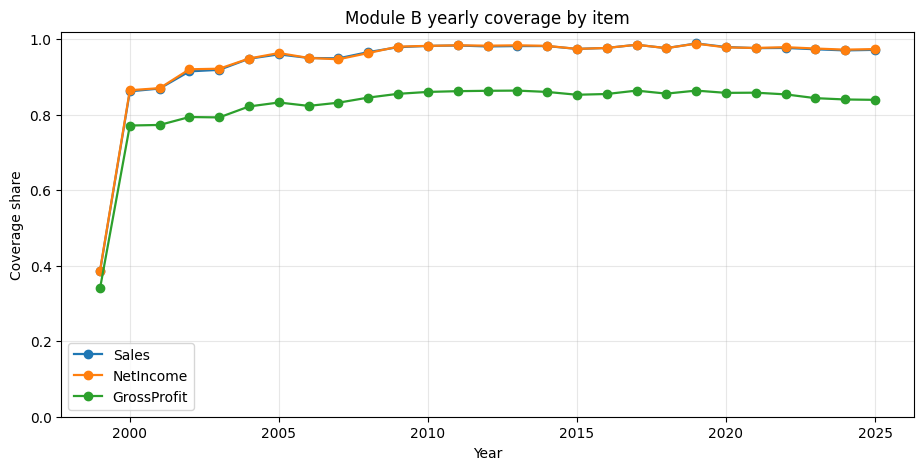

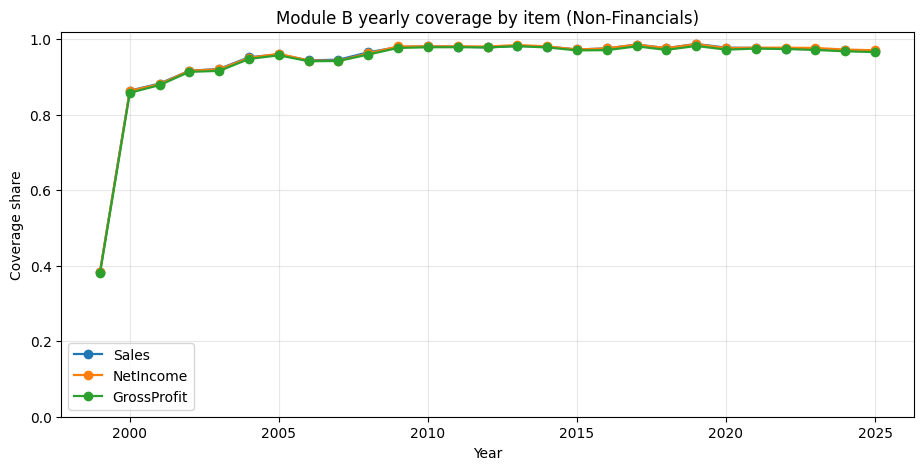

In [9]:
# Robust path resolution for Step 6B
MODULEB_OUTPUT_PATH = globals().get('OUTPUT_PATH_COMBINED', DATA_DIR / 'euro500_netpayout.parquet')

if not MODULEB_OUTPUT_PATH.exists():
    raise FileNotFoundError(f'Missing file: {MODULEB_OUTPUT_PATH}')

mb = pd.read_parquet(MODULEB_OUTPUT_PATH).copy()
if 'asof_date' in mb.columns:
    mb['asof_date'] = pd.to_datetime(mb['asof_date'], errors='coerce')

targets_b = [c for c in ['Sales', 'NetIncome', 'GrossProfit'] if c in mb.columns]
if not targets_b:
    raise KeyError('No Module B columns found (expected Sales/NetIncome/GrossProfit). Run Step 6 first.')

for c in targets_b:
    mb[c] = pd.to_numeric(mb[c], errors='coerce')

if 'asof_date' in mb.columns and mb['asof_date'].notna().any():
    mb['year'] = mb['asof_date'].dt.year
else:
    mb['year'] = pd.NA

mb['all3_available'] = mb[targets_b].notna().all(axis=1)

overall_b = {'rows_total': len(mb)}
for c in targets_b:
    overall_b[f'cov_{c}'] = float(mb[c].notna().mean()) if len(mb) else np.nan
overall_b['cov_all3'] = float(mb['all3_available'].mean()) if len(mb) else np.nan

display(pd.DataFrame([overall_b]))

if mb['year'].notna().any():
    yb = mb.groupby('year', as_index=False).agg(rows=('year', 'size'))
    for c in targets_b:
        yb[f'cov_{c}'] = mb.groupby('year')[c].apply(lambda s: s.notna().mean()).values
    yb['cov_all3'] = mb.groupby('year')['all3_available'].apply(lambda s: float(s.mean())).values

    plt.figure(figsize=(11, 5))
    for c in targets_b:
        plt.plot(yb['year'], yb[f'cov_{c}'], marker='o', linewidth=1.6, label=c)
    plt.title('Module B yearly coverage by item')
    plt.xlabel('Year')
    plt.ylabel('Coverage share')
    plt.ylim(0, 1.02)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


    # Zusatzplot: Module B coverage (Non-Financials only)
    if 'trbc_sector' in mb.columns:
        mb_nf = mb[mb['trbc_sector'].astype(str).str.strip().str.lower() != 'financials'].copy()
        if mb_nf['year'].notna().any() and not mb_nf.empty:
            yb_nf = mb_nf.groupby('year', as_index=False).agg(rows=('year', 'size'))
            for c in targets_b:
                yb_nf[f'cov_{c}'] = mb_nf.groupby('year')[c].apply(lambda s: s.notna().mean()).values
            yb_nf['cov_all3'] = mb_nf.groupby('year')['all3_available'].apply(lambda s: float(s.mean())).values

            plt.figure(figsize=(11, 5))
            for c in targets_b:
                plt.plot(yb_nf['year'], yb_nf[f'cov_{c}'], marker='o', linewidth=1.6, label=c)
            plt.title('Module B yearly coverage by item (Non-Financials)')
            plt.xlabel('Year')
            plt.ylabel('Coverage share')
            plt.ylim(0, 1.02)
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()
        else:
            print('No valid Non-Financials rows/year information for Module B coverage plot.')
    else:
        print('Column trbc_sector missing; skipping Module B Non-Financials coverage plot.')
else:
    print('No valid year information available for yearly coverage plot.')



## 7. Modul C: Annual Cashflow und Payouts (FY)

Geladene Targets:
- `Dividends` (cash paid)
- `Buybacks` (net)

Verwendete LSEG-Items:
- `TR.F.DivPaidCashTotCF`
- `TR.F.ComStockBuybackNet`

Pull-Logik:
- Fallback-ID-Kette: `ISIN -> RIC_current -> RIC`
- Cache je `firm_id` und Kandidat-ID
- Nur fehlende Zeitsegmente werden nachgezogen
- As-of-Mapping via `merge_asof` (backward, mit Toleranzfenster)


In [10]:
# ------------------------------------------------------------
# Step 7 — Module C: Cashflow / Payouts (FY): Dividends + Buybacks
#   Input  : euro500.parquet
#   Output : euro500_netpayout.parquet (combined table)
# ------------------------------------------------------------

# -------------------------
# Config
# -------------------------
BASE_PATH_E = DATA_DIR / 'euro500.parquet'
OUTPUT_PATH_COMBINED = DATA_DIR / 'euro500_netpayout.parquet'

CACHE_DIR_C = DATA_DIR / 'moduleC_cache_by_company_id'
CACHE_DIR_C.mkdir(parents=True, exist_ok=True)
BAD_LOG_PATH_C = DATA_DIR / 'moduleC_bad_ids.csv'
STEP7_ROWS_PATH = DATA_DIR / 'moduleC_step7_rows.parquet'
STEP7_CKPT_PATH = DATA_DIR / 'moduleC_step7_checkpoint.json'

TARGET_FIELDS_E = {
    'Dividends': 'TR.F.DivPaidCashTotCF(Period=FY0)',
    'Buybacks': 'TR.F.ComStockBuybackNet(Period=FY0)',
}
TARGET_COLS_E = list(TARGET_FIELDS_E.keys())
REQUIRED_COLS_E = ['Dividends', 'Buybacks']

ASOF_TOL_DAYS_E = 365
MAX_RETRIES_E = 2
BASE_SLEEP_E = 1.0
FORCE_REFRESH_E = False
CACHE_ONLY_E = False  # False => allow LSEG pull (cache still used)
CACHE_VERSION_E = 'v1'

BATCH_SIZE_E = 100
BATCH_PAUSE_SEC_E = 0
MULTI_UNIVERSE_CHUNK_E = 25


if not BASE_PATH_E.exists():
    raise FileNotFoundError(f'Missing file: {BASE_PATH_E}')


# -------------------------
# Helpers
# -------------------------
def _e_clean_str(s: pd.Series) -> pd.Series:
    x = s.astype('string').str.strip()
    return x.where(x.notna() & (x != ''), pd.NA)


def _e_resolve_asof(df: pd.DataFrame) -> pd.Series:
    if 'asof_date' in df.columns:
        return pd.to_datetime(df['asof_date'], errors='coerce').dt.normalize()
    if 'date' in df.columns:
        return pd.to_datetime(df['date'], errors='coerce').dt.normalize()
    if 'formation_date' in df.columns:
        return pd.to_datetime(df['formation_date'], errors='coerce').dt.normalize()
    if 'effective_date' in df.columns:
        return pd.to_datetime(df['effective_date'], errors='coerce').dt.normalize()
    raise ValueError('No usable as-of column found (asof_date/date/formation_date/effective_date).')


def _e_flatten_cols(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    if isinstance(x.columns, pd.MultiIndex):
        x.columns = [' | '.join([str(v) for v in tup if v is not None]).strip() for tup in x.columns]
    else:
        x.columns = [str(c).strip() for c in x.columns]
    return x


def _e_norm_isin(value) -> str | None:
    if pd.isna(value):
        return None
    v = str(value).strip()
    if not v:
        return None
    return v.split(':', 1)[1].strip() if v.upper().startswith('ISIN:') else v


def _e_build_company_candidates(company_req: pd.DataFrame) -> list[tuple[str, str]]:
    """Collect all unique identifiers for one company across time.

    Order: all ISINs, then all RIC_current, then all RIC (chronological first-seen).
    """
    q = company_req.copy().sort_values('asof_date')

    out = []
    seen = set()

    def _add(id_type: str, value):
        if pd.isna(value):
            return
        v = str(value).strip()
        if not v:
            return
        key = (id_type, v)
        if key in seen:
            return
        seen.add(key)
        out.append(key)

    # 1) all ISINs observed over time for this company
    if 'ISIN' in q.columns:
        for val in q['ISIN']:
            norm = _e_norm_isin(val)
            if norm:
                _add('ISIN', norm)
                _add('ISIN', f'ISIN:{norm}')

    # 2) all current RICs observed over time
    if 'RIC_current' in q.columns:
        for val in q['RIC_current']:
            _add('RIC', val)

    # 3) all legacy/raw RICs observed over time
    if 'RIC' in q.columns:
        for val in q['RIC']:
            _add('RIC', val)

    # Include pull_id history too (if present), without duplicating existing keys.
    if 'pull_id' in q.columns and 'id_type' in q.columns:
        for id_type, pull_id in zip(q['id_type'], q['pull_id']):
            it = str(id_type).upper().strip() if pd.notna(id_type) else ''
            if it == 'ISIN':
                norm = _e_norm_isin(pull_id)
                if norm:
                    _add('ISIN', norm)
                    _add('ISIN', f'ISIN:{norm}')
            elif it == 'RIC':
                _add('RIC', pull_id)

    return out


def _e_cache_file(firm_id: str, id_type: str, pull_id: str) -> Path:
    raw = f'{firm_id}|{id_type}|{pull_id}'
    h = hashlib.sha1(raw.encode('utf-8')).hexdigest()[:12]
    clean = re.sub(r'[^A-Za-z0-9._-]', '_', firm_id)
    preferred = CACHE_DIR_C / f"{clean[:70]}__{id_type}_{h}__{CACHE_VERSION_E}.parquet"
    if preferred.exists():
        return preferred

    matches = sorted(CACHE_DIR_C.glob(f"*__{id_type}_{h}__{CACHE_VERSION_E}.parquet"))
    if matches:
        return matches[0]

    legacy = sorted(CACHE_DIR_C.glob(f"*__{id_type}_{h}.parquet"))
    if legacy:
        return legacy[0]

    return preferred


def _e_load_cache(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS_E)
    d = pd.read_parquet(path).copy()
    d = _e_flatten_cols(d)
    if 'asof_date' in d.columns:
        d['asof_date'] = pd.to_datetime(d['asof_date'], errors='coerce').dt.normalize()
    else:
        d['asof_date'] = pd.NaT

    for c in TARGET_COLS_E:
        if c not in d.columns:
            d[c] = np.nan
        d[c] = pd.to_numeric(d[c], errors='coerce')

    d = d.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return d[['asof_date'] + TARGET_COLS_E]


def _e_save_cache(path: Path, d: pd.DataFrame) -> None:
    tmp = path.with_suffix(path.suffix + '.tmp')
    out = d.copy()
    out['asof_date'] = pd.to_datetime(out['asof_date'], errors='coerce').dt.normalize()
    for c in TARGET_COLS_E:
        if c not in out.columns:
            out[c] = np.nan
        out[c] = pd.to_numeric(out[c], errors='coerce')
    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    out.to_parquet(tmp, index=False)
    tmp.replace(path)


def _e_cache_covers_range(cached: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp) -> bool:
    if cached is None or cached.empty:
        return False
    cmin = cached['asof_date'].min()
    cmax = cached['asof_date'].max()
    if pd.isna(cmin) or pd.isna(cmax):
        return False

    has_any_cached_value = bool(cached[REQUIRED_COLS_E].notna().any().any())
    if not has_any_cached_value:
        return False

    return bool((cmin <= start) and (cmax >= end))


def _e_combine(parts: list[pd.DataFrame]) -> pd.DataFrame:
    recs = []
    for part in parts:
        if part is None or len(part) == 0:
            continue
        g = _e_flatten_cols(part.copy())
        for c in ['asof_date'] + TARGET_COLS_E:
            if c not in g.columns:
                g[c] = np.nan
        g['asof_date'] = pd.to_datetime(g['asof_date'], errors='coerce').dt.normalize()
        for c in TARGET_COLS_E:
            g[c] = pd.to_numeric(g[c], errors='coerce')
        g = g[['asof_date'] + TARGET_COLS_E]
        recs.extend(g.to_dict('records'))

    if not recs:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS_E)

    out = pd.DataFrame.from_records(recs, columns=['asof_date'] + TARGET_COLS_E)
    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return out


def _e_extract_targets_history(raw: pd.DataFrame) -> pd.DataFrame:
    if raw is None or len(raw) == 0:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS_E)

    x = _e_flatten_cols(pd.DataFrame(raw).copy().reset_index())
    if x.empty:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS_E)

    date_col = None
    for c in x.columns:
        uc = str(c).upper()
        if 'PERIOD' in uc and 'DATE' in uc:
            date_col = c
            break
    if date_col is None:
        for c in x.columns:
            if 'date' in str(c).lower():
                date_col = c
                break
    if date_col is None:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS_E)

    out = pd.DataFrame({'asof_date': pd.to_datetime(x[date_col], errors='coerce').dt.normalize()})

    def _norm(txt: str) -> str:
        return re.sub(r'[^A-Z0-9]', '', str(txt).upper())

    def _field_token(field_expr: str) -> str:
        m = re.search(r'TR\.F\.([A-Z0-9_]+)', str(field_expr), flags=re.IGNORECASE)
        return _norm(m.group(1)) if m else _norm(field_expr)

    fallback_tokens = {
        'Dividends': ['DIVPAIDCASHTOTCF', 'DIVIDENDS', 'DIVPAID'],
        'Buybacks': ['COMSTOCKBUYBACKNET', 'BUYBACK', 'REPURCHASE'],
    }

    norm_cols = {c: _norm(c) for c in x.columns}

    for tgt, field_expr in TARGET_FIELDS_E.items():
        token = _field_token(field_expr)
        cand = None
        for c, cn in norm_cols.items():
            if token and (token in cn or cn in token):
                cand = c
                break
        if cand is None:
            for alt in fallback_tokens.get(tgt, []):
                alt_n = _norm(alt)
                for c, cn in norm_cols.items():
                    if alt_n and alt_n in cn:
                        cand = c
                        break
                if cand is not None:
                    break
        out[tgt] = pd.to_numeric(x[cand], errors='coerce') if cand is not None else np.nan

    out = out.dropna(subset=['asof_date']).sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    return out[['asof_date'] + TARGET_COLS_E]


def _e_get_data_with_retries(universe: list[str], fields: list[str], params: dict | None = None, dbg_label: str = '') -> pd.DataFrame:
    last_err = None
    for r in range(MAX_RETRIES_E + 1):
        try:
            raw = ld.get_data(universe=universe, fields=fields, parameters=(params or {}))
            return pd.DataFrame(raw)
        except Exception as e:
            last_err = e
            if r >= MAX_RETRIES_E:
                break
            time.sleep(BASE_SLEEP_E * (2 ** r) + random.random() * 0.5)
    if last_err is not None:
        msg = str(last_err)
        # For unresolved identifiers we keep logs at company-level only.
        if 'Unable to resolve all requested identifiers' not in msg:
            print(f'[WARN get_data failed] {dbg_label}: {type(last_err).__name__}: {last_err}')
    return pd.DataFrame()


def _e_pull_targets_multi_segment(pull_ids: list[str], start: pd.Timestamp, end: pd.Timestamp) -> dict[str, pd.DataFrame]:
    uniq = []
    seen = set()
    for pid in pull_ids:
        p = str(pid).strip()
        if not p or p in seen:
            continue
        seen.add(p)
        uniq.append(p)

    out = {pid: pd.DataFrame(columns=['asof_date'] + TARGET_COLS_E) for pid in uniq}
    if not uniq:
        return out

    fields = ['TR.F.PeriodEndDate(Period=FY0)'] + list(TARGET_FIELDS_E.values())
    params = {
        'SDate': start.strftime('%Y-%m-%d'),
        'EDate': end.strftime('%Y-%m-%d'),
        'FRQ': 'FY',
    }

    for i in range(0, len(uniq), MULTI_UNIVERSE_CHUNK_E):
        chunk = uniq[i:i + MULTI_UNIVERSE_CHUNK_E]
        raw = _e_get_data_with_retries(universe=chunk, fields=fields, params=params, dbg_label=f'chunk={i//MULTI_UNIVERSE_CHUNK_E+1}')
        if raw is None or raw.empty:
            continue

        z = _e_flatten_cols(raw.copy())
        if z.empty:
            continue

        inst_col = None
        for c in z.columns:
            cl = c.lower()
            if cl == 'instrument' or 'instrument' in cl:
                inst_col = c
                break

        if inst_col is None:
            # If request had a single identifier and provider omitted instrument column,
            # attribute whole frame to that identifier.
            if len(chunk) == 1:
                hist = _e_extract_targets_history(z)
                if not hist.empty:
                    out[chunk[0]] = _e_combine([out[chunk[0]], hist])
            continue

        inst_norm = z[inst_col].astype('string').str.strip().str.upper()

        for pid in chunk:
            pnorm = str(pid).strip().upper()
            g = z.loc[inst_norm == pnorm].copy()
            if g.empty:
                # Some providers return decorated instruments; try contains as fallback.
                g = z.loc[inst_norm.str.contains(re.escape(pnorm), regex=True, na=False)].copy()
            if g.empty:
                # If single-id chunk and instrument mismatch, still use full frame.
                if len(chunk) == 1:
                    g = z.copy()
                else:
                    continue

            hist = _e_extract_targets_history(g)
            if not hist.empty:
                out[pid] = _e_combine([out[pid], hist])

    return out


def _e_update_company_cache(firm_id: str, id_type: str, pull_id: str, start: pd.Timestamp, end: pd.Timestamp, force_refresh: bool = False) -> pd.DataFrame:
    path = _e_cache_file(firm_id, id_type, pull_id)
    cached = pd.DataFrame(columns=['asof_date'] + TARGET_COLS_E) if force_refresh else _e_load_cache(path)

    if _e_cache_covers_range(cached, start, end) and (not force_refresh):
        return cached

    if CACHE_ONLY_E:
        return cached

    pulled = _e_pull_targets_multi_segment([pull_id], start, end).get(pull_id, pd.DataFrame(columns=['asof_date'] + TARGET_COLS_E))
    combined = _e_combine([cached, pulled])
    if not combined.empty or force_refresh:
        _e_save_cache(path, combined)
    return _e_load_cache(path)


def _e_map_to_asof(req_dates: pd.Series, hist: pd.DataFrame, tol_days: int) -> pd.DataFrame:
    left = pd.DataFrame({'asof_date': pd.to_datetime(req_dates, errors='coerce').dt.normalize()}).dropna().sort_values('asof_date')
    if left.empty:
        return pd.DataFrame(columns=['asof_date'] + TARGET_COLS_E)

    if hist is None or hist.empty:
        for c in TARGET_COLS_E:
            left[c] = np.nan
        return left

    right = hist[['asof_date'] + TARGET_COLS_E].copy().sort_values('asof_date').drop_duplicates(['asof_date'], keep='last')
    out = pd.merge_asof(
        left,
        right,
        on='asof_date',
        direction='backward',
        tolerance=pd.Timedelta(days=ASOF_TOL_DAYS_E),
    )
    return out


# -------------------------
# Build base request panel
# -------------------------
base_e = pd.read_parquet(BASE_PATH_E).copy()
base_e['asof_date'] = _e_resolve_asof(base_e)

for c in ['firm_id', 'ISIN', 'RIC_current', 'RIC', 'id_type', 'pull_id', 'firm_id']:
    if c in base_e.columns:
        base_e[c] = _e_clean_str(base_e[c])

if 'id_type' not in base_e.columns:
    base_e['id_type'] = np.select(
        [base_e.get('ISIN', pd.Series(pd.NA, index=base_e.index)).notna(),
         base_e.get('RIC_current', pd.Series(pd.NA, index=base_e.index)).notna(),
         base_e.get('RIC', pd.Series(pd.NA, index=base_e.index)).notna()],
        ['ISIN', 'RIC', 'RIC'],
        default=pd.NA,
    )
if 'pull_id' not in base_e.columns:
    base_e['pull_id'] = np.select(
        [base_e.get('ISIN', pd.Series(pd.NA, index=base_e.index)).notna(),
         base_e.get('RIC_current', pd.Series(pd.NA, index=base_e.index)).notna(),
         base_e.get('RIC', pd.Series(pd.NA, index=base_e.index)).notna()],
        [base_e.get('ISIN', pd.Series(pd.NA, index=base_e.index)),
         base_e.get('RIC_current', pd.Series(pd.NA, index=base_e.index)),
         base_e.get('RIC', pd.Series(pd.NA, index=base_e.index))],
        default=pd.NA,
    )
base_e['id_type'] = _e_clean_str(base_e['id_type'])
base_e['pull_id'] = _e_clean_str(base_e['pull_id'])

if 'firm_id' not in base_e.columns:
    if 'firm_id' in base_e.columns and base_e['firm_id'].notna().any():
        base_e['firm_id'] = _e_clean_str(base_e['firm_id'])
    else:
        ck = _e_clean_str(base_e.get('ISIN', pd.Series(pd.NA, index=base_e.index, dtype='string')))
        ck = ck.fillna(_e_clean_str(base_e.get('RIC_current', pd.Series(pd.NA, index=base_e.index, dtype='string'))))
        ck = ck.fillna(_e_clean_str(base_e.get('RIC', pd.Series(pd.NA, index=base_e.index, dtype='string'))))
        base_e['firm_id'] = 'CID:' + ck.astype('string')

req_cols_e = [c for c in ['firm_id', 'asof_date', 'ISIN', 'RIC_current', 'RIC', 'id_type', 'pull_id'] if c in base_e.columns]
req_e = (
    base_e[req_cols_e]
    .dropna(subset=['firm_id', 'asof_date'])
    .drop_duplicates(['firm_id', 'asof_date'], keep='last')
    .reset_index(drop=True)
)
if req_e.empty:
    raise ValueError('No valid (firm_id, asof_date) rows found for Step 7.')

company_candidates_map = {}
for ck, g in req_e.groupby('firm_id', sort=False):
    company_candidates_map[str(ck)] = _e_build_company_candidates(g)

req_e['n_id_candidates'] = req_e['firm_id'].astype(str).map(lambda ck: len(company_candidates_map.get(ck, [])))

print('Step 7 request rows (company x asof):', len(req_e))
print('As-of range:', req_e['asof_date'].min(), 'to', req_e['asof_date'].max())
print('Unique companies:', req_e['firm_id'].nunique())
print('Active LSEG fields:', TARGET_FIELDS_E)
print('Mode:', 'CACHE_ONLY' if CACHE_ONLY_E else 'CACHE+NETWORK')
print('ID fallback order (historical per firm): all ISINs -> all RIC_current -> all RIC (+ pull_id/id_type history)')


# -------------------------
# Pull loop (batched + resume)
# -------------------------
companies_all_e = req_e['firm_id'].dropna().unique().tolist()
N_total_e = len(companies_all_e)

existing_step_rows_e = pd.DataFrame(columns=['firm_id', 'asof_date'] + TARGET_COLS_E)
if STEP7_ROWS_PATH.exists():
    try:
        existing_step_rows_e = pd.read_parquet(STEP7_ROWS_PATH)
        if 'asof_date' in existing_step_rows_e.columns:
            existing_step_rows_e['asof_date'] = pd.to_datetime(existing_step_rows_e['asof_date'], errors='coerce').dt.normalize()
        for c in TARGET_COLS_E:
            if c not in existing_step_rows_e.columns:
                existing_step_rows_e[c] = np.nan
            existing_step_rows_e[c] = pd.to_numeric(existing_step_rows_e[c], errors='coerce')
        existing_step_rows_e = existing_step_rows_e[['firm_id', 'asof_date'] + TARGET_COLS_E].dropna(subset=['firm_id', 'asof_date'])
        existing_step_rows_e = existing_step_rows_e.drop_duplicates(['firm_id', 'asof_date'], keep='last')
    except Exception as e:
        print(f'Warning: failed to read STEP7 rows cache, continuing empty: {e}')
        existing_step_rows_e = pd.DataFrame(columns=['firm_id', 'asof_date'] + TARGET_COLS_E)

processed_from_rows_e = set(existing_step_rows_e['firm_id'].dropna().astype(str).unique().tolist()) if not existing_step_rows_e.empty else set()
processed_from_ckpt_e = set()
if STEP7_CKPT_PATH.exists():
    try:
        ck = json.loads(STEP7_CKPT_PATH.read_text())
        processed_from_ckpt_e = set(str(x) for x in ck.get('processed_companies', []) if str(x).strip())
    except Exception as e:
        print(f'Warning: failed to read checkpoint, ignoring: {e}')

cache_file_count_e = len(list(CACHE_DIR_C.glob('*.parquet')))
if cache_file_count_e == 0 and (processed_from_rows_e or processed_from_ckpt_e):
    print('Step7: cache directory is empty -> ignoring step rows/checkpoint and starting full rebuild.')
    processed_from_rows_e = set()
    processed_from_ckpt_e = set()

processed_companies_e = set(processed_from_rows_e) | set(processed_from_ckpt_e)
companies_e = [c for c in companies_all_e if str(c) not in processed_companies_e]
N_e = len(companies_e)

print('Resume info: total_companies=', N_total_e, 'already_processed=', len(processed_companies_e), 'remaining=', N_e, 'cache_files=', cache_file_count_e)

run_t0_e = time.time()
new_rows_out_e = []
bad_rows_e = []

total_cand_calls_e = 0
total_all2_resolved_e = 0
total_not_all2_e = 0
total_item_found_e = {c: 0 for c in REQUIRED_COLS_E}

if not CACHE_ONLY_E:
    ld.open_session()
try:
    if N_e == 0:
        print('No remaining companies to pull in Step 7.')

    n_batches_e = int(np.ceil(N_e / BATCH_SIZE_E)) if N_e > 0 else 0
    for b_ix, b_start in enumerate(range(0, N_e, BATCH_SIZE_E), start=1):
        b_end = min(N_e, b_start + BATCH_SIZE_E)
        batch_companies = companies_e[b_start:b_end]
        batch_t0 = time.time()
        batch_new_rows = []
        batch_processed = []

        print(f'[BATCH {b_ix}/{n_batches_e}] companies={len(batch_companies)} idx={b_start+1}-{b_end}')

        for k, firm_id in enumerate(batch_companies, start=1):
            q = req_e[req_e['firm_id'] == firm_id].copy().sort_values('asof_date')
            dates = q['asof_date'].dropna().drop_duplicates().sort_values().reset_index(drop=True)
            if dates.empty:
                continue

            start = pd.to_datetime(dates.min()).normalize()
            end = pd.to_datetime(dates.max()).normalize()

            panel = pd.DataFrame({'asof_date': dates})
            for c in TARGET_COLS_E:
                panel[c] = np.nan

            cands = company_candidates_map.get(str(firm_id), [])
            cand_used = 0
            attempted_ids = []
            err_msgs = []

            for cand in cands:
                if panel[REQUIRED_COLS_E].notna().all(axis=1).all():
                    break
                if (not isinstance(cand, (list, tuple))) or len(cand) != 2:
                    continue

                id_type = str(cand[0]).upper().strip()
                pull_id = str(cand[1]).strip()
                if not id_type or not pull_id:
                    continue

                cand_used += 1
                total_cand_calls_e += 1
                attempted_ids.append(pull_id if str(pull_id).upper().startswith('ISIN:') else f'{id_type}:{pull_id}')
                cache_path = _e_cache_file(str(firm_id), id_type, pull_id)
                cached_pre = _e_load_cache(cache_path)
                if _e_cache_covers_range(cached_pre, start, end) and (not FORCE_REFRESH_E):
                    hist = cached_pre
                else:
                    hist = _e_update_company_cache(
                        firm_id=str(firm_id),
                        id_type=id_type,
                        pull_id=pull_id,
                        start=start,
                        end=end,
                        force_refresh=FORCE_REFRESH_E,
                    )
                mapped = _e_map_to_asof(panel['asof_date'], hist, tol_days=ASOF_TOL_DAYS_E)
                if mapped.empty:
                    continue

                for c in TARGET_COLS_E:
                    cur = pd.to_numeric(panel[c], errors='coerce')
                    nxt = pd.to_numeric(mapped.get(c, np.nan), errors='coerce')
                    panel[c] = cur.where(cur.notna(), nxt)

            panel.insert(0, 'firm_id', firm_id)
            recs = panel[['firm_id', 'asof_date'] + TARGET_COLS_E].to_dict('records')
            new_rows_out_e.extend(recs)
            batch_new_rows.extend(recs)
            batch_processed.append(str(firm_id))

            all2_resolved = int(panel[REQUIRED_COLS_E].notna().all(axis=1).sum())
            not_all2 = int(len(panel) - all2_resolved)
            item_found = {c: int(panel[c].notna().sum()) for c in REQUIRED_COLS_E}
            total_all2_resolved_e += all2_resolved
            total_not_all2_e += not_all2
            for c in REQUIRED_COLS_E:
                total_item_found_e[c] += item_found[c]

            any_required_found = bool(panel[REQUIRED_COLS_E].notna().any().any())
            # Warn only if all 3 fallback stages were attempted and none produced data.
            if (not any_required_found) and (cand_used >= 3):
                print(
                    f'[WARN company no data across all 3 fallback identifiers] company_id={str(firm_id)[:40]} '
                    f'ids={attempted_ids[:4]}'
                )

            unresolved = panel[panel[REQUIRED_COLS_E].isna().any(axis=1)]
            if not unresolved.empty:
                bad_rows_e.extend(
                    unresolved[['firm_id', 'asof_date']]
                    .assign(reason='not_all2_resolved', n_candidates=int(len(cands)))
                    .to_dict('records')
                )

            elapsed = time.time() - run_t0_e
            print(
                f'[BATCH {b_ix}/{n_batches_e}] [{b_start+k}/{N_e}] company={str(firm_id)[:40]} rows={len(dates)} '
                f'cand_used={cand_used}/{len(cands)} all2_resolved={all2_resolved} not_all2={not_all2} '
                f'found_Dividends={item_found.get("Dividends",0)} found_Buybacks={item_found.get("Buybacks",0)} '
                f'elapsed={elapsed/60:.1f}m'
            )

        if batch_new_rows:
            batch_df = pd.DataFrame(batch_new_rows)
            batch_df['asof_date'] = pd.to_datetime(batch_df['asof_date'], errors='coerce').dt.normalize()
            for c in TARGET_COLS_E:
                batch_df[c] = pd.to_numeric(batch_df[c], errors='coerce')
            batch_df = batch_df.dropna(subset=['firm_id', 'asof_date'])

            if STEP7_ROWS_PATH.exists():
                prev = pd.read_parquet(STEP7_ROWS_PATH)
                if prev is None or prev.empty:
                    combined = batch_df.copy()
                else:
                    prev = prev.copy()
                    prev['asof_date'] = pd.to_datetime(prev.get('asof_date'), errors='coerce').dt.normalize()
                    for c in TARGET_COLS_E:
                        if c not in prev.columns:
                            prev[c] = np.nan
                        prev[c] = pd.to_numeric(prev[c], errors='coerce')
                    prev = prev[['firm_id', 'asof_date'] + TARGET_COLS_E].dropna(subset=['firm_id', 'asof_date'])
                    combined = pd.concat([prev, batch_df], ignore_index=True)
            else:
                combined = batch_df.copy()

            combined = combined.sort_values(['firm_id', 'asof_date']).drop_duplicates(['firm_id', 'asof_date'], keep='last')
            combined.to_parquet(STEP7_ROWS_PATH, index=False)

        processed_companies_e.update(batch_processed)
        ckpt_payload = {
            'processed_companies': sorted(processed_companies_e),
            'last_batch': b_ix,
            'remaining_companies': max(0, N_total_e - len(processed_companies_e)),
            'updated_at_utc': pd.Timestamp.utcnow().isoformat(),
        }
        STEP7_CKPT_PATH.write_text(json.dumps(ckpt_payload, ensure_ascii=False, indent=2))

        batch_elapsed = (time.time() - batch_t0) / 60
        print(f'[BATCH {b_ix}/{n_batches_e} DONE] processed={len(batch_processed)} batch_elapsed={batch_elapsed:.1f}m')

        if b_end < N_e and BATCH_PAUSE_SEC_E > 0:
            print(f'[BATCH PAUSE] sleeping {BATCH_PAUSE_SEC_E:.0f}s before next batch...')
            time.sleep(BATCH_PAUSE_SEC_E)
finally:
    if not CACHE_ONLY_E:
        ld.close_session()

print(
    f'Done Step 7 (Module C): total_companies={N_total_e}, run_remaining_start={N_e}, candidate_calls={total_cand_calls_e}, '
    f'all2_resolved_rows={total_all2_resolved_e}, not_all2_rows={total_not_all2_e}, '
    f'found_Dividends={total_item_found_e.get("Dividends",0)}, found_Buybacks={total_item_found_e.get("Buybacks",0)}'
)


rebuild_output_e = FORCE_REFRESH_E or (N_e > 0) or (not STEP7_ROWS_PATH.exists()) or (not OUTPUT_PATH_COMBINED.exists())
if (not rebuild_output_e) and BASE_PATH_E.exists() and OUTPUT_PATH_COMBINED.exists():
    rebuild_output_e = BASE_PATH_E.stat().st_mtime > OUTPUT_PATH_COMBINED.stat().st_mtime

if (not rebuild_output_e) and OUTPUT_PATH_COMBINED.exists():
    try:
        chk = pd.read_parquet(OUTPUT_PATH_COMBINED)
        needed_e = {'Dividends', 'Buybacks'}
        if not needed_e.issubset(set(chk.columns)):
            rebuild_output_e = True
            print('Step 7 rebuild forced: combined output missing Module-C columns.')
    except Exception:
        rebuild_output_e = True
        print('Step 7 rebuild forced: unable to inspect combined output file.')

# -------------------------
# Build final output table
# -------------------------
if rebuild_output_e and STEP7_ROWS_PATH.exists():
    out_panel_e = pd.read_parquet(STEP7_ROWS_PATH)
else:
    out_panel_e = pd.DataFrame(new_rows_out_e)

if rebuild_output_e and out_panel_e.empty:
    out_panel_e = pd.DataFrame(columns=['firm_id', 'asof_date'] + TARGET_COLS_E)
elif rebuild_output_e:
    out_panel_e['asof_date'] = pd.to_datetime(out_panel_e['asof_date'], errors='coerce').dt.normalize()
    for c in TARGET_COLS_E:
        if c not in out_panel_e.columns:
            out_panel_e[c] = np.nan
        out_panel_e[c] = pd.to_numeric(out_panel_e[c], errors='coerce')
    out_panel_e = out_panel_e[['firm_id', 'asof_date'] + TARGET_COLS_E]
    out_panel_e = out_panel_e.sort_values(['firm_id', 'asof_date']).drop_duplicates(['firm_id', 'asof_date'], keep='last')

if rebuild_output_e:
    # Start from base euro500 and preserve existing loaded columns from combined output (if present).
    out_e = base_e.copy()
    if OUTPUT_PATH_COMBINED.exists():
        old = pd.read_parquet(OUTPUT_PATH_COMBINED).copy()
        if 'asof_date' in old.columns:
            old['asof_date'] = pd.to_datetime(old['asof_date'], errors='coerce').dt.normalize()
        else:
            old['asof_date'] = _e_resolve_asof(old)

        keep_old = [c for c in old.columns if c not in out_e.columns and c not in {'firm_id', 'asof_date', 'firm_id'}]
        if keep_old:
            # Stage 1: preserve on firm_id + asof_date
            if 'firm_id' in out_e.columns and 'firm_id' in old.columns:
                old_firm = old[['firm_id', 'asof_date'] + keep_old].dropna(subset=['firm_id', 'asof_date'])
                old_firm = old_firm.drop_duplicates(['firm_id', 'asof_date'], keep='last')
                out_e = out_e.merge(old_firm, on=['firm_id', 'asof_date'], how='left', suffixes=('', '_oldfirm'))

            # Stage 2 fallback: preserve on firm_id + asof_date
            old_small = old[['firm_id', 'asof_date'] + keep_old].dropna(subset=['firm_id', 'asof_date'])
            old_small = old_small.drop_duplicates(['firm_id', 'asof_date'], keep='last')
            add_old = base_e.merge(old_small, on=['firm_id', 'asof_date'], how='left', suffixes=('', '_oldkey'))

            for c in keep_old:
                old_s = out_e[c] if c in out_e.columns else pd.Series(pd.NA, index=out_e.index, dtype='object')
                old_firm_s = out_e.get(f'{c}_oldfirm', pd.Series(pd.NA, index=out_e.index, dtype='object'))
                old_key_s = add_old.get(f'{c}_oldkey', pd.Series(pd.NA, index=out_e.index, dtype='object'))
                out_e[c] = old_firm_s.fillna(old_key_s).fillna(old_s)
                if f'{c}_oldfirm' in out_e.columns:
                    out_e = out_e.drop(columns=[f'{c}_oldfirm'])

    # Stage 1: preferred merge on firm_id + asof_date
    if 'firm_id' in base_e.columns:
        out_panel_e_firm = out_panel_e.rename(columns={'firm_id': 'firm_id'})
        out_e = out_e.merge(out_panel_e_firm, on=['firm_id', 'asof_date'], how='left', suffixes=('', '_firm'))

    # Stage 2 fallback: merge on firm_id + asof_date
    add_e = base_e.merge(out_panel_e, on=['firm_id', 'asof_date'], how='left', suffixes=('', '_key'))

    for c in TARGET_COLS_E:
        old_s = pd.to_numeric(out_e[c], errors='coerce') if c in out_e.columns else pd.Series(np.nan, index=out_e.index)
        new_firm_s = pd.to_numeric(
            out_e[f'{c}_firm'] if f'{c}_firm' in out_e.columns else pd.Series(np.nan, index=out_e.index),
            errors='coerce'
        )
        new_key_s = pd.to_numeric(
            add_e[f'{c}_key'] if f'{c}_key' in add_e.columns else pd.Series(np.nan, index=out_e.index),
            errors='coerce'
        )
        out_e[c] = new_firm_s.combine_first(new_key_s).combine_first(old_s)
        if f'{c}_firm' in out_e.columns:
            out_e = out_e.drop(columns=[f'{c}_firm'])

    out_e.to_parquet(OUTPUT_PATH_COMBINED, index=False)
    euro500_netpayout_df = out_e.copy()

    print('Saved combined output (Step 5 + 6 + 7 / Module C):', OUTPUT_PATH_COMBINED, 'rows:', len(out_e))
    print('Data Wrangler variable ready: euro500_netpayout_df')
else:
    out_e = pd.read_parquet(OUTPUT_PATH_COMBINED)
    euro500_netpayout_df = out_e.copy()
    print('Skipped Step-7 rebuild (already up-to-date):', OUTPUT_PATH_COMBINED, 'rows:', len(out_e))
    print('Data Wrangler variable ready: euro500_netpayout_df')

if bad_rows_e:
    bad_df = pd.DataFrame(bad_rows_e)
    if BAD_LOG_PATH_C.exists():
        old = pd.read_csv(BAD_LOG_PATH_C)
        for c in ['firm_id', 'asof_date', 'reason', 'n_candidates']:
            if c not in old.columns:
                old[c] = pd.NA
            if c not in bad_df.columns:
                bad_df[c] = pd.NA
        out_bad = pd.DataFrame.from_records(
            old[['firm_id', 'asof_date', 'reason', 'n_candidates']].to_dict('records')
            + bad_df[['firm_id', 'asof_date', 'reason', 'n_candidates']].to_dict('records'),
            columns=['firm_id', 'asof_date', 'reason', 'n_candidates'],
        )
    else:
        out_bad = bad_df

    out_bad['asof_date'] = pd.to_datetime(out_bad['asof_date'], errors='coerce').dt.normalize()
    out_bad = out_bad.drop_duplicates(subset=['firm_id', 'asof_date', 'reason'], keep='last')
    out_bad.to_csv(BAD_LOG_PATH_C, index=False)
    print('Updated Module-C bad-id log:', BAD_LOG_PATH_C, 'rows:', len(out_bad))





Step 7 request rows (company x asof): 54000
As-of range: 1999-03-31 00:00:00 to 2025-12-31 00:00:00
Unique companies: 1166
Active LSEG fields: {'Dividends': 'TR.F.DivPaidCashTotCF(Period=FY0)', 'Buybacks': 'TR.F.ComStockBuybackNet(Period=FY0)'}
Mode: CACHE+NETWORK
ID fallback order (historical per firm): all ISINs -> all RIC_current -> all RIC (+ pull_id/id_type history)
Resume info: total_companies= 1166 already_processed= 1166 remaining= 0 cache_files= 2007
No remaining companies to pull in Step 7.
Done Step 7 (Module C): total_companies=1166, run_remaining_start=0, candidate_calls=0, all2_resolved_rows=0, not_all2_rows=0, found_Dividends=0, found_Buybacks=0
Step 7 rebuild forced: combined output missing Module-C columns.
Saved combined output (Step 5 + 6 + 7 / Module C): /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_netpayout.parquet rows: 54000
Data Wrangler variable ready: euro500_netpayout_df


/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_77665/3309561158.py:747:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_77665/3309561158.py:747:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_77665/3309561158.py:747:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_optio

### 7B. Coverage-Analyse Modul C (`Dividends`, `Buybacks`)

Geprueft werden:
- Row-Coverage je Einzelvariable
- Coverage ueber `asof_year`
- Anteil der Zeilen mit beiden Variablen gleichzeitig


,rows_total,cov_Dividends,cov_Buybacks,cov_all2
0,54000,0.76413,0.583593,0.525222


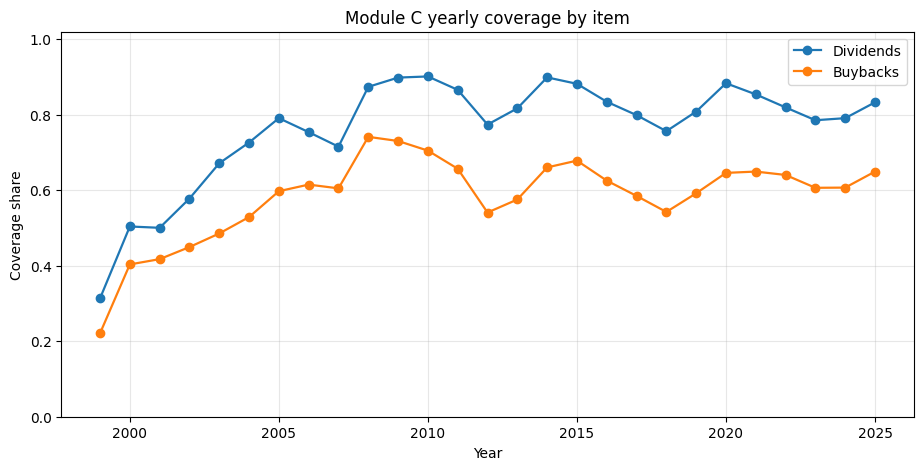

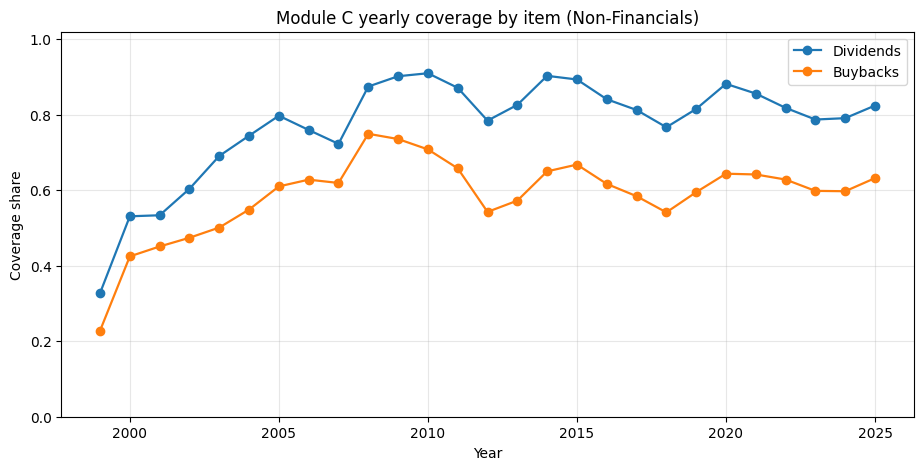

In [11]:
# Robust path resolution for Step 7B
MODULEC_OUTPUT_PATH = globals().get('OUTPUT_PATH_COMBINED_C', DATA_DIR / 'euro500_netpayout.parquet')

if not MODULEC_OUTPUT_PATH.exists():
    raise FileNotFoundError(f'Missing file: {MODULEC_OUTPUT_PATH}')

mc = pd.read_parquet(MODULEC_OUTPUT_PATH).copy()
if 'asof_date' in mc.columns:
    mc['asof_date'] = pd.to_datetime(mc['asof_date'], errors='coerce')

targets_c = [c for c in ['Dividends', 'Buybacks'] if c in mc.columns]
if not targets_c:
    raise KeyError('No Module C columns found (expected Dividends/Buybacks). Run Step 7 first.')

for c in targets_c:
    mc[c] = pd.to_numeric(mc[c], errors='coerce')

if 'asof_date' in mc.columns and mc['asof_date'].notna().any():
    mc['year'] = mc['asof_date'].dt.year
else:
    mc['year'] = pd.NA

mc['all2_available'] = mc[targets_c].notna().all(axis=1)

overall_c = {'rows_total': len(mc)}
for c in targets_c:
    overall_c[f'cov_{c}'] = float(mc[c].notna().mean()) if len(mc) else np.nan
overall_c['cov_all2'] = float(mc['all2_available'].mean()) if len(mc) else np.nan

display(pd.DataFrame([overall_c]))

if mc['year'].notna().any():
    yc = mc.groupby('year', as_index=False).agg(rows=('year', 'size'))
    for c in targets_c:
        yc[f'cov_{c}'] = mc.groupby('year')[c].apply(lambda s: s.notna().mean()).values
    yc['cov_all2'] = mc.groupby('year')['all2_available'].apply(lambda s: float(s.mean())).values

    plt.figure(figsize=(11, 5))
    for c in targets_c:
        plt.plot(yc['year'], yc[f'cov_{c}'], marker='o', linewidth=1.6, label=c)
    plt.title('Module C yearly coverage by item')
    plt.xlabel('Year')
    plt.ylabel('Coverage share')
    plt.ylim(0, 1.02)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


    # Zusatzplot: Module C coverage (Non-Financials only)
    if 'trbc_sector' in mc.columns:
        mc_nf = mc[mc['trbc_sector'].astype(str).str.strip().str.lower() != 'financials'].copy()
        if mc_nf['year'].notna().any() and not mc_nf.empty:
            yc_nf = mc_nf.groupby('year', as_index=False).agg(rows=('year', 'size'))
            for c in targets_c:
                yc_nf[f'cov_{c}'] = mc_nf.groupby('year')[c].apply(lambda s: s.notna().mean()).values
            yc_nf['cov_all2'] = mc_nf.groupby('year')['all2_available'].apply(lambda s: float(s.mean())).values

            plt.figure(figsize=(11, 5))
            for c in targets_c:
                plt.plot(yc_nf['year'], yc_nf[f'cov_{c}'], marker='o', linewidth=1.6, label=c)
            plt.title('Module C yearly coverage by item (Non-Financials)')
            plt.xlabel('Year')
            plt.ylabel('Coverage share')
            plt.ylim(0, 1.02)
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()
        else:
            print('No valid Non-Financials rows/year information for Module C coverage plot.')
    else:
        print('Column trbc_sector missing; skipping Module C Non-Financials coverage plot.')
else:
    print('No valid year information available for yearly coverage plot.')




## 8. Coverage-Uebersicht ueber alle gezogenen Items (alle Jahre)

Diese Tabelle listet fuer jedes gezogene Item die Gesamt-Coverage ueber den gesamten Zeitraum (alle Jahre zusammen):
- `all_equities`: alle Zeilen im finalen Panel
- `non_financials`: nur Zeilen mit `trbc_sector != financials`


In [12]:
# Step 8 — Coverage summary across all pulled items (all years)
STEP8_PATH = DATA_DIR / 'euro500_netpayout.parquet'

if not STEP8_PATH.exists():
    raise FileNotFoundError(f'Missing file: {STEP8_PATH}')

cov8 = pd.read_parquet(STEP8_PATH).copy()

# Candidate list from all prior pull modules (Step 3-7)
item_candidates = [
    'EPS_FY1', 'EPS_FY2', 'EPS_FY3', 'EPS_FY4', 'EPS_FY5', 'LTGMean',
    'BE', 'assets', 'debt',
    'Sales', 'NetIncome', 'GrossProfit',
    'Dividends', 'Buybacks',
]
items = [c for c in item_candidates if c in cov8.columns]
if not items:
    raise KeyError('No expected pulled item columns found in euro500_netpayout.parquet.')

for c in items:
    cov8[c] = pd.to_numeric(cov8[c], errors='coerce')

if 'trbc_sector' in cov8.columns:
    mask_nonfin = cov8['trbc_sector'].astype(str).str.strip().str.lower() != 'financials'
else:
    mask_nonfin = pd.Series(False, index=cov8.index)
    print('Column trbc_sector missing -> non_financials coverage set to NaN.')

rows = []
for c in items:
    all_cov = float(cov8[c].notna().mean()) if len(cov8) else np.nan
    if mask_nonfin.any():
        nf_cov = float(cov8.loc[mask_nonfin, c].notna().mean())
    else:
        nf_cov = np.nan
    rows.append({'item': c, 'all_equities': all_cov, 'non_financials': nf_cov})

step8_table = pd.DataFrame(rows).sort_values('item').reset_index(drop=True)

print('Step 8 coverage table (all years pooled):')
display(step8_table)



Step 8 coverage table (all years pooled):


,item,all_equities,non_financials
0,BE,0.956574,0.955803
1,Buybacks,0.583593,0.586610
2,Dividends,0.764130,0.772468
3,GrossProfit,0.821481,0.935466
4,NetIncome,0.940500,0.938968
5,Sales,0.939519,0.938751
6,assets,0.959722,0.958500
7,debt,0.941981,0.947451
